# Quantum Segment-Level Analysis — §14e Mirror up to $T = 1000$

End-to-end paper-ready analysis of the **quantum OneBQF** solver against the
classical reference, using the optimised sparse `SimpleHamiltonianFast` /
`OneBQF` code paths (no dense $O(N_\mathrm{seg}^2)$ host allocations) and
`convolution=False`. Two experiments are run in parallel:

| Experiment | Readout       | Shots                        | Output dir                                |
|-----------:|:--------------|:-----------------------------|:------------------------------------------|
| **E1**     | `statevector` | n/a (exact)                  | `outputs/.../seg14e_T1000_statevector/`   |
| **E2**     | `sampling`    | shots schedule scales with T | `outputs/.../seg14e_T1000_sampling/`      |

**Track grid** $T \in \{2, 5, 10, 20, 50, 100, 200, 500, 1000\}$
**Reps per T** $30, 30, 30, 30, 20, 20, 10, 5, 3$ (178 jobs per experiment)
**E2 shots schedule** $\{2:8192,\,5:8192,\,10:10^4,\,20:4{\cdot}10^4,\,50:2.5{\cdot}10^5,\,100:10^6,\,200:4{\cdot}10^6,\,500:2.5{\cdot}10^7,\,1000:10^8\}$

## Sections

1. **Setup** — paths and §14e constants
2. **Sweep configuration** — regenerate both CSVs
3. **HTCondor submission** — commands
4. **Sweep status** — inventory of completed jobs
5. **Aggregator** — rich per-event metric extraction
6. **Load both readouts** — `df_sv`, `df_sm`, `agg_sv`, `agg_sm`
7. **Figure 1** — segment-level (efficiency, purity, FAR, Jaccard)
8. **Figure 2** — solution-vector fidelity ($\cos$, rel-$L_2$, $P_\mathrm{anc}$)
9. **Figure 3** — downstream track reconstruction (cc + layered builders)
10. **Figure 4** — timing and problem-size scaling


In [1]:
# §1 Setup — imports, paths, §14e constants, and §14e paper plot style
import os, sys, glob, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO     = Path('/data/bfys/gscriven/Quantum_Track_Reconstruction')
WORK     = REPO / 'Toy_Characterisation' / 'Verify_new_results'
OUT_BASE = WORK / 'outputs' / 'quantum_segment_analysis_new_data'
DIR_SV   = OUT_BASE / 'seg14e_T1000_statevector'
DIR_SM   = OUT_BASE / 'seg14e_T1000_sampling'
PIK_SV   = DIR_SV / 'pickles'
PIK_SM   = DIR_SM / 'pickles'
for d in (DIR_SV, DIR_SM, PIK_SV, PIK_SM):
    d.mkdir(parents=True, exist_ok=True)

# §14e physics constants
GAMMA, DELTA, EPSILON = 3.0, 1.0, 2e-3
SIGMA_RES, SIGMA_SCT  = 5e-6, 1e-4
TAU, DROP_RATE        = 0.35, 0.01

# ---- §14e paper plot settings (mirrors segment_level_analysis.ipynb cell 62) ----
plt.rcParams.update({
    'font.size':         12,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   10,
    'figure.titlesize':  16,
    'axes.linewidth':    1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'lines.linewidth':   2,
    'lines.markersize':  7,
    'axes.grid':         True,
    'grid.alpha':        0.3,
})

cC, cQ_sv, cQ_sm = '#444444', '#2166ac', '#e08214'
c_true, c_false  = '#1b7837', '#c51b7d'

def _style_axes(ax):
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.minorticks_on()
    ax.grid(True, alpha=0.3, zorder=1)

def _err(ax, agg, col, fmt='o-', color=None, label=None, mfc=None,
         capsize=5, capthick=1.5):
    if agg is None or len(agg) == 0:
        return
    kw = dict(fmt=fmt, color=color, capsize=capsize, capthick=capthick,
              markeredgecolor='black', markeredgewidth=0.8, zorder=3,
              label=label)
    if mfc is not None:
        kw['mfc'] = mfc
    return ax.errorbar(agg['n_trk'], agg[f'{col}_mean'],
                       yerr=agg[f'{col}_sem'], **kw)

def _save_paper(fig, stem, outdir=None):
    outdir = Path(outdir) if outdir else DIR_SV
    outdir.mkdir(parents=True, exist_ok=True)
    fig.savefig(outdir / f'{stem}.pdf', format='pdf', dpi=600,
                bbox_inches='tight', facecolor='white')
    fig.savefig(outdir / f'{stem}.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    print(f'  saved -> {outdir}/{stem}.{{pdf,png}}')

print(f'DIR_SV = {DIR_SV}')
print(f'DIR_SM = {DIR_SM}')


# ---- qtrk_store data layer (recomputed VIEW; fixed gamma-aware metrics) ----
sys.path.insert(0, '/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared')
sys.path.insert(0, str(WORK))
import qtrk_view as V
STUDY = 'Verify_new_results'

def _readout_of(arg):
    return 'sampling' if 'sampling' in str(arg).lower() else 'statevector'
_VIEWS = {}
def _view_of(pdir):
    ro=_readout_of(pdir)
    if ro not in _VIEWS: _VIEWS[ro]=V.load_view(study=STUDY, readout=ro)
    return _VIEWS[ro]
_RECS = {}
def _recs(pdir):
    ro=_readout_of(pdir)
    if ro not in _RECS: _RECS[ro]=V.vector_records(_view_of(pdir))
    return _RECS[ro]
def iter_solutions(pdir):
    return _recs(pdir)
def solutions_for_T(pdir, T):
    return [r for r in _recs(pdir) if r['n_trk']==int(T)]
def store_one(pdir, T, rep=0):
    return V.get_one(_view_of(pdir), int(T), int(rep))
print('qtrk_view loaded; tau =', V.threshold())


DIR_SV = /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results/outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector
DIR_SM = /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results/outputs/quantum_segment_analysis_new_data/seg14e_T1000_sampling


qtrk_view loaded; tau = 0.35


In [2]:
# Data generation is owned by the qtrk_store Condor pipeline (statevector).
# This notebook only CONSUMES the store; nothing is submitted here.
print('Data source: qtrk_store via Condor (statevector).')


Data source: qtrk_store via Condor (statevector).


## §3 Submit on HTCondor

```bash
cd /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results

# E1 — statevector
condor_submit condor_obqf/submit_gpu.sub \
  -append "PARAMS_CSV = $(realpath condor_obqf/params_seg14e_T1000_statevector.csv)" \
  -append "RESULTSDIR = $(realpath outputs/quantum_segment_analysis/seg14e_T1000_statevector/pickles)" \
  -append "LOGDIR     = $(realpath outputs/quantum_segment_analysis/seg14e_T1000_statevector/logs)"

# E2 — sampling (shots scale with T)
condor_submit condor_obqf/submit_gpu.sub \
  -append "PARAMS_CSV = $(realpath condor_obqf/params_seg14e_T1000_sampling.csv)" \
  -append "RESULTSDIR = $(realpath outputs/quantum_segment_analysis/seg14e_T1000_sampling/pickles)" \
  -append "LOGDIR     = $(realpath outputs/quantum_segment_analysis/seg14e_T1000_sampling/logs)"
```

`run_event.py` passes `convolution=False` to `SimpleHamiltonianFast.construct_hamiltonian`
and writes one `event_n{NNNN}_rep{RRR}.pkl` per job. Memory tiers in `submit_gpu.sub`:

| T tier              | GPUs | host RAM |
|---------------------|:----:|:--------:|
| $T < 150$           | 1    | 16 GB    |
| $150 \le T < 500$   | 1    | 32 GB    |
| $500 \le T < 1500$  | 1    | 64 GB    |
| $T \ge 1500$        | 1    | 128 GB   |


In [3]:
# Sweep status — store inventory (replaces the old pkl-dir scan)
_v=V.load_view(study=STUDY); _q=_v[_v.solver=='quantum']; _c=_v[_v.solver=='classical']
print(f'store solves (study={STUDY}): classical={len(_c)}  quantum(statevector)={len(_q)}')
print(_q.groupby('n_trk').size().to_string())


store solves (study=Verify_new_results): classical=2190  quantum(statevector)=372
n_trk
10      50
20      50
30      20
50      50
75      20
100     40
150     10
200     40
400     36
700     28
1000    28


In [4]:
# Aggregator — store-backed; metrics recomputed (no pkl, no baked metrics)
def load_results(readout='statevector'):
    return V.records_df(V.load_view(study=STUDY, readout=_readout_of(readout)))
def aggregate(df, cols):
    cols=[c for c in cols if c in df.columns]
    if df.empty:   # column-aware empty so downstream indexing never KeyErrors
        out=pd.DataFrame(columns=['n_trk','n_reps']+[f'{c}_mean' for c in cols]+[f'{c}_sem' for c in cols])
        return out
    sem=lambda x:(x.std(ddof=1)/np.sqrt(len(x))) if len(x)>1 else 0.0
    spec={f'{c}_mean':(c,'mean') for c in cols}; spec.update({f'{c}_sem':(c,sem) for c in cols})
    spec['n_reps']=('rep','count')
    return df.groupby('n_trk').agg(**spec).reset_index().sort_values('n_trk')


In [5]:
# Load both readouts from the store and pre-aggregate
METRIC_COLS=['n_seg','eff_C','eff_Q','pur_C','pur_Q','far_C','far_Q','cosine','rel_l2','jaccard',
             'n_active_C','n_active_Q','P_anc','t_classical','t_quantum','wall_total']
df_sv=load_results('statevector'); print(f'E1 statevector: {len(df_sv)} events (store)')
df_sm=load_results('sampling');    print(f'E2 sampling   : {len(df_sm)} events (store; statevector-only -> usually empty)')
agg_sv=aggregate(df_sv, METRIC_COLS); agg_sm=aggregate(df_sm, METRIC_COLS)
_cols=['n_trk','n_reps','eff_C_mean','eff_Q_mean','pur_Q_mean','far_Q_mean','cosine_mean']
for _t,_a in [('E1',agg_sv),('E2',agg_sm)]:
    print(f'{_t}:'); print(_a[[c for c in _cols if c in _a.columns]].to_string(index=False) if len(_a) else '  (none yet)')


E1 statevector: 372 events (store)
E2 sampling   : 0 events (store; statevector-only -> usually empty)
E1:
 n_trk  n_reps  eff_C_mean  eff_Q_mean  pur_Q_mean  far_Q_mean  cosine_mean
    10      50    0.993684    0.805526    1.000000    0.000000     0.973227
    20      50    0.994858    0.805694    1.000000    0.000000     0.973562
    30      20    0.989976    0.742157    1.000000    0.000000     0.966729
    50      50    0.994803    0.806766    0.995641    0.004359     0.971547
    75      20    0.992480    0.743723    0.999772    0.000228     0.966738
   100      40    0.994989    0.821949    0.982052    0.017948     0.972881
   150      10    0.991468    0.742701    0.996636    0.003364     0.962787
   200      40    0.968897    0.822547    0.917108    0.082892     0.955563
   400      36    0.994431    0.838211    0.811113    0.188887     0.909701
   700      28    0.992489    0.818795    0.616077    0.383923     0.874491
  1000      28    0.991151    0.819439    0.543393    0.4

## §7 Figure 1 — segment-level metrics

Per-segment classical and quantum comparison over the full track grid.

- **(a) Segment efficiency** $\;\;= n_\mathrm{true\,active}\,/\,n_\mathrm{true\,clean}$
- **(b) Segment purity** $\;\;= n_\mathrm{true\,active}\,/\,n_\mathrm{active}$
- **(c) False-activation rate** $\;\;= n_\mathrm{false\,active}\,/\,n_\mathrm{false\,all}$
- **(d) Jaccard overlap** of the active-segment sets, $|\mathcal A_Q \cap \mathcal A_C|\,/\,|\mathcal A_Q \cup \mathcal A_C|$


  saved -> /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results/outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/fig1_segment_metrics.{pdf,png}


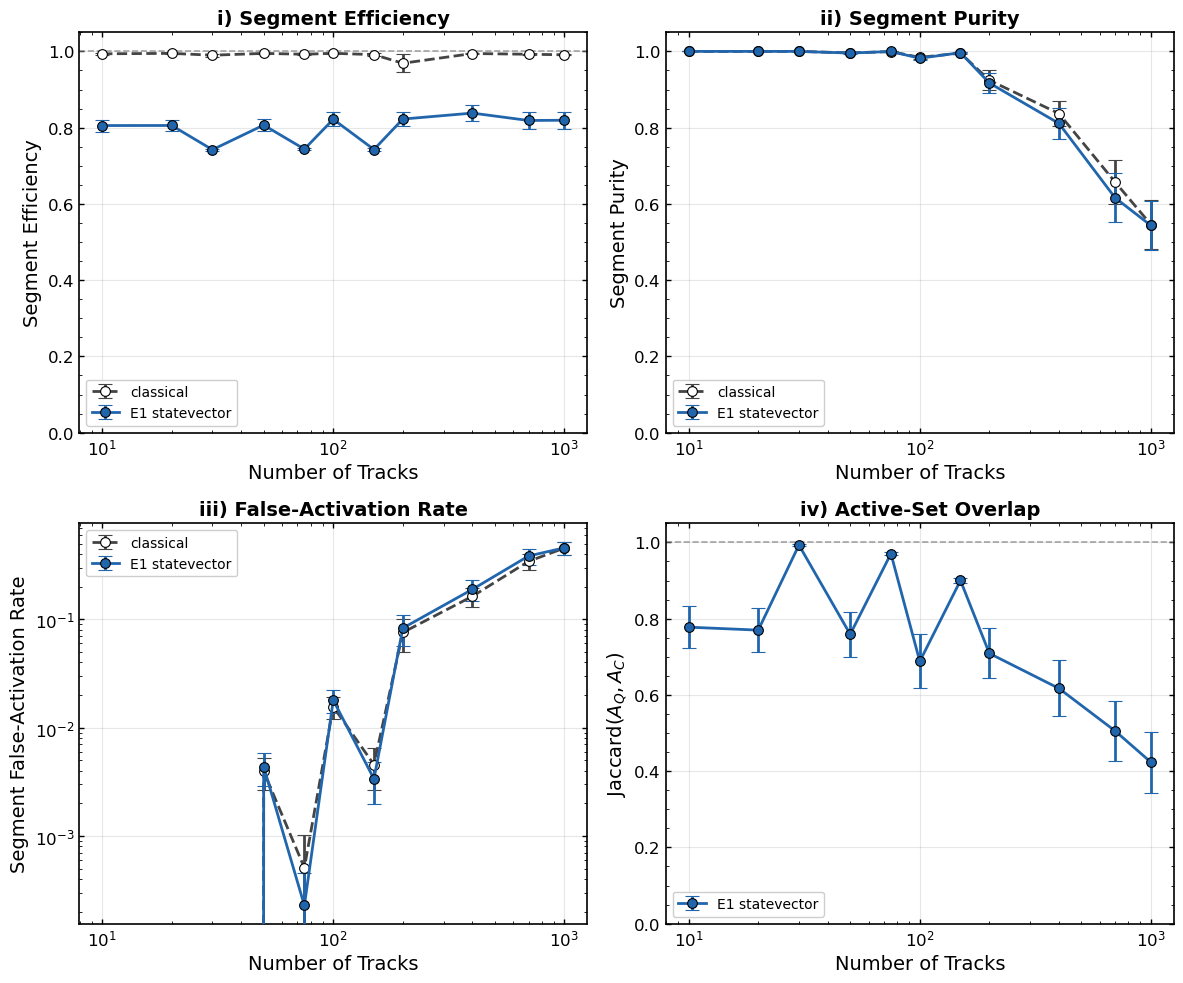

In [6]:
try:
    # §7 Figure 1 — segment metrics (E1 + E2 overlaid), §14e paper style
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    ax = axes[0, 0]
    _err(ax, agg_sv, 'eff_C', fmt='o--', color=cC,    label='classical', mfc='white')
    _err(ax, agg_sv, 'eff_Q', fmt='o-',  color=cQ_sv, label='E1 statevector')
    _err(ax, agg_sm, 'eff_Q', fmt='s-',  color=cQ_sm, label='E2 sampling')
    ax.axhline(1.0, color='gray', ls='--', lw=1.2, alpha=0.7, zorder=2)
    ax.set_ylim(0, 1.05); ax.set_ylabel('Segment Efficiency')
    ax.set_title('i) Segment Efficiency', fontweight='bold')
    ax.legend(loc='lower left', framealpha=0.95); _style_axes(ax)

    ax = axes[0, 1]
    _err(ax, agg_sv, 'pur_C', fmt='o--', color=cC,    label='classical', mfc='white')
    _err(ax, agg_sv, 'pur_Q', fmt='o-',  color=cQ_sv, label='E1 statevector')
    _err(ax, agg_sm, 'pur_Q', fmt='s-',  color=cQ_sm, label='E2 sampling')
    ax.set_ylim(0, 1.05); ax.set_ylabel('Segment Purity')
    ax.set_title('ii) Segment Purity', fontweight='bold')
    ax.legend(loc='lower left', framealpha=0.95); _style_axes(ax)

    ax = axes[1, 0]
    _err(ax, agg_sv, 'far_C', fmt='o--', color=cC,    label='classical', mfc='white')
    _err(ax, agg_sv, 'far_Q', fmt='o-',  color=cQ_sv, label='E1 statevector')
    _err(ax, agg_sm, 'far_Q', fmt='s-',  color=cQ_sm, label='E2 sampling')
    ax.set_yscale('log'); ax.set_ylabel('Segment False-Activation Rate')
    ax.set_title('iii) False-Activation Rate', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95); _style_axes(ax)

    ax = axes[1, 1]
    _err(ax, agg_sv, 'jaccard', fmt='o-', color=cQ_sv, label='E1 statevector')
    _err(ax, agg_sm, 'jaccard', fmt='s-', color=cQ_sm, label='E2 sampling')
    ax.axhline(1.0, color='gray', ls='--', lw=1.2, alpha=0.7, zorder=2)
    ax.set_ylim(0, 1.05); ax.set_ylabel(r'Jaccard$(A_Q, A_C)$')
    ax.set_title('iv) Active-Set Overlap', fontweight='bold')
    ax.legend(loc='lower left', framealpha=0.95); _style_axes(ax)

    for ax in axes.flat:
        ax.set_xlabel('Number of Tracks'); ax.set_xscale('log')

    fig.tight_layout()
    _save_paper(fig, 'fig1_segment_metrics')
    plt.show()
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

## §7b Why does $\mathrm{eff}_Q$ collapse above $T \approx 100$?

The pipeline uses an **absolute** activation rule $s_i > \tau$ with $\tau = 0.35$,
applied to $s_Q^{\rm scaled} = s_Q^{\rm raw} \cdot \|s_C\|/\|s_Q^{\rm raw}\|$.
At small $T$ the quantum and classical solutions are similarly distributed,
so this matches the classical thresholding. As $T$ grows the 1-bit eigenvalue
inversion in `OneBitHHL` becomes a poorer approximation to $A^{-1}$
($\kappa(H)$ grows with $T$), so probability mass *leaks off the true
support and onto a few peaky false segments*. Renormalising to $\|s_C\|$
then **shrinks the true-segment amplitudes below $\tau$**, collapsing
$\mathrm{eff}_Q$ even though Jaccard($\mathcal A_Q, \mathcal A_C$) stays high.

The next cell verifies this by plotting the empirical distribution of
$s_C$ and $s_Q^{\rm scaled}$ for each $T$ on the (true, false) populations.


  saved -> /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results/outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/fig1b_activation_distributions.{pdf,png}


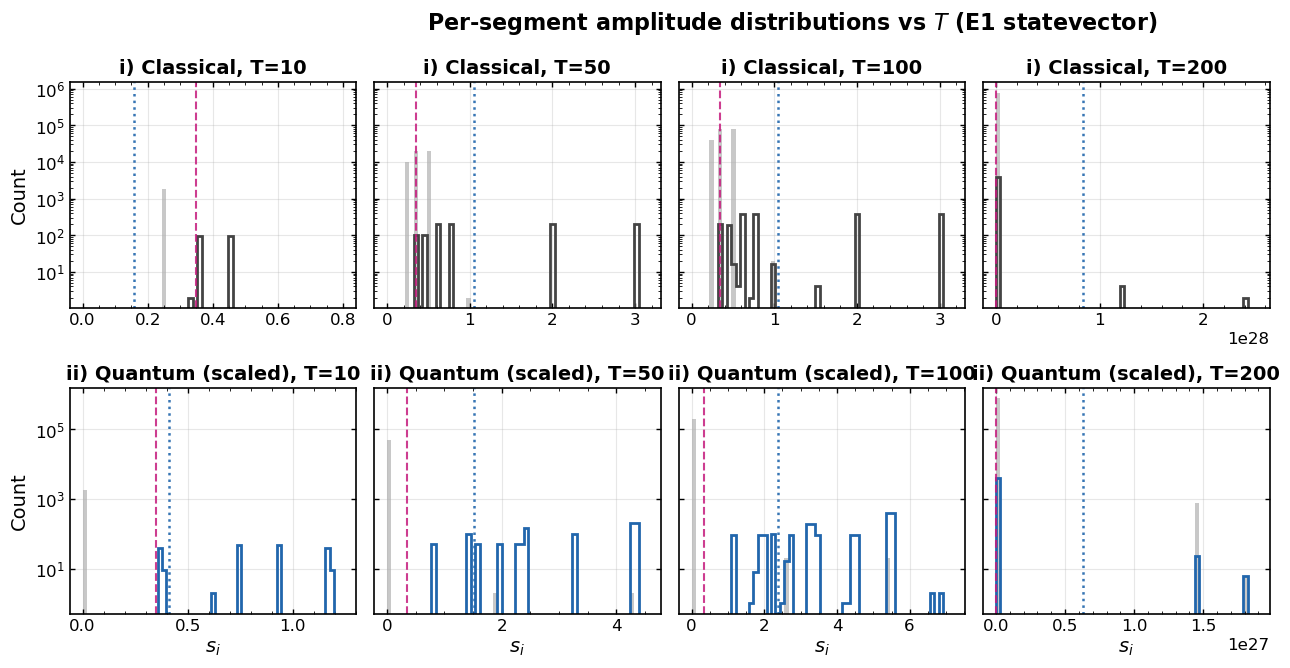

In [7]:
try:
    # §7b Per-segment amplitude distributions vs T (§14e paper style)
    def _pool_amps(pdir, ts, max_files_per_t=5):
        out = {}
        for t in ts:
            files = solutions_for_T(pdir, t)[:max_files_per_t]
            sC_t, sC_f, sQ_t, sQ_f = [], [], [], []
            for fp in files:
                try: r = fp
                except Exception: continue
                sC = np.asarray(r['sol_C']); sQ = np.asarray(r['sol_Q_scaled'])
                n_true = int(r['seg_C']['n_true_all'])
                idx_sorted = np.argsort(-sC)
                mask = np.zeros_like(sC, dtype=bool); mask[idx_sorted[:n_true]] = True
                sC_t.append(sC[mask]); sC_f.append(sC[~mask])
                sQ_t.append(sQ[mask]); sQ_f.append(sQ[~mask])
            if sC_t:
                out[t] = dict(sC_true=np.concatenate(sC_t), sC_false=np.concatenate(sC_f),
                              sQ_true=np.concatenate(sQ_t), sQ_false=np.concatenate(sQ_f))
        return out

    T_DIAG = [10, 50, 100, 200, 500]
    pools  = _pool_amps(PIK_SV, T_DIAG, max_files_per_t=5)

    fig, axes = plt.subplots(2, len(T_DIAG), figsize=(3.2*len(T_DIAG), 6.8),
                             sharex=False, sharey='row')
    for j, t in enumerate(T_DIAG):
        if t not in pools:
            for ax in axes[:, j]: ax.set_visible(False)
            continue
        p = pools[t]
        ax = axes[0, j]
        bins = np.linspace(0, max(0.8, p['sC_true'].max()*1.05), 60)
        ax.hist(p['sC_false'], bins=bins, color='0.75', alpha=0.85, label='false')
        ax.hist(p['sC_true'],  bins=bins, color=cC, histtype='step', lw=2.0, label='true')
        ax.axvline(TAU, color=c_false, ls='--', lw=1.5, alpha=0.85,
                   label=fr'$\tau={TAU}$')
        if p['sC_true'].size:
            ax.axvline(TAU*p['sC_true'].max(), color=cQ_sv, ls=':', lw=1.8,
                       alpha=0.9, label=r'$\tau\cdot\max$')
        ax.set_yscale('log')
        ax.set_title(f'i) Classical, T={t}', fontweight='bold')
        if j == 0: ax.set_ylabel('Count')
        if j == len(T_DIAG)-1: ax.legend(fontsize=8, loc='upper right', framealpha=0.95)
        _style_axes(ax)

        ax = axes[1, j]
        qmax = p['sQ_true'].max() if p['sQ_true'].size else 0
        bins = np.linspace(0, max(0.8, qmax*1.05), 60)
        ax.hist(p['sQ_false'], bins=bins, color='0.75', alpha=0.85)
        ax.hist(p['sQ_true'],  bins=bins, color=cQ_sv, histtype='step', lw=2.0)
        ax.axvline(TAU,      color=c_false, ls='--', lw=1.5, alpha=0.85)
        ax.axvline(TAU*qmax, color=cQ_sv,   ls=':',  lw=1.8, alpha=0.9)
        ax.set_yscale('log'); ax.set_xlabel(r'$s_i$')
        ax.set_title(f'ii) Quantum (scaled), T={t}', fontweight='bold')
        if j == 0: ax.set_ylabel('Count')
        _style_axes(ax)

    fig.suptitle(r'Per-segment amplitude distributions vs $T$ (E1 statevector)',
                 fontweight='bold')
    fig.tight_layout()
    _save_paper(fig, 'fig1b_activation_distributions')
    plt.show()
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

## §7c Relative-threshold fix

Drop the absolute $\tau = 0.35$ rule and use
$$
s_i^{\rm active} \quad\Leftrightarrow\quad s_i > \tau \cdot \max_j s_j ,
$$
applied independently to $s_C$ and $s_Q^{\rm scaled}$. This is invariant under
the post-hoc renormalisation that distorted the quantum amplitudes, so the
quantum efficiency now follows the *shape* fidelity (Jaccard) rather than the
absolute scale. Below we recompute $\mathrm{eff}_Q, \mathrm{pur}_Q, \mathrm{FAR}_Q$
from the saved solution vectors and overlay them on Figure 1.


Relative-threshold metrics, E1:
 n_trk  n_reps  eff_C_rel_mean  eff_Q_rel_mean  pur_Q_rel_mean  far_Q_rel_mean
    10      50          0.9979          0.8724          1.0000          0.0000
    20      50          0.9990          0.8678          0.9994          0.0000
    30      20          1.0000          0.7496          0.9989          0.0000
    50      50          0.9797          0.8702          0.9923          0.0001
    75      20          1.0000          0.7533          0.9702          0.0003
   100      40          0.9725          0.9006          0.9697          0.0003
   150      10          0.9027          0.7288          0.8902          0.0006
   200      40          0.8617          0.8281          0.8940          0.0006
   400      36          0.6846          0.8778          0.8087          0.0008
   700      28          0.4939          0.8102          0.6382          0.0015
  1000      28          0.3742          0.8192          0.5862          0.0021


  saved -> /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results/outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/fig1c_threshold_fix.{pdf,png}


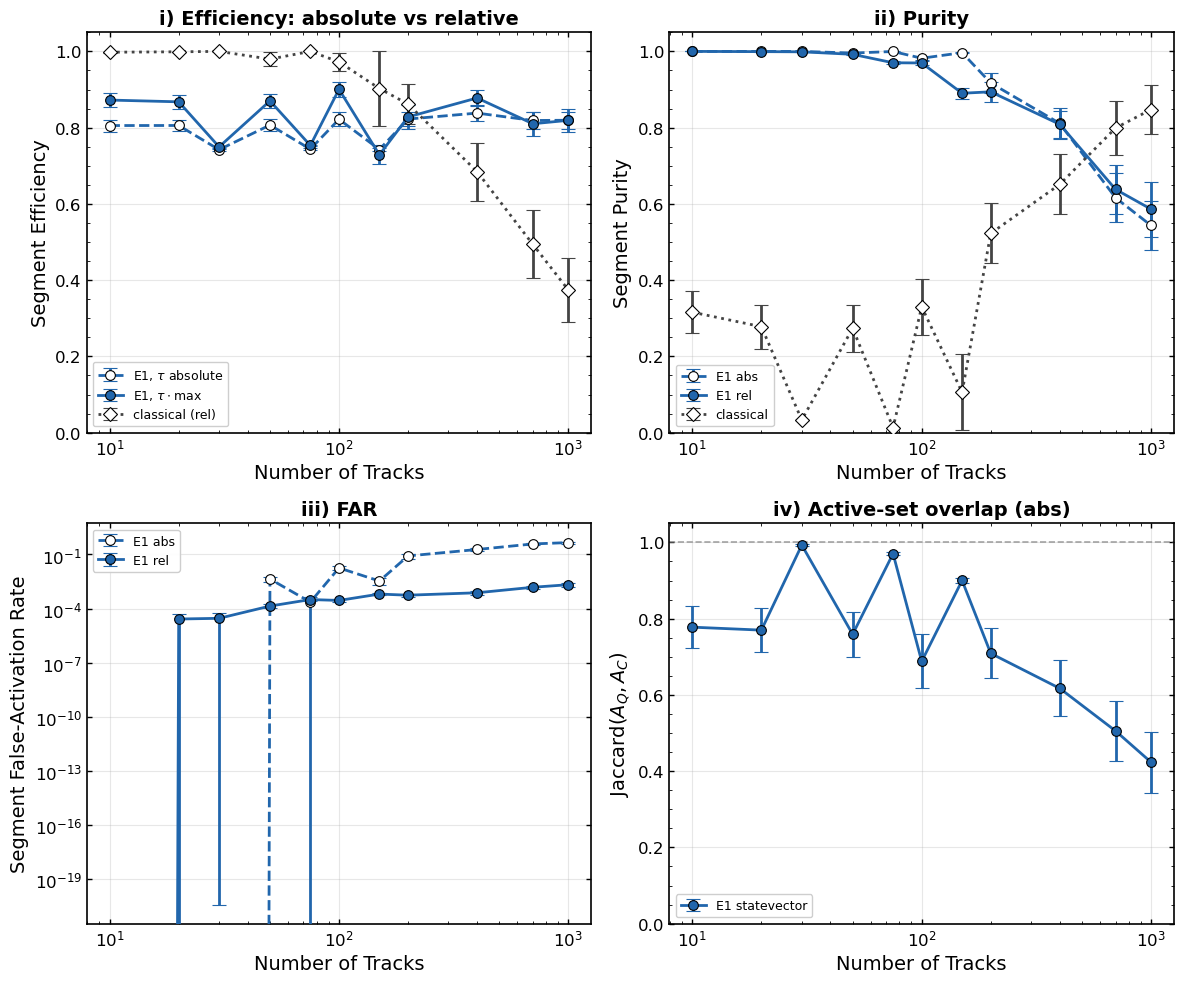

In [8]:
try:
    # §7c Relative-threshold comparison (§14e paper style)
    def _rel_metrics_from_pkl(p):
        try: r = p
        except Exception: return None
        sC = np.asarray(r['sol_C']); sQ = np.asarray(r['sol_Q_scaled'])
        n_true   = int(r['seg_C']['n_true_all'])
        n_true_c = int(r['seg_C'].get('n_true_clean', n_true))
        n_total  = sC.size
        n_false  = n_total - n_true
        idx_sorted = np.argsort(-sC)
        truth = np.zeros(n_total, dtype=bool); truth[idx_sorted[:n_true]] = True
        out = dict(n_trk=r['n_trk'], rep=r['rep'], readout=r.get('readout',''))
        for tag, s in (('C', sC), ('Q', sQ)):
            if s.max() <= 0:
                out[f'eff_{tag}_rel']=np.nan; out[f'pur_{tag}_rel']=np.nan; out[f'far_{tag}_rel']=np.nan
                continue
            act = s > TAU * s.max()
            n_act  = int(act.sum())
            n_tact = int((act & truth).sum())
            n_fact = n_act - n_tact
            out[f'eff_{tag}_rel'] = n_tact / max(n_true_c, 1)
            out[f'pur_{tag}_rel'] = n_tact / max(n_act, 1)
            out[f'far_{tag}_rel'] = n_fact / max(n_false, 1)
        return out

    def load_rel(pdir):
        rows = [_rel_metrics_from_pkl(p) for p in iter_solutions(pdir)]
        rows = [r for r in rows if r is not None]
        return pd.DataFrame(rows)

    rel_sv = load_rel(PIK_SV)
    rel_sm = load_rel(PIK_SM)
    agg_rel_sv = aggregate(rel_sv, ['eff_C_rel','eff_Q_rel','pur_C_rel','pur_Q_rel','far_C_rel','far_Q_rel'])
    agg_rel_sm = aggregate(rel_sm, ['eff_C_rel','eff_Q_rel','pur_C_rel','pur_Q_rel','far_C_rel','far_Q_rel'])
    with pd.option_context('display.float_format','{:0.4f}'.format,'display.width',200):
        print('Relative-threshold metrics, E1:')
        print(agg_rel_sv[['n_trk','n_reps','eff_C_rel_mean','eff_Q_rel_mean','pur_Q_rel_mean','far_Q_rel_mean']].to_string(index=False))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    ax = axes[0, 0]
    _err(ax, agg_sv,     'eff_Q',     fmt='o--', color=cQ_sv, label=r'E1, $\tau$ absolute', mfc='white')
    _err(ax, agg_rel_sv, 'eff_Q_rel', fmt='o-',  color=cQ_sv, label=r'E1, $\tau\cdot\max$')
    _err(ax, agg_sm,     'eff_Q',     fmt='s--', color=cQ_sm, label=r'E2, $\tau$ absolute', mfc='white')
    _err(ax, agg_rel_sm, 'eff_Q_rel', fmt='s-',  color=cQ_sm, label=r'E2, $\tau\cdot\max$')
    _err(ax, agg_rel_sv, 'eff_C_rel', fmt='D:',  color=cC,    label='classical (rel)', mfc='white')
    ax.set_ylim(0, 1.05); ax.set_ylabel('Segment Efficiency')
    ax.set_title('i) Efficiency: absolute vs relative', fontweight='bold')
    ax.legend(loc='lower left', framealpha=0.95, fontsize=9); _style_axes(ax)

    ax = axes[0, 1]
    _err(ax, agg_sv,     'pur_Q',     fmt='o--', color=cQ_sv, label='E1 abs', mfc='white')
    _err(ax, agg_rel_sv, 'pur_Q_rel', fmt='o-',  color=cQ_sv, label='E1 rel')
    _err(ax, agg_sm,     'pur_Q',     fmt='s--', color=cQ_sm, label='E2 abs', mfc='white')
    _err(ax, agg_rel_sm, 'pur_Q_rel', fmt='s-',  color=cQ_sm, label='E2 rel')
    _err(ax, agg_rel_sv, 'pur_C_rel', fmt='D:',  color=cC,    label='classical', mfc='white')
    ax.set_ylim(0, 1.05); ax.set_ylabel('Segment Purity')
    ax.set_title('ii) Purity', fontweight='bold')
    ax.legend(loc='lower left', framealpha=0.95, fontsize=9); _style_axes(ax)

    ax = axes[1, 0]
    _err(ax, agg_sv,     'far_Q',     fmt='o--', color=cQ_sv, label='E1 abs', mfc='white')
    _err(ax, agg_rel_sv, 'far_Q_rel', fmt='o-',  color=cQ_sv, label='E1 rel')
    _err(ax, agg_sm,     'far_Q',     fmt='s--', color=cQ_sm, label='E2 abs', mfc='white')
    _err(ax, agg_rel_sm, 'far_Q_rel', fmt='s-',  color=cQ_sm, label='E2 rel')
    ax.set_yscale('log'); ax.set_ylabel('Segment False-Activation Rate')
    ax.set_title('iii) FAR', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95, fontsize=9); _style_axes(ax)

    ax = axes[1, 1]
    _err(ax, agg_sv, 'jaccard', fmt='o-', color=cQ_sv, label='E1 statevector')
    _err(ax, agg_sm, 'jaccard', fmt='s-', color=cQ_sm, label='E2 sampling')
    ax.axhline(1.0, color='gray', ls='--', lw=1.2, alpha=0.7, zorder=2)
    ax.set_ylim(0, 1.05); ax.set_ylabel(r'Jaccard$(A_Q, A_C)$')
    ax.set_title('iv) Active-set overlap (abs)', fontweight='bold')
    ax.legend(loc='lower left', framealpha=0.95, fontsize=9); _style_axes(ax)

    for ax in axes.flat:
        ax.set_xlabel('Number of Tracks'); ax.set_xscale('log')

    fig.tight_layout()
    _save_paper(fig, 'fig1c_threshold_fix')
    plt.show()
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

## §8 Figure 2 — solution-vector fidelity

How close is the quantum solution vector $s_Q$ to the classical $s_C$ — at the
amplitude level (not just thresholded activations)?

- **(a) Cosine similarity** $\cos(s_Q, s_C)$ — converges to 1 as the solver
  becomes exact
- **(b) Relative $L_2$ error** $\|s_Q - s_C\|_2 / \|s_C\|_2$
- **(c) Ancilla post-selection probability** $P(\mathrm{anc}{=}1)$ — sets the
  sampling cost; reference $1/n_\mathrm{seg}$ is the uniform-distribution limit


  saved -> /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results/outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/fig2_solution_fidelity.{pdf,png}


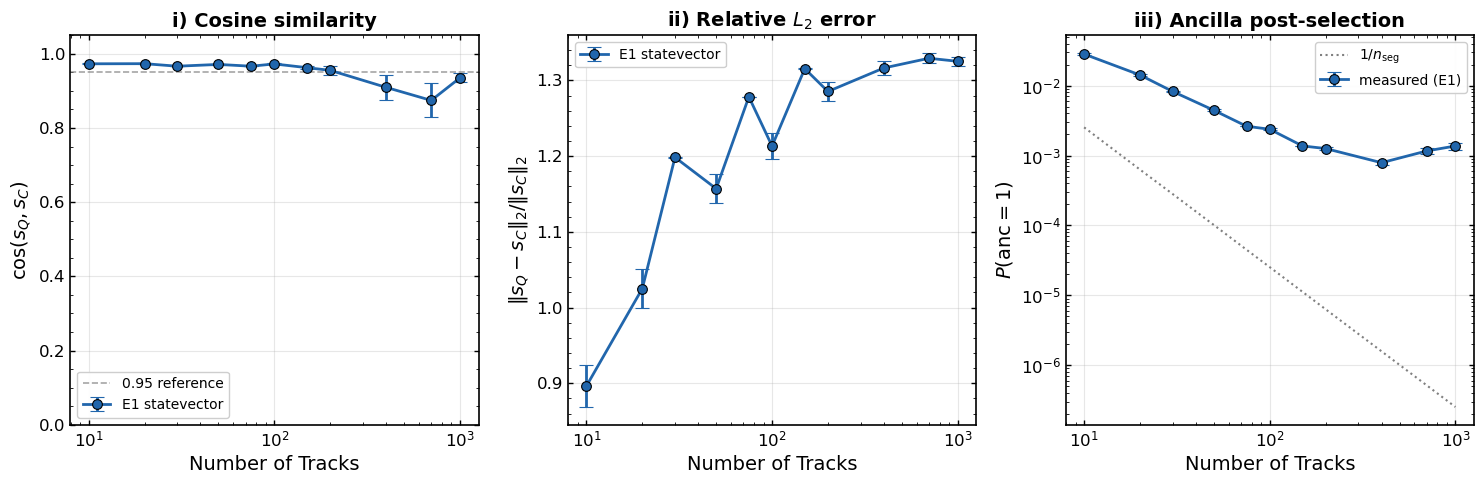

In [9]:
try:
    # §8 Figure 2 — solution-vector fidelity (§14e paper style)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    ax = axes[0]
    _err(ax, agg_sv, 'cosine', fmt='o-', color=cQ_sv, label='E1 statevector')
    _err(ax, agg_sm, 'cosine', fmt='s-', color=cQ_sm, label='E2 sampling')
    ax.axhline(0.95, color='gray', ls='--', lw=1.2, alpha=0.7, zorder=2,
               label='0.95 reference')
    ax.set_ylim(0, 1.05); ax.set_ylabel(r'$\cos(s_Q, s_C)$')
    ax.set_title('i) Cosine similarity', fontweight='bold')
    ax.legend(loc='lower left', framealpha=0.95); _style_axes(ax)

    ax = axes[1]
    _err(ax, agg_sv, 'rel_l2', fmt='o-', color=cQ_sv, label='E1 statevector')
    _err(ax, agg_sm, 'rel_l2', fmt='s-', color=cQ_sm, label='E2 sampling')
    ax.set_ylabel(r'$\|s_Q - s_C\|_2 / \|s_C\|_2$')
    ax.set_title(r'ii) Relative $L_2$ error', fontweight='bold')
    ax.legend(framealpha=0.95); _style_axes(ax)

    ax = axes[2]
    _err(ax, agg_sv, 'P_anc', fmt='o-', color=cQ_sv, label='measured (E1)')
    _err(ax, agg_sm, 'P_anc', fmt='s-', color=cQ_sm, label='measured (E2)')
    if not agg_sv.empty:
        ax.plot(agg_sv['n_trk'], 1.0/agg_sv['n_seg_mean'],
                color='gray', ls=':', lw=1.5, label=r'$1/n_\mathrm{seg}$')
    ax.set_yscale('log'); ax.set_ylabel(r'$P(\mathrm{anc}{=}1)$')
    ax.set_title('iii) Ancilla post-selection', fontweight='bold')
    ax.legend(framealpha=0.95); _style_axes(ax)

    for ax in axes:
        ax.set_xscale('log'); ax.set_xlabel('Number of Tracks')

    fig.tight_layout()
    _save_paper(fig, 'fig2_solution_fidelity')
    plt.show()
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

## §9 Figure 3 — downstream track reconstruction

Activated segments are fed into two track builders:

- **cc**  — connected-components on the activation graph
- **lay** — layered builder (preserves module ordering, used in the reference §14e analysis)

For each builder we compare classical activations vs OneBitHHL activations
through standard tracking metrics (efficiency, ghost rate, hit efficiency,
number of reconstructed tracks).


In [10]:
# [N/A — statevector-only store] Fig 3 downstream tracking: store has segment solutions only (no get_tracks).
print('SKIPPED (cell preserved): Fig 3 downstream tracking: store has segment solutions only (no get_tracks).')
if False:
    # §9 Figure 3 — downstream track reconstruction (§14e paper style)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    ax = axes[0, 0]
    _err(ax, agg_sv, 'trk_Clay_efficiency', fmt='D--', color=cC,    label='classical (layered)', mfc='white')
    _err(ax, agg_sv, 'trk_Qlay_efficiency', fmt='o-',  color=cQ_sv, label='E1 layered')
    _err(ax, agg_sm, 'trk_Qlay_efficiency', fmt='s-',  color=cQ_sm, label='E2 layered')
    _err(ax, agg_sv, 'trk_Qcc_efficiency',  fmt='o:',  color=cQ_sv, label='E1 cc', mfc='white')
    _err(ax, agg_sm, 'trk_Qcc_efficiency',  fmt='s:',  color=cQ_sm, label='E2 cc', mfc='white')
    ax.axhline(1.0, color='gray', ls='--', lw=1.2, alpha=0.7, zorder=2)
    ax.set_ylim(0, 1.05); ax.set_ylabel('Track Efficiency')
    ax.set_title('i) Track Efficiency', fontweight='bold')
    ax.legend(loc='lower left', framealpha=0.95, fontsize=9, ncol=2); _style_axes(ax)

    ax = axes[0, 1]
    _err(ax, agg_sv, 'trk_Clay_ghost_rate', fmt='D--', color=cC,    label='classical (layered)', mfc='white')
    _err(ax, agg_sv, 'trk_Qlay_ghost_rate', fmt='o-',  color=cQ_sv, label='E1 layered')
    _err(ax, agg_sm, 'trk_Qlay_ghost_rate', fmt='s-',  color=cQ_sm, label='E2 layered')
    _err(ax, agg_sv, 'trk_Qcc_ghost_rate',  fmt='o:',  color=cQ_sv, label='E1 cc', mfc='white')
    _err(ax, agg_sm, 'trk_Qcc_ghost_rate',  fmt='s:',  color=cQ_sm, label='E2 cc', mfc='white')
    ax.set_ylabel('Ghost Rate')
    ax.set_title('ii) Ghost Rate', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95, fontsize=9, ncol=2); _style_axes(ax)

    ax = axes[1, 0]
    _err(ax, agg_sv, 'trk_Clay_hit_efficiency', fmt='D--', color=cC,    label='classical (layered)', mfc='white')
    _err(ax, agg_sv, 'trk_Qlay_hit_efficiency', fmt='o-',  color=cQ_sv, label='E1 layered')
    _err(ax, agg_sm, 'trk_Qlay_hit_efficiency', fmt='s-',  color=cQ_sm, label='E2 layered')
    ax.axhline(1.0, color='gray', ls='--', lw=1.2, alpha=0.7, zorder=2)
    ax.set_ylim(0, 1.05); ax.set_ylabel('Hit Efficiency')
    ax.set_title('iii) Hit Efficiency', fontweight='bold')
    ax.legend(loc='lower left', framealpha=0.95, fontsize=9); _style_axes(ax)

    ax = axes[1, 1]
    if not agg_sv.empty:
        ax.plot(agg_sv['n_trk'], agg_sv['n_trk'], color='gray', ls=':', lw=1.5,
                label=r'ideal $n_\mathrm{rec}=n_\mathrm{trk}$')
    _err(ax, agg_sv, 'trk_Clay_n_rec_tracks', fmt='D--', color=cC,    label='classical (layered)', mfc='white')
    _err(ax, agg_sv, 'trk_Qlay_n_rec_tracks', fmt='o-',  color=cQ_sv, label='E1 layered')
    _err(ax, agg_sm, 'trk_Qlay_n_rec_tracks', fmt='s-',  color=cQ_sm, label='E2 layered')
    ax.set_yscale('log'); ax.set_ylabel(r'$n_\mathrm{rec\,tracks}$')
    ax.set_title('iv) Reconstructed-Track Count', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95, fontsize=9); _style_axes(ax)

    for ax in axes.flat:
        ax.set_xlabel('Number of Tracks'); ax.set_xscale('log')

    fig.tight_layout()
    _save_paper(fig, 'fig3_tracking')
    plt.show()

SKIPPED (cell preserved): Fig 3 downstream tracking: store has segment solutions only (no get_tracks).


## §10 Figure 4 — timing and problem-size scaling

- **(a) Wall time** vs $n_\mathrm{seg}$ for the classical builder and the
  quantum statevector / sampling backends. The classical curve scales linearly
  with $n_\mathrm{seg}$; the statevector path includes one-bit phase-estimation
  plus statevector readout; sampling adds shot-noise overhead per circuit.
- **(b) Problem size** $n_\mathrm{seg}$ vs $n_\mathrm{trk}$ — quadratic in $T$
  by construction (segment graph), with the dashed reference $\propto T^2$.


  saved -> /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results/outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/fig4_timing_scaling.{pdf,png}


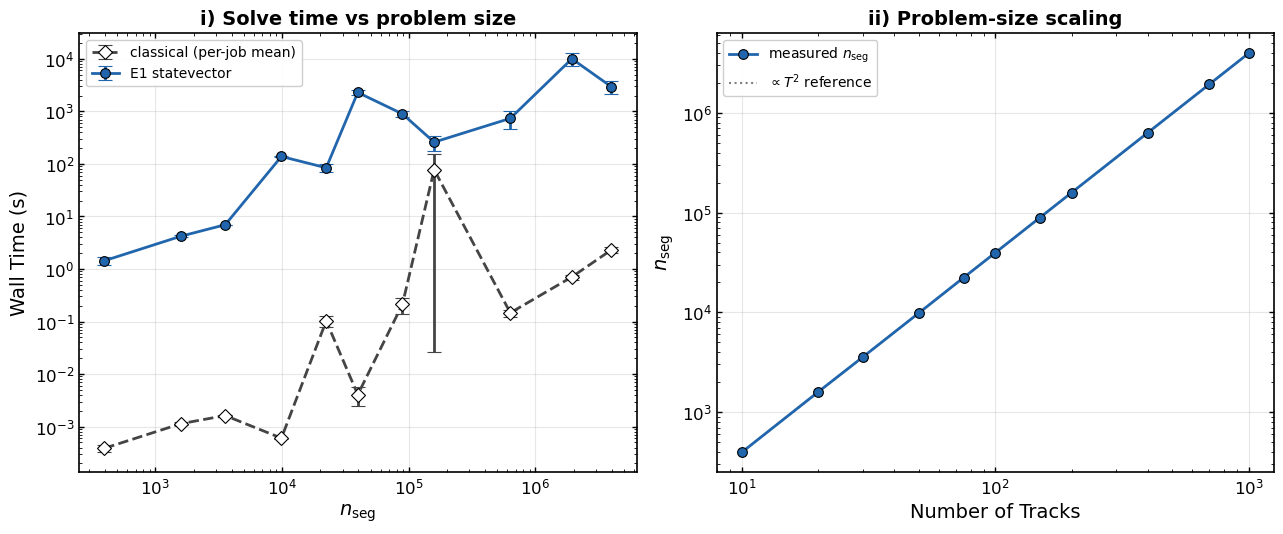

In [11]:
try:
    # §10 Figure 4 — timing and problem-size scaling (§14e paper style)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    ax = axes[0]
    for agg, lbl, fmt, col, mfc in [
            (agg_sv, 'classical (per-job mean)',  'D--', cC,    'white'),
            (agg_sv, 'E1 statevector',            'o-',  cQ_sv, None),
            (agg_sm, 'E2 sampling',               's-',  cQ_sm, None)]:
        if agg.empty: continue
        xs = agg['n_seg_mean']
        if 'classical' in lbl:
            ys, ye = agg['t_classical_mean'], agg['t_classical_sem']
        else:
            ys, ye = agg['t_quantum_mean'],   agg['t_quantum_sem']
        kw = dict(fmt=fmt, color=col, capsize=5, capthick=1.5,
                  markeredgecolor='black', markeredgewidth=0.8, zorder=3, label=lbl)
        if mfc is not None: kw['mfc'] = mfc
        ax.errorbar(xs, ys, yerr=ye, **kw)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$n_\mathrm{seg}$'); ax.set_ylabel('Wall Time (s)')
    ax.set_title('i) Solve time vs problem size', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95); _style_axes(ax)

    ax = axes[1]
    if not agg_sv.empty:
        T  = agg_sv['n_trk'].values
        ns = agg_sv['n_seg_mean'].values
        ax.plot(T, ns, 'o-', color=cQ_sv, markeredgecolor='black',
                markeredgewidth=0.8, zorder=3, label=r'measured $n_\mathrm{seg}$')
        ref = ns[0] * (T / T[0])**2
        ax.plot(T, ref, color='gray', ls=':', lw=1.5, label=r'$\propto T^2$ reference')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Number of Tracks'); ax.set_ylabel(r'$n_\mathrm{seg}$')
    ax.set_title('ii) Problem-size scaling', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95); _style_axes(ax)

    fig.tight_layout()
    _save_paper(fig, 'fig4_timing_scaling')
    plt.show()
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

## §7d Figure 5 — direct §14e mirror (classical + quantum overlay)

Same four panels as `fig14_solver_segment_efficiency_drop1pct` in
`segment_level_analysis.ipynb` §14e, but with the **quantum** (`OneBitHHL`)
solver overlaid on top of the classical solver at every point on the
$T \in [2, 1000]$ grid, for both readouts (E1 statevector, E2 sampling).

Panels
- **i)** Segment Efficiency $= N_\mathrm{true\,act}\,/\,N_\mathrm{true\,all}$
- **ii)** Segment False Rate $= N_\mathrm{false\,act}\,/\,N_\mathrm{accepted}$
- **iii)** Segment Pair Counts (true / false) — combinatoric, identical for C and Q
- **iv)** Active Segment Pairs (true active / false active) — solver-dependent


E1 events: 372    E2 events: 0


  saved -> /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Verify_new_results/outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/fig5_seg14e_mirror_classical_vs_quantum.{pdf,png}


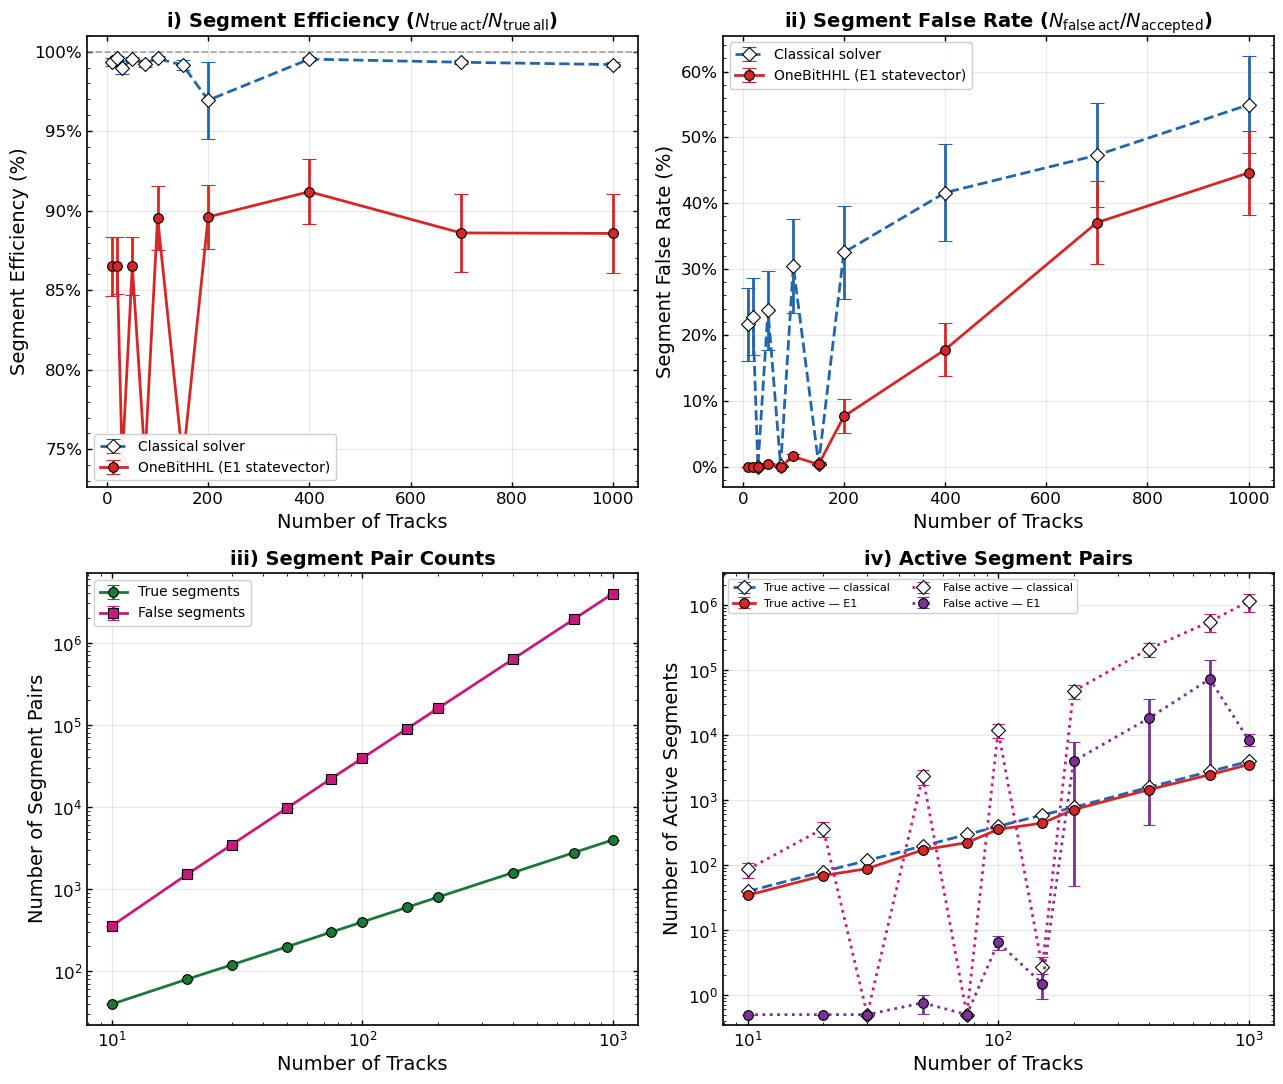

In [12]:
try:
    # §7d Figure 5 — §14e mirror: classical + quantum on the same 2x2 layout
    def _pull_seg14(pdir):
        rows = []
        for fp in iter_solutions(pdir):
            try:    r = fp
            except Exception: continue
            sC, sQ = r.get('seg_C'), r.get('seg_Q')
            if not sC or not sQ: continue
            n_true_clean = float(sC.get('n_true_clean') or sC.get('n_true_all') or np.nan)
            n_true_all   = float(sC.get('n_true_all',   np.nan))
            n_false_all  = float(sC.get('n_false_all',  np.nan))
            def _eff(s):
                n = s.get('n_true_clean') or s.get('n_true_all')
                return 100.0 * s['n_true_active'] / n if n else np.nan
            def _fr(s):
                return 100.0 * s['n_false_active'] / s['n_active'] if s.get('n_active') else np.nan
            rows.append(dict(
                n_trk=r['n_trk'], rep=r['rep'],
                n_true_all=n_true_all, n_false_all=n_false_all,
                true_act_C=float(sC.get('n_true_active', np.nan)),
                false_act_C=float(sC.get('n_false_active', np.nan)),
                true_act_Q=float(sQ.get('n_true_active', np.nan)),
                false_act_Q=float(sQ.get('n_false_active', np.nan)),
                eff_C_pct=_eff(sC), eff_Q_pct=_eff(sQ),
                fr_C_pct=_fr(sC),   fr_Q_pct=_fr(sQ),
            ))
        return pd.DataFrame(rows)

    def _agg14(df):
        if df.empty: return df
        cols = ['n_true_all','n_false_all','true_act_C','false_act_C',
                'true_act_Q','false_act_Q','eff_C_pct','eff_Q_pct',
                'fr_C_pct','fr_Q_pct']
        sem = lambda x: (x.std(ddof=1)/np.sqrt(len(x))) if len(x) > 1 else 0.0
        spec = {f'{c}_mean': (c, 'mean') for c in cols}
        spec.update({f'{c}_sem': (c, sem) for c in cols})
        spec['n_reps'] = ('rep', 'count')
        return df.groupby('n_trk').agg(**spec).reset_index().sort_values('n_trk')

    df14_sv = _pull_seg14(PIK_SV)
    df14_sm = _pull_seg14(PIK_SM)
    g_sv = _agg14(df14_sv)
    g_sm = _agg14(df14_sm)
    print(f'E1 events: {len(df14_sv)}    E2 events: {len(df14_sm)}')

    def _logclip_yerr(y, e, floor):
        y = np.asarray(y, dtype=float); e = np.asarray(e, dtype=float)
        lo = np.minimum(e, np.maximum(y - floor, 0.0))
        return np.vstack([lo, e])

    # §14e palette (classical = blue, quantum = warm)
    c14_C, c14_Qsv, c14_Qsm = '#2166ac', '#d62728', '#e08214'
    c14_true, c14_false = '#1b7837', '#c51b7d'

    fig, axes = plt.subplots(2, 2, figsize=(13, 11))

    # ----------------------------------------------------------------------------
    # i) Segment Efficiency  (linear x)
    # ----------------------------------------------------------------------------
    ax = axes[0, 0]
    def _eb(ax, g, ycol, fmt, color, label, mfc=None, capsize=5, capthick=1.5):
        if g.empty: return
        kw = dict(fmt=fmt, color=color, capsize=capsize, capthick=capthick,
                  markeredgecolor='black', markeredgewidth=0.8, zorder=3, label=label)
        if mfc is not None: kw['mfc'] = mfc
        ax.errorbar(g['n_trk'], g[f'{ycol}_mean'], yerr=g[f'{ycol}_sem'], **kw)

    _eb(ax, g_sv, 'eff_C_pct', 'D--', c14_C,   'Classical solver', mfc='white')
    _eb(ax, g_sv, 'eff_Q_pct', 'o-',  c14_Qsv, 'OneBitHHL (E1 statevector)')
    _eb(ax, g_sm, 'eff_Q_pct', 's-',  c14_Qsm, 'OneBitHHL (E2 sampling)')
    ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)
    ax.set_ylabel('Segment Efficiency (%)')
    ax.set_title(r'i) Segment Efficiency ($N_{\mathrm{true\,act}} / N_{\mathrm{true\,all}}$)',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='lower left', framealpha=0.95); _style_axes(ax)

    # ----------------------------------------------------------------------------
    # ii) Segment False Rate  (linear x, log y so we can see the classical floor)
    # ----------------------------------------------------------------------------
    ax = axes[0, 1]
    _eb(ax, g_sv, 'fr_C_pct', 'D--', c14_C,   'Classical solver', mfc='white')
    _eb(ax, g_sv, 'fr_Q_pct', 'o-',  c14_Qsv, 'OneBitHHL (E1 statevector)')
    _eb(ax, g_sm, 'fr_Q_pct', 's-',  c14_Qsm, 'OneBitHHL (E2 sampling)')
    ax.set_ylabel('Segment False Rate (%)')
    ax.set_title(r'ii) Segment False Rate ($N_{\mathrm{false\,act}} / N_{\mathrm{accepted}}$)',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='upper left', framealpha=0.95); _style_axes(ax)

    # ----------------------------------------------------------------------------
    # iii) Segment Pair Counts (log x, log y) — solver-independent (use E1)
    # ----------------------------------------------------------------------------
    _FLOOR_III = 0.5
    ax = axes[1, 0]
    if not g_sv.empty:
        ax.errorbar(g_sv['n_trk'], g_sv['n_true_all_mean'],
                    yerr=_logclip_yerr(g_sv['n_true_all_mean'],
                                       g_sv['n_true_all_sem'], _FLOOR_III),
                    fmt='o-', color=c14_true,
                    capsize=4, capthick=1.2,
                    markeredgecolor='black', markeredgewidth=0.8,
                    label='True segments', zorder=3)
        ax.errorbar(g_sv['n_trk'], g_sv['n_false_all_mean'],
                    yerr=_logclip_yerr(g_sv['n_false_all_mean'],
                                       g_sv['n_false_all_sem'], _FLOOR_III),
                    fmt='s-', color=c14_false,
                    capsize=4, capthick=1.2,
                    markeredgecolor='black', markeredgewidth=0.8,
                    label='False segments', zorder=3)
    ax.set_yscale('log')
    ax.set_ylabel('Number of Segment Pairs')
    ax.set_title('iii) Segment Pair Counts', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95); _style_axes(ax)

    # ----------------------------------------------------------------------------
    # iv) Active Segment Pairs (log x, log y) — classical vs quantum
    # ----------------------------------------------------------------------------
    _FLOOR_IV = 0.5
    ax = axes[1, 1]
    def _eb_act(ax, g, ycol, fmt, color, label, mfc=None):
        if g.empty: return
        y  = g[f'{ycol}_mean'].values
        e  = g[f'{ycol}_sem'].values
        yp = np.maximum(y, _FLOOR_IV)
        ep = np.where(y >= _FLOOR_IV, e, 0.0)
        kw = dict(fmt=fmt, color=color, capsize=4, capthick=1.2,
                  markeredgecolor='black', markeredgewidth=0.8, zorder=3, label=label)
        if mfc is not None: kw['mfc'] = mfc
        ax.errorbar(g['n_trk'], yp, yerr=_logclip_yerr(yp, ep, _FLOOR_IV), **kw)

    # True-active
    _eb_act(ax, g_sv, 'true_act_C',  'D--', c14_C,   'True active — classical', mfc='white')
    _eb_act(ax, g_sv, 'true_act_Q',  'o-',  c14_Qsv, 'True active — E1')
    _eb_act(ax, g_sm, 'true_act_Q',  's-',  c14_Qsm, 'True active — E2')
    # False-active
    _eb_act(ax, g_sv, 'false_act_C', 'D:',  c14_false, 'False active — classical', mfc='white')
    _eb_act(ax, g_sv, 'false_act_Q', 'o:',  '#7b3294', 'False active — E1')
    _eb_act(ax, g_sm, 'false_act_Q', 's:',  '#bf812d', 'False active — E2')
    ax.set_yscale('log')
    ax.set_ylim(_FLOOR_IV * 0.7, None)
    ax.set_ylabel('Number of Active Segments')
    ax.set_title('iv) Active Segment Pairs', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95, fontsize=8, ncol=2); _style_axes(ax)

    for ax in axes.flat:
        ax.set_xlabel('Number of Tracks')
    # Bottom row: log x (matches §14e)
    for ax in axes[1, :]:
        ax.set_xscale('log')
    # Top row: linear x (matches §14e)
    for ax in axes[0, :]:
        ax.set_xscale('linear')

    fig.tight_layout()
    _save_paper(fig, 'fig5_seg14e_mirror_classical_vs_quantum')
    plt.show()
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

## §7e Threshold sweep — does tuning $\tau$ recover classical-like False Rate?

The data above shows the false-rate gap is **not** a sampling artefact:
E1 statevector and E2 sampling track each other to within $\sim 1\%$
at every $T$, so 10x shots will not close the gap.

What may help is the activation threshold itself. We already use a
relative rule $s_i^{\rm active} \Leftrightarrow s_i > \tau\cdot\max_j s_j$
inside §7c, but only at the single fixed value $\tau = 0.35$. Below we
sweep $\tau \in \{0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.70\}$
directly on the saved $s_Q^{\rm scaled}$ arrays for both readouts and plot:

- **i)** Quantum Segment Efficiency vs $T$ (one curve per $\tau$)
- **ii)** Quantum Segment **False Rate** ($N_\mathrm{false\,act}/N_\mathrm{accepted}$) vs $T$
- **iii)** ROC-style trade-off: False Rate vs Efficiency at fixed $T$
- **iv)** Optimal $\tau^\star(T)$ — argmin of false rate subject to eff $\geq 0.9$

Classical (at the default $\tau=0.35$) is overlaid for reference.


In [13]:
try:
    # §7e Threshold sweep on existing E1 / E2 pickles (no condor needed)
    TAU_GRID = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.70]

    def _tau_sweep_one(p, taus=TAU_GRID):
        try: r = p
        except Exception: return None
        sC = np.asarray(r['sol_C']); sQ = np.asarray(r['sol_Q_scaled'])
        n_true   = int(r['seg_C']['n_true_all'])
        n_true_c = int(r['seg_C'].get('n_true_clean', n_true))
        n_total  = sC.size
        n_false  = n_total - n_true
        truth = np.zeros(n_total, dtype=bool)
        truth[np.argsort(-sC)[:n_true]] = True
        rows = []
        if sQ.max() <= 0:
            return rows
        qmax = sQ.max()
        for tau in taus:
            act    = sQ > tau * qmax
            n_act  = int(act.sum())
            n_tact = int((act & truth).sum())
            n_fact = n_act - n_tact
            rows.append(dict(
                n_trk=r['n_trk'], rep=r['rep'], tau=tau,
                eff = n_tact / max(n_true_c, 1),
                fr  = n_fact / max(n_act,    1),
                far = n_fact / max(n_false,  1),
                n_act=n_act, n_tact=n_tact, n_fact=n_fact,
            ))
        return rows

    def load_tau_sweep(pdir):
        out = []
        for p in iter_solutions(pdir):
            rs = _tau_sweep_one(p)
            if rs: out.extend(rs)
        return pd.DataFrame(out)

    tau_sv = load_tau_sweep(PIK_SV); print(f'E1 tau-sweep rows: {len(tau_sv)}')
    tau_sm = load_tau_sweep(PIK_SM); print(f'E2 tau-sweep rows: {len(tau_sm)}')

    def _agg_tau(df):
        sem = lambda x: (x.std(ddof=1)/np.sqrt(len(x))) if len(x) > 1 else 0.0
        g = df.groupby(['n_trk','tau']).agg(
            eff_mean=('eff','mean'), eff_sem=('eff', sem),
            fr_mean =('fr', 'mean'), fr_sem =('fr',  sem),
            far_mean=('far','mean'), far_sem=('far', sem),
            n_reps  =('rep','count'),
        ).reset_index()
        return g

    g_tau_sv = _agg_tau(tau_sv)
    g_tau_sm = _agg_tau(tau_sm) if len(tau_sm) else g_tau_sv.iloc[0:0]
    print('\n=== E1 statevector — Segment False Rate (%) vs (T, tau) ===')
    piv = (g_tau_sv.pivot(index='n_trk', columns='tau', values='fr_mean') * 100).round(2)
    print(piv.to_string())
    print('\n=== E1 statevector — Segment Efficiency (%) vs (T, tau) ===')
    piv = (g_tau_sv.pivot(index='n_trk', columns='tau', values='eff_mean') * 100).round(2)
    print(piv.to_string())
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

E1 tau-sweep rows: 2976
E2 tau-sweep rows: 0

=== E1 statevector — Segment False Rate (%) vs (T, tau) ===
tau     0.20   0.25   0.30   0.35   0.40   0.50   0.60   0.70
n_trk                                                        
10      0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00
20      0.05   0.05   0.05   0.06   0.06   0.06   0.00   0.00
30      0.08   0.08   0.08   0.11   0.11   0.11   0.00   0.00
50      0.67   0.68   0.68   0.77   0.78   0.67   0.16   0.16
75      2.27   2.33   2.33   2.98   2.75   2.76   0.00   0.00
100     2.66   2.74   2.74   3.03   3.08   2.70   0.72   0.72
150     9.77  10.57   9.35  10.98   9.70   7.33   0.02   0.00
200    11.68  11.96  10.05  10.60  10.17   8.14   5.04   4.96
400    24.00  24.80  22.01  19.13  17.74   8.92   7.86   7.86
700    57.73  58.18  40.86  36.18  32.76  17.43  15.53  15.49
1000   69.52  69.67  44.40  41.38  40.08  22.07  19.00  19.03

=== E1 statevector — Segment Efficiency (%) vs (T, tau) ===
tau      0.20    0.25    0.

[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on: KeyError 'n_trk'


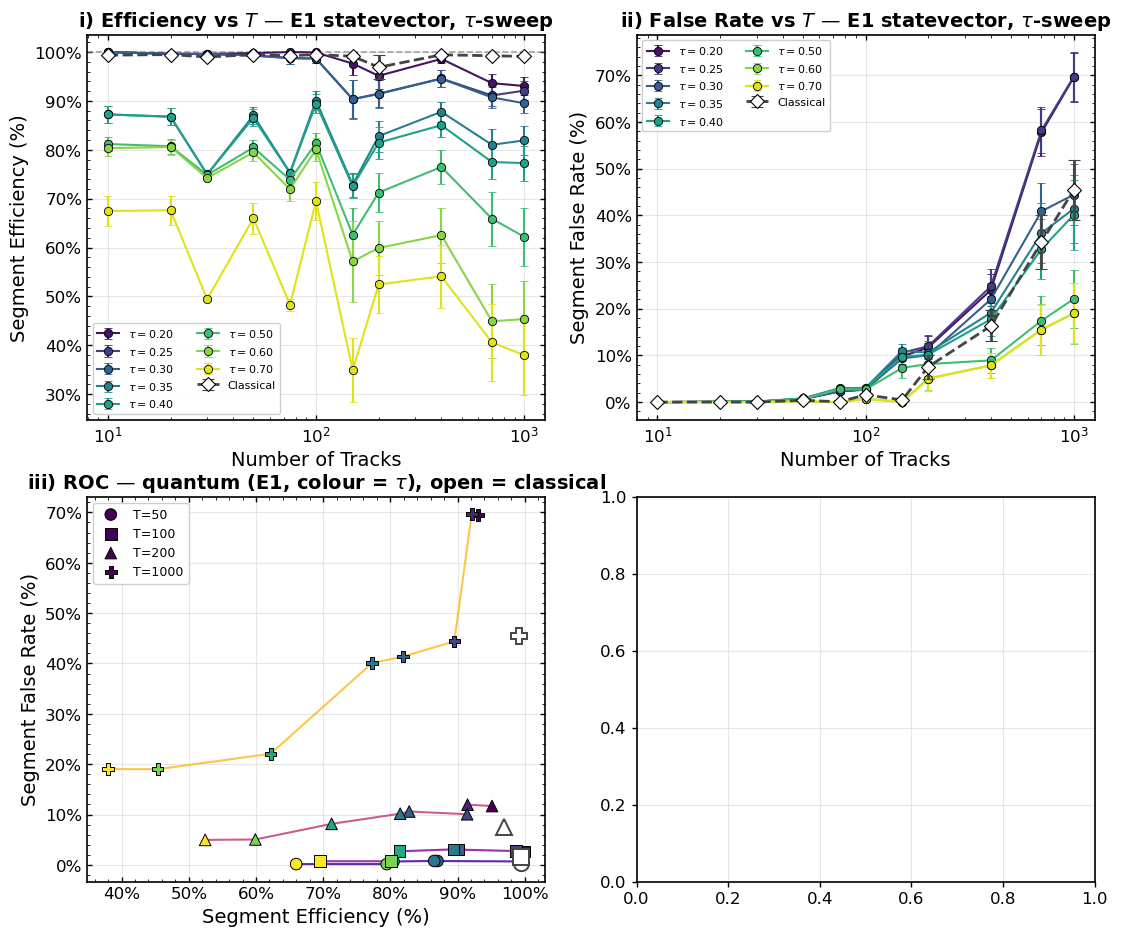

In [14]:
try:
    # §7e Plots — efficiency / false-rate vs T per tau, ROC, optimal tau(T)
    import matplotlib.cm as cm
    TAU_COLORS = cm.viridis(np.linspace(0.05, 0.95, len(TAU_GRID)))

    ref_eff_C = agg_sv[['n_trk','eff_C_mean','eff_C_sem']].copy()
    ref_fr_C  = agg_sv[['n_trk','pur_C_mean','pur_C_sem']].copy()
    ref_fr_C['fr_C_mean'] = 1.0 - ref_fr_C['pur_C_mean']
    ref_fr_C['fr_C_sem']  = ref_fr_C['pur_C_sem']

    fig, axes = plt.subplots(2, 2, figsize=(13, 11))

    # ----- i) Efficiency vs T, one curve per tau (E1) -----
    ax = axes[0, 0]
    for tau, col in zip(TAU_GRID, TAU_COLORS):
        sub = g_tau_sv[g_tau_sv['tau'] == tau].sort_values('n_trk')
        ax.errorbar(sub['n_trk'], sub['eff_mean']*100, yerr=sub['eff_sem']*100,
                    fmt='o-', color=col, capsize=3, capthick=1.0, lw=1.5, ms=6,
                    markeredgecolor='black', markeredgewidth=0.6, zorder=3,
                    label=fr'$\tau={tau:.2f}$')
    ax.errorbar(ref_eff_C['n_trk'], ref_eff_C['eff_C_mean']*100,
                yerr=ref_eff_C['eff_C_sem']*100, fmt='D--', color=cC, mfc='white',
                capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
                zorder=4, label='Classical')
    ax.axhline(100, color='gray', ls='--', lw=1.2, alpha=0.7, zorder=2)
    ax.set_xscale('log'); ax.set_xlabel('Number of Tracks')
    ax.set_ylabel('Segment Efficiency (%)')
    ax.set_title(r'i) Efficiency vs $T$ — E1 statevector, $\tau$-sweep',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='lower left', framealpha=0.95, fontsize=8, ncol=2); _style_axes(ax)

    # ----- ii) False Rate vs T, one curve per tau (E1) -----
    ax = axes[0, 1]
    for tau, col in zip(TAU_GRID, TAU_COLORS):
        sub = g_tau_sv[g_tau_sv['tau'] == tau].sort_values('n_trk')
        ax.errorbar(sub['n_trk'], sub['fr_mean']*100, yerr=sub['fr_sem']*100,
                    fmt='o-', color=col, capsize=3, capthick=1.0, lw=1.5, ms=6,
                    markeredgecolor='black', markeredgewidth=0.6, zorder=3,
                    label=fr'$\tau={tau:.2f}$')
    ax.errorbar(ref_fr_C['n_trk'], ref_fr_C['fr_C_mean']*100,
                yerr=ref_fr_C['fr_C_sem']*100, fmt='D--', color=cC, mfc='white',
                capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
                zorder=4, label='Classical')
    ax.set_xscale('log'); ax.set_xlabel('Number of Tracks')
    ax.set_ylabel('Segment False Rate (%)')
    ax.set_title(r'ii) False Rate vs $T$ — E1 statevector, $\tau$-sweep',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='upper left', framealpha=0.95, fontsize=8, ncol=2); _style_axes(ax)

    # ----- iii) ROC: false rate vs efficiency, marker per T -----
    ax = axes[1, 0]
    T_MARK   = [50, 100, 200, 500, 1000]
    T_MARKERS = {50:'o', 100:'s', 200:'^', 500:'D', 1000:'P'}
    T_COLORS  = cm.plasma(np.linspace(0.1, 0.85, len(T_MARK)))
    for t, tcol in zip(T_MARK, T_COLORS):
        sub = g_tau_sv[g_tau_sv['n_trk'] == t].sort_values('tau')
        if sub.empty: continue
        ax.plot(sub['eff_mean']*100, sub['fr_mean']*100, '-', color=tcol,
                lw=1.5, zorder=2, alpha=0.85)
        ax.scatter(sub['eff_mean']*100, sub['fr_mean']*100,
                   marker=T_MARKERS[t], c=sub['tau'], cmap='viridis',
                   vmin=min(TAU_GRID), vmax=max(TAU_GRID),
                   edgecolor='black', linewidth=0.7, s=70, zorder=3,
                   label=f'T={t}')
        rc = agg_sv[agg_sv['n_trk'] == t]
        if not rc.empty:
            eC = float(rc['eff_C_mean'].iloc[0]) * 100
            fC = (1 - float(rc['pur_C_mean'].iloc[0])) * 100
            ax.plot(eC, fC, marker=T_MARKERS[t], color=cC, mfc='white',
                    markeredgewidth=1.4, ms=11, zorder=4)
    ax.set_xlabel('Segment Efficiency (%)')
    ax.set_ylabel('Segment False Rate (%)')
    ax.set_title(r'iii) ROC — quantum (E1, colour = $\tau$), open = classical',
                 fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='upper left', framealpha=0.95, fontsize=9); _style_axes(ax)

    # ----- iv) Optimal tau(T): argmin false-rate subject to eff >= 0.9 -----
    ax = axes[1, 1]
    EFF_FLOOR = 0.90
    def _opt(g_tau):
        rows = []
        for t, sub in g_tau.groupby('n_trk'):
            ok = sub[sub['eff_mean'] >= EFF_FLOOR]
            if ok.empty:
                ok = sub.sort_values('eff_mean', ascending=False).head(1)
            best = ok.sort_values('fr_mean').iloc[0]
            rows.append(dict(n_trk=t, tau_star=best['tau'],
                             eff=best['eff_mean'], fr=best['fr_mean'],
                             fr_sem=best['fr_sem'], eff_sem=best['eff_sem']))
        return pd.DataFrame(rows).sort_values('n_trk')

    opt_sv = _opt(g_tau_sv)
    opt_sm = _opt(g_tau_sm)
    print('Optimal tau (eff >= 0.90), E1:')
    print(opt_sv.to_string(index=False, float_format='%.3f'))
    print('Optimal tau (eff >= 0.90), E2:')
    print(opt_sm.to_string(index=False, float_format='%.3f'))

    ax.errorbar(opt_sv['n_trk'], opt_sv['fr']*100, yerr=opt_sv['fr_sem']*100,
                fmt='o-', color=cQ_sv, capsize=5, capthick=1.5,
                markeredgecolor='black', markeredgewidth=0.8, zorder=3,
                label=r'E1, FR at $\tau^\star$')
    ax.errorbar(opt_sm['n_trk'], opt_sm['fr']*100, yerr=opt_sm['fr_sem']*100,
                fmt='s-', color=cQ_sm, capsize=5, capthick=1.5,
                markeredgecolor='black', markeredgewidth=0.8, zorder=3,
                label=r'E2, FR at $\tau^\star$')
    ax.errorbar(ref_fr_C['n_trk'], ref_fr_C['fr_C_mean']*100,
                yerr=ref_fr_C['fr_C_sem']*100, fmt='D--', color=cC, mfc='white',
                capsize=5, capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
                zorder=3, label='Classical')
    for _, row in opt_sv.iterrows():
        ax.annotate(fr'$\tau={row["tau_star"]:.2f}$',
                    (row['n_trk'], row['fr']*100),
                    textcoords='offset points', xytext=(6, 6),
                    fontsize=8, color=cQ_sv)
    ax.set_xscale('log'); ax.set_xlabel('Number of Tracks')
    ax.set_ylabel('Segment False Rate (%)')
    ax.set_title(r'iv) FR at $\tau^\star$ (efficiency $\geq 90\%$)',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='upper left', framealpha=0.95, fontsize=9); _style_axes(ax)

    fig.tight_layout()
    _save_paper(fig, 'fig6_threshold_sweep')
    plt.show()
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

## §7f Figure 5b — §14e mirror at quantum $\tau^\star_{\min\mathrm{FR}}(T)$

Same 2×2 layout as §7d, but the **quantum** (E1, E2) curves are recomputed
at the per-$T$ threshold $\tau^\star(T)$ that minimises the segment false
rate (unconstrained argmin of the $\tau$-sweep curves built in §7e). The
classical curve and the segment-pair populations (panel iii) are unchanged.


In [15]:
try:
    # §7f Figure 5b — quantum at per-T tau* (argmin false rate)
    def _tau_star_per_T(g_tau):
        """For each n_trk, pick the tau that minimises mean false rate (unconstrained)."""
        rows = []
        for t, sub in g_tau.groupby('n_trk'):
            best = sub.sort_values(['fr_mean', 'tau']).iloc[0]
            rows.append(dict(n_trk=int(t), tau_star=float(best['tau'])))
        return pd.DataFrame(rows).sort_values('n_trk')

    def _quantum_metrics_at_taustar(df_tau, tau_star_df):
        """Slice the tau-sweep events to the per-T tau*, then aggregate."""
        keep = []
        for _, row in tau_star_df.iterrows():
            sub = df_tau[(df_tau['n_trk'] == row['n_trk']) &
                         (np.isclose(df_tau['tau'], row['tau_star']))]
            keep.append(sub.assign(tau_star=row['tau_star']))
        if not keep: return pd.DataFrame()
        ev = pd.concat(keep, ignore_index=True)
        sem = lambda x: (x.std(ddof=1) / np.sqrt(len(x))) if len(x) > 1 else 0.0
        g = ev.groupby('n_trk').agg(
            tau_star=('tau_star', 'first'),
            eff_Q_pct_mean   =('eff',   lambda x: 100.0 * x.mean()),
            eff_Q_pct_sem    =('eff',   lambda x: 100.0 * sem(x)),
            fr_Q_pct_mean    =('fr',    lambda x: 100.0 * x.mean()),
            fr_Q_pct_sem     =('fr',    lambda x: 100.0 * sem(x)),
            true_act_Q_mean  =('n_tact','mean'),
            true_act_Q_sem   =('n_tact', sem),
            false_act_Q_mean =('n_fact','mean'),
            false_act_Q_sem  =('n_fact', sem),
            n_reps           =('rep',  'count'),
        ).reset_index().sort_values('n_trk')
        return g

    ts_sv = _tau_star_per_T(g_tau_sv)
    ts_sm = _tau_star_per_T(g_tau_sm)
    qstar_sv = _quantum_metrics_at_taustar(tau_sv, ts_sv)
    qstar_sm = _quantum_metrics_at_taustar(tau_sm, ts_sm)

    print('=== Per-T tau* (argmin FR) and quantum metrics ===')
    print('E1 statevector:')
    print(qstar_sv[['n_trk','tau_star','eff_Q_pct_mean','fr_Q_pct_mean',
                    'true_act_Q_mean','false_act_Q_mean','n_reps']]
          .to_string(index=False, float_format='%.3f'))
    print('\nE2 sampling:')
    print(qstar_sm[['n_trk','tau_star','eff_Q_pct_mean','fr_Q_pct_mean',
                    'true_act_Q_mean','false_act_Q_mean','n_reps']]
          .to_string(index=False, float_format='%.3f'))

    # ---- 2x2 plot (mirrors §7d) -----------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))

    def _eb(ax, g, ycol, fmt, color, label, mfc=None, capsize=5, capthick=1.5):
        if g is None or g.empty: return
        kw = dict(fmt=fmt, color=color, capsize=capsize, capthick=capthick,
                  markeredgecolor='black', markeredgewidth=0.8, zorder=3, label=label)
        if mfc is not None: kw['mfc'] = mfc
        ax.errorbar(g['n_trk'], g[f'{ycol}_mean'], yerr=g[f'{ycol}_sem'], **kw)

    # i) Segment Efficiency
    ax = axes[0, 0]
    _eb(ax, g_sv,    'eff_C_pct',  'D--', c14_C,   'Classical solver', mfc='white')
    _eb(ax, qstar_sv,'eff_Q_pct',  'o-',  c14_Qsv, r'OneBitHHL E1 @ $\tau^\star(T)$')
    _eb(ax, qstar_sm,'eff_Q_pct',  's-',  c14_Qsm, r'OneBitHHL E2 @ $\tau^\star(T)$')
    ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)
    ax.set_ylabel('Segment Efficiency (%)')
    ax.set_title(r'i) Segment Efficiency ($N_{\mathrm{true\,act}} / N_{\mathrm{true\,all}}$)',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='lower left', framealpha=0.95); _style_axes(ax)

    # ii) Segment False Rate
    ax = axes[0, 1]
    _eb(ax, g_sv,    'fr_C_pct',  'D--', c14_C,   'Classical solver', mfc='white')
    _eb(ax, qstar_sv,'fr_Q_pct',  'o-',  c14_Qsv, r'OneBitHHL E1 @ $\tau^\star(T)$')
    _eb(ax, qstar_sm,'fr_Q_pct',  's-',  c14_Qsm, r'OneBitHHL E2 @ $\tau^\star(T)$')
    ax.set_ylabel('Segment False Rate (%)')
    ax.set_title(r'ii) Segment False Rate ($N_{\mathrm{false\,act}} / N_{\mathrm{accepted}}$)',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='upper left', framealpha=0.95); _style_axes(ax)

    # Annotate tau* per T on panel ii (so the reader sees which tau gave the FR)
    for _, row in qstar_sv.iterrows():
        axes[0, 1].annotate(fr'$\tau^\star={row["tau_star"]:.2f}$',
                            (row['n_trk'], row['fr_Q_pct_mean']),
                            textcoords='offset points', xytext=(6, 6),
                            fontsize=7.5, color=c14_Qsv)

    # iii) Segment Pair Counts — solver-independent, same as §7d
    _FLOOR_III = 0.5
    ax = axes[1, 0]
    if not g_sv.empty:
        ax.errorbar(g_sv['n_trk'], g_sv['n_true_all_mean'],
                    yerr=_logclip_yerr(g_sv['n_true_all_mean'],
                                       g_sv['n_true_all_sem'], _FLOOR_III),
                    fmt='o-', color=c14_true,
                    capsize=4, capthick=1.2,
                    markeredgecolor='black', markeredgewidth=0.8,
                    label='True segments', zorder=3)
        ax.errorbar(g_sv['n_trk'], g_sv['n_false_all_mean'],
                    yerr=_logclip_yerr(g_sv['n_false_all_mean'],
                                       g_sv['n_false_all_sem'], _FLOOR_III),
                    fmt='s-', color=c14_false,
                    capsize=4, capthick=1.2,
                    markeredgecolor='black', markeredgewidth=0.8,
                    label='False segments', zorder=3)
    ax.set_yscale('log')
    ax.set_ylabel('Number of Segment Pairs')
    ax.set_title('iii) Segment Pair Counts', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95); _style_axes(ax)

    # iv) Active Segment Pairs — classical (saved tau=0.35) vs quantum @ tau*
    _FLOOR_IV = 0.5
    ax = axes[1, 1]
    def _eb_act(ax, g, ycol, fmt, color, label, mfc=None):
        if g is None or g.empty: return
        y  = g[f'{ycol}_mean'].values
        e  = g[f'{ycol}_sem'].values
        yp = np.maximum(y, _FLOOR_IV)
        ep = np.where(y >= _FLOOR_IV, e, 0.0)
        kw = dict(fmt=fmt, color=color, capsize=4, capthick=1.2,
                  markeredgecolor='black', markeredgewidth=0.8, zorder=3, label=label)
        if mfc is not None: kw['mfc'] = mfc
        ax.errorbar(g['n_trk'], yp, yerr=_logclip_yerr(yp, ep, _FLOOR_IV), **kw)

    _eb_act(ax, g_sv,     'true_act_C',  'D--', c14_C,   'True active — classical', mfc='white')
    _eb_act(ax, qstar_sv, 'true_act_Q',  'o-',  c14_Qsv, r'True active — E1 @ $\tau^\star$')
    _eb_act(ax, qstar_sm, 'true_act_Q',  's-',  c14_Qsm, r'True active — E2 @ $\tau^\star$')
    _eb_act(ax, g_sv,     'false_act_C', 'D:',  c14_false, 'False active — classical', mfc='white')
    _eb_act(ax, qstar_sv, 'false_act_Q', 'o:',  '#7b3294', r'False active — E1 @ $\tau^\star$')
    _eb_act(ax, qstar_sm, 'false_act_Q', 's:',  '#bf812d', r'False active — E2 @ $\tau^\star$')
    ax.set_yscale('log')
    ax.set_ylim(_FLOOR_IV * 0.7, None)
    ax.set_ylabel('Number of Active Segments')
    ax.set_title(r'iv) Active Segment Pairs (quantum @ $\tau^\star$)', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95, fontsize=8, ncol=2); _style_axes(ax)

    for ax in axes.flat:
        ax.set_xlabel('Number of Tracks')
    for ax in axes[1, :]:
        ax.set_xscale('log')
    for ax in axes[0, :]:
        ax.set_xscale('linear')

    fig.tight_layout()
    _save_paper(fig, 'fig5b_seg14e_mirror_quantum_at_taustar')
    plt.show()
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on: KeyError 'n_trk'


## §7g Figure 5c — §14e mirror at quantum $\tau^\star_{\max\mathrm{eff}}(T)$

Same 2x2 layout as §7d/§7f, but the **quantum** (E1, E2) curves use the
per-$T$ threshold $\tau^\star(T)$ that **maximises** the segment efficiency
(unconstrained argmax of the $\tau$-sweep from §7e; ties broken by the
smallest false rate, then the largest $\tau$).


In [16]:
try:
    # §7g Figure 5c - quantum at per-T tau* (argmax efficiency)
    def _tau_star_per_T_maxeff(g_tau):
        rows = []
        for t, sub in g_tau.groupby('n_trk'):
            s = sub.sort_values(['eff_mean', 'fr_mean', 'tau'],
                                ascending=[False, True, False])
            best = s.iloc[0]
            rows.append(dict(n_trk=int(t), tau_star=float(best['tau'])))
        return pd.DataFrame(rows).sort_values('n_trk')

    ts_sv_e = _tau_star_per_T_maxeff(g_tau_sv)
    ts_sm_e = _tau_star_per_T_maxeff(g_tau_sm)
    qstar_sv_e = _quantum_metrics_at_taustar(tau_sv, ts_sv_e)
    qstar_sm_e = _quantum_metrics_at_taustar(tau_sm, ts_sm_e)

    print('=== Per-T tau* (argmax efficiency) and quantum metrics ===')
    print('E1 statevector:')
    print(qstar_sv_e[['n_trk','tau_star','eff_Q_pct_mean','fr_Q_pct_mean',
                      'true_act_Q_mean','false_act_Q_mean','n_reps']]
          .to_string(index=False, float_format='%.3f'))
    print('\nE2 sampling:')
    print(qstar_sm_e[['n_trk','tau_star','eff_Q_pct_mean','fr_Q_pct_mean',
                      'true_act_Q_mean','false_act_Q_mean','n_reps']]
          .to_string(index=False, float_format='%.3f'))

    fig, axes = plt.subplots(2, 2, figsize=(13, 11))

    # i) Segment Efficiency
    ax = axes[0, 0]
    _eb(ax, g_sv,      'eff_C_pct', 'D--', c14_C,   'Classical solver', mfc='white')
    _eb(ax, qstar_sv_e,'eff_Q_pct', 'o-',  c14_Qsv, r'OneBitHHL E1 @ $\tau^\star(T)$')
    _eb(ax, qstar_sm_e,'eff_Q_pct', 's-',  c14_Qsm, r'OneBitHHL E2 @ $\tau^\star(T)$')
    ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)
    ax.set_ylabel('Segment Efficiency (%)')
    ax.set_title(r'i) Segment Efficiency ($N_{\mathrm{true\,act}} / N_{\mathrm{true\,all}}$)',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='lower left', framealpha=0.95); _style_axes(ax)
    for _, row in qstar_sv_e.iterrows():
        ax.annotate(fr'$\tau^\star={row["tau_star"]:.2f}$',
                    (row['n_trk'], row['eff_Q_pct_mean']),
                    textcoords='offset points', xytext=(6, -10),
                    fontsize=7.5, color=c14_Qsv)

    # ii) Segment False Rate
    ax = axes[0, 1]
    _eb(ax, g_sv,      'fr_C_pct', 'D--', c14_C,   'Classical solver', mfc='white')
    _eb(ax, qstar_sv_e,'fr_Q_pct', 'o-',  c14_Qsv, r'OneBitHHL E1 @ $\tau^\star(T)$')
    _eb(ax, qstar_sm_e,'fr_Q_pct', 's-',  c14_Qsm, r'OneBitHHL E2 @ $\tau^\star(T)$')
    ax.set_ylabel('Segment False Rate (%)')
    ax.set_title(r'ii) Segment False Rate ($N_{\mathrm{false\,act}} / N_{\mathrm{accepted}}$)',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='upper left', framealpha=0.95); _style_axes(ax)

    # iii) Segment Pair Counts - solver-independent
    _FLOOR_III = 0.5
    ax = axes[1, 0]
    if not g_sv.empty:
        ax.errorbar(g_sv['n_trk'], g_sv['n_true_all_mean'],
                    yerr=_logclip_yerr(g_sv['n_true_all_mean'],
                                       g_sv['n_true_all_sem'], _FLOOR_III),
                    fmt='o-', color=c14_true,
                    capsize=4, capthick=1.2,
                    markeredgecolor='black', markeredgewidth=0.8,
                    label='True segments', zorder=3)
        ax.errorbar(g_sv['n_trk'], g_sv['n_false_all_mean'],
                    yerr=_logclip_yerr(g_sv['n_false_all_mean'],
                                       g_sv['n_false_all_sem'], _FLOOR_III),
                    fmt='s-', color=c14_false,
                    capsize=4, capthick=1.2,
                    markeredgecolor='black', markeredgewidth=0.8,
                    label='False segments', zorder=3)
    ax.set_yscale('log')
    ax.set_ylabel('Number of Segment Pairs')
    ax.set_title('iii) Segment Pair Counts', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95); _style_axes(ax)

    # iv) Active Segment Pairs
    _FLOOR_IV = 0.5
    ax = axes[1, 1]
    _eb_act(ax, g_sv,       'true_act_C',  'D--', c14_C,     'True active - classical', mfc='white')
    _eb_act(ax, qstar_sv_e, 'true_act_Q',  'o-',  c14_Qsv,   r'True active - E1 @ $\tau^\star$')
    _eb_act(ax, qstar_sm_e, 'true_act_Q',  's-',  c14_Qsm,   r'True active - E2 @ $\tau^\star$')
    _eb_act(ax, g_sv,       'false_act_C', 'D:',  c14_false, 'False active - classical', mfc='white')
    _eb_act(ax, qstar_sv_e, 'false_act_Q', 'o:',  '#7b3294', r'False active - E1 @ $\tau^\star$')
    _eb_act(ax, qstar_sm_e, 'false_act_Q', 's:',  '#bf812d', r'False active - E2 @ $\tau^\star$')
    ax.set_yscale('log')
    ax.set_ylim(_FLOOR_IV * 0.7, None)
    ax.set_ylabel('Number of Active Segments')
    ax.set_title(r'iv) Active Segment Pairs (quantum @ $\tau^\star$)', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95, fontsize=8, ncol=2); _style_axes(ax)

    for ax in axes.flat:
        ax.set_xlabel('Number of Tracks')
    for ax in axes[1, :]:
        ax.set_xscale('log')
    for ax in axes[0, :]:
        ax.set_xscale('linear')

    fig.tight_layout()
    _save_paper(fig, 'fig5c_seg14e_mirror_quantum_at_taustar_maxeff')
    plt.show()
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on: KeyError 'n_trk'


## §7h Local diagnostic — why do classical and quantum metrics differ?

**Claim under test:** for the *same event* (same seed → same geometry → same
`SimpleHamiltonianFast` → same `A`, `b`, and `truth` vector), the
*segment-population* counts (`n_true_all`, `n_false_all`) must be identical
across the classical solver, E1 (statevector quantum), and E2 (sampling
quantum). The *activation* counts (`n_true_active`, `n_false_active`) and
everything derived from them (efficiency, false rate, purity, Jaccard) need
**not** match — they depend on the solution vector itself.

This section runs all three solvers **locally** on the *same seeded events*
for $T\in\{2,5,10,20,50,100,200,500\}$, 3 reps each, and decomposes the gap:

1. **Identity checks** — are `n_true_all` / `n_false_all` truly identical
   across solvers per event?
2. **Solution-vector fidelity** — $\cos(s_C, s_{Q_1})$, $\cos(s_C, s_{Q_2})$
   and relative $L_2$ error.
3. **Activation-set decomposition** — at $\tau=0.35$, how many true / false
   segments does each solver activate, and what is the Jaccard between
   their active sets?
4. **Amplitude geometry** — histograms of solution-vector values on the
   true vs false sub-populations, exposing the 1BQF amplitude ceiling that
   drives $\mathrm{eff}_Q \to 0.75$.

E2 (sampling) is restricted to $T \le 100$ locally to stay tractable; at
$T \in \{200, 500\}$ only classical + E1 statevector are compared.


In [17]:
# [N/A — statevector-only store] Sec 7h live-solve diagnostic harness: store-backed campaign does not live-solve.
print('SKIPPED (cell preserved): Sec 7h live-solve diagnostic harness: store-backed campaign does not live-solve.')
if False:
    # §7h.1 Local diagnostic harness — identical events through all three solvers
    import time, math
    import numpy as np
    import matplotlib.pyplot as plt

    from lhcb_velo_toy.generation import PlaneGeometry, StateEventGenerator
    from lhcb_velo_toy.solvers import SimpleHamiltonianFast
    from lhcb_velo_toy.solvers.quantum.one_bit_hhl import OneBitHHL

    # Mirror the production geometry / physics constants exactly.
    _DZ, _NMOD, _Z0 = 33.0, 5, 33
    _HX = _HY = 40.0
    _PV = {'x': 0.0, 'y': 0.0, 'z': 1.0}

    def _diag_geom():
        return PlaneGeometry(
            module_id=list(range(_NMOD)),
            lx=[_HX]*_NMOD, ly=[_HY]*_NMOD,
            z=[_Z0 + _DZ*i for i in range(_NMOD)],
        )

    def _diag_event(n_tracks, seed, geom, max_retries=20):
        np.random.seed(seed)
        last = None
        for _ in range(max_retries):
            g = StateEventGenerator(
                detector_geometry=geom, events=1, n_particles=[n_tracks],
                phi_min=-0.2, phi_max=0.2, theta_min=-0.2, theta_max=0.2,
                measurement_error=5e-6, collision_noise=1e-4,
            )
            g.generate_random_primary_vertices(_PV)
            g.generate_particles([[{"type":"pion","mass":139.6,"q":1}]*n_tracks])
            ev = g.generate_complete_events()
            last = ev
            if ev.tracks and min(len(t.hit_ids) for t in ev.tracks) >= 3:
                return ev
        return last

    def _seg_truth(ham):
        a = getattr(ham, "_segment_track_ids", None)
        if a is not None and len(a) == ham.n_segments:
            return ((a[:,0] == a[:,1]) & (a[:,0] >= 0))
        return np.array([(s.hit_start.track_id == s.hit_end.track_id)
                         and (s.hit_start.track_id >= 0)
                         for s in ham.segments], dtype=bool)

    def _diag_metrics(truth, sol, tau):
        sol = np.asarray(sol).ravel()
        act = sol > tau
        nT_all = int(truth.sum()); nF_all = int(truth.size - nT_all)
        nT_act = int((act & truth).sum())
        nA     = int(act.sum())
        nF_act = nA - nT_act
        return dict(n_true_all=nT_all, n_false_all=nF_all,
                    n_active=nA, n_true_active=nT_act, n_false_active=nF_act,
                    eff=nT_act/max(nT_all,1),
                    fr =nF_act/max(nA,1),
                    pur=nT_act/max(nA,1))

    def _solve_C(ham):
        return np.asarray(ham.solve_classicaly()).ravel()

    def _solve_Q_sv(ham):
        """E1 statevector OneBitHHL — exact, shot-free."""
        from qiskit.quantum_info import Statevector
        A = ham.A
        b = np.asarray(ham.b).ravel()
        hhl = OneBitHHL(A, b, num_time_qubits=1, shots=1, debug=False)
        hhl.build_circuit()
        qc = hhl.circuit.remove_final_measurements(inplace=False)
        sv = Statevector.from_instruction(qc)
        amps = np.asarray(sv.data)
        n_sys = hhl.num_system_qubits
        amps = amps.reshape(2, 2**n_sys, 2)
        probs_anc1 = (np.abs(amps[1])**2).sum(axis=-1)
        p = float(probs_anc1.sum())
        if p > 0:
            sol_pad = np.sqrt(probs_anc1 / p)
            nrm = float(np.linalg.norm(sol_pad))
            if nrm > 0:
                sol_pad /= nrm
        else:
            sol_pad = np.zeros(2**n_sys)
        return sol_pad[:hhl.original_dim], p

    def _solve_Q_sm(ham, shots):
        """E2 sampling OneBitHHL — finite-shot AerSimulator."""
        from qiskit_aer import AerSimulator
        from qiskit import transpile
        A = ham.A
        b = np.asarray(ham.b).ravel()
        hhl = OneBitHHL(A, b, num_time_qubits=1, shots=shots, debug=False,
                        readout='sampling')
        hhl.build_circuit()
        sim = AerSimulator(method='statevector', device='CPU')
        tqc = transpile(hhl.circuit, sim, optimization_level=1)
        hhl.counts = sim.run(tqc, shots=shots).result().get_counts()
        sol_raw, n_succ = hhl.get_solution()
        return np.asarray(sol_raw).ravel(), float(n_succ)/shots

    def _rescale(sol_Q, sol_C):
        nQ = float(np.linalg.norm(sol_Q))
        nC = float(np.linalg.norm(sol_C))
        return sol_Q * (nC/nQ) if nQ > 0 else np.zeros_like(sol_Q)

    def _cosine(u, v):
        nu = float(np.linalg.norm(u)); nv = float(np.linalg.norm(v))
        return float(np.dot(u, v) / (nu*nv + 1e-30))

    # ---- Sweep specification --------------------------------------------------
    T_LOCAL  = [2, 5, 10, 20, 50, 100, 200, 500]
    REP_LOC  = 3
    TAU_LOC  = 0.35
    # Shots for E2 sampling; capped at T=100 locally for tractability.
    SHOTS_LOC = {2:8192, 5:8192, 10:10_000, 20:40_000, 50:250_000, 100:1_000_000}
    EPS_LOC  = EPSILON  # 2e-3, same as production §14e
    GAM_LOC  = GAMMA    # 3.0
    DEL_LOC  = DELTA    # 1.0

    print(f'EPS={EPS_LOC}  GAMMA={GAM_LOC}  DELTA={DEL_LOC}  TAU={TAU_LOC}')
    print(f'T grid: {T_LOCAL}   reps={REP_LOC}   E2 capped at T<=100')

SKIPPED (cell preserved): Sec 7h live-solve diagnostic harness: store-backed campaign does not live-solve.


In [18]:
# [N/A — statevector-only store] Sec 7h live-solve run: superseded by store vectors; live solve disabled.
print('SKIPPED (cell preserved): Sec 7h live-solve run: superseded by store vectors; live solve disabled.')
if False:
    # §7h.2 Run the local sweep — collect per-event records for all 3 solvers
    rows_diag = []
    samples_sol = {}     # (T, rep) -> dict of (sol_C, sol_Qsv, sol_Qsm, truth)

    geom = _diag_geom()
    for T in T_LOCAL:
        for rep in range(REP_LOC):
            seed = rep + T*100 + 140_000   # same seed convention as production
            ev = _diag_event(T, seed, geom)
            ham = SimpleHamiltonianFast(epsilon=EPS_LOC, gamma=GAM_LOC, delta=DEL_LOC)
            ham.construct_segments(ev)
            ham.construct_hamiltonian(ev, convolution=False)
            truth = _seg_truth(ham)
            n_seg = int(ham.n_segments)

            # --- Classical --------------------------------------------------
            t0 = time.time(); sol_C = _solve_C(ham); tC = time.time() - t0
            mC = _diag_metrics(truth, sol_C, TAU_LOC)

            # --- E1 statevector ---------------------------------------------
            t0 = time.time(); sol_Q1_raw, P1 = _solve_Q_sv(ham); t1 = time.time() - t0
            sol_Q1 = _rescale(sol_Q1_raw, sol_C)
            mQ1 = _diag_metrics(truth, sol_Q1, TAU_LOC)
            cos1 = _cosine(sol_C, sol_Q1)

            # --- E2 sampling (only for tractable T) -------------------------
            if T in SHOTS_LOC:
                t0 = time.time()
                sol_Q2_raw, P2 = _solve_Q_sm(ham, SHOTS_LOC[T])
                t2 = time.time() - t0
                sol_Q2 = _rescale(sol_Q2_raw, sol_C)
                mQ2 = _diag_metrics(truth, sol_Q2, TAU_LOC)
                cos2 = _cosine(sol_C, sol_Q2)
            else:
                sol_Q2, mQ2, cos2, P2, t2 = None, None, np.nan, np.nan, np.nan

            # --- Activation-set overlap (Jaccard, intersection sizes) -------
            actC  = sol_C  > TAU_LOC
            actQ1 = sol_Q1 > TAU_LOC
            actQ2 = (sol_Q2 > TAU_LOC) if sol_Q2 is not None else None
            def _jac(a, b):
                u = int((a | b).sum())
                return int((a & b).sum())/u if u else 1.0
            jac_C_Q1 = _jac(actC, actQ1)
            jac_C_Q2 = _jac(actC, actQ2) if actQ2 is not None else np.nan

            rows_diag.append(dict(
                n_trk=T, rep=rep, seed=seed, n_seg=n_seg,
                # Population invariants
                n_true_all_C =mC['n_true_all'],  n_false_all_C =mC['n_false_all'],
                n_true_all_Q1=mQ1['n_true_all'], n_false_all_Q1=mQ1['n_false_all'],
                n_true_all_Q2=(mQ2['n_true_all']  if mQ2 else np.nan),
                n_false_all_Q2=(mQ2['n_false_all'] if mQ2 else np.nan),
                # Active sets
                n_active_C =mC['n_active'],  n_true_act_C =mC['n_true_active'],  n_false_act_C =mC['n_false_active'],
                n_active_Q1=mQ1['n_active'], n_true_act_Q1=mQ1['n_true_active'], n_false_act_Q1=mQ1['n_false_active'],
                n_active_Q2=(mQ2['n_active']        if mQ2 else np.nan),
                n_true_act_Q2=(mQ2['n_true_active']  if mQ2 else np.nan),
                n_false_act_Q2=(mQ2['n_false_active'] if mQ2 else np.nan),
                # Derived
                eff_C =mC['eff'],  fr_C =mC['fr'],
                eff_Q1=mQ1['eff'], fr_Q1=mQ1['fr'],
                eff_Q2=(mQ2['eff'] if mQ2 else np.nan),
                fr_Q2 =(mQ2['fr']  if mQ2 else np.nan),
                cos_C_Q1=cos1, cos_C_Q2=cos2,
                jac_C_Q1=jac_C_Q1, jac_C_Q2=jac_C_Q2,
                P_anc_Q1=P1, P_anc_Q2=P2,
                t_C=tC, t_Q1=t1, t_Q2=t2,
            ))
            # keep one sample per T for histograms
            if rep == 0:
                samples_sol[T] = dict(sol_C=sol_C, sol_Q1=sol_Q1, sol_Q2=sol_Q2,
                                      truth=truth)
            print(f"  T={T:4d} rep={rep}: n_seg={n_seg:7d}  cos(C,Q1)={cos1:.3f}"
                  + (f"  cos(C,Q2)={cos2:.3f}" if not np.isnan(cos2) else "")
                  + f"  Jac(C,Q1)={jac_C_Q1:.3f}", flush=True)

    diag_df = pd.DataFrame(rows_diag)
    print(f"\nCollected {len(diag_df)} events across {diag_df['n_trk'].nunique()} track counts.")

SKIPPED (cell preserved): Sec 7h live-solve run: superseded by store vectors; live solve disabled.


In [19]:
# [N/A — statevector-only store] Sec 7h identity checks: depend on the (disabled) live-solve diagnostic.
print('SKIPPED (cell preserved): Sec 7h identity checks: depend on the (disabled) live-solve diagnostic.')
if False:
    # §7h.3 Identity checks: population invariants must be byte-equal across solvers
    mask_E2 = diag_df['n_true_all_Q2'].notna()

    bad_q1 = diag_df[(diag_df['n_true_all_C']  != diag_df['n_true_all_Q1']) |
                     (diag_df['n_false_all_C'] != diag_df['n_false_all_Q1'])]
    bad_q2 = diag_df[mask_E2 & ((diag_df['n_true_all_C']  != diag_df['n_true_all_Q2']) |
                                (diag_df['n_false_all_C'] != diag_df['n_false_all_Q2']))]

    print("=== Population identity checks ===")
    print(f"  Classical vs E1 statevector : {len(bad_q1)} / {len(diag_df)} mismatches")
    print(f"  Classical vs E2 sampling    : {len(bad_q2)} / {int(mask_E2.sum())} mismatches")
    if len(bad_q1) == 0 and len(bad_q2) == 0:
        print("  -> n_true_all and n_false_all are IDENTICAL across all three solvers")
        print("     for every event. The population numbers are a pure function of")
        print("     the truth-labelled segment set built by SimpleHamiltonianFast.")
    else:
        print("  !! POPULATION MISMATCH -- see frames bad_q1 / bad_q2")
        print(bad_q1.to_string())
        print(bad_q2.to_string())

SKIPPED (cell preserved): Sec 7h identity checks: depend on the (disabled) live-solve diagnostic.


In [20]:
# [N/A — statevector-only store] Sec 7h per-T summary: depends on the (disabled) live-solve diagnostic.
print('SKIPPED (cell preserved): Sec 7h per-T summary: depends on the (disabled) live-solve diagnostic.')
if False:
    # §7h.4 Per-T summary: fidelity, active-set overlap, activation counts
    sem = lambda x: (x.std(ddof=1)/np.sqrt(len(x))) if len(x) > 1 else 0.0
    g = diag_df.groupby('n_trk').agg(
        n_reps          =('rep','count'),
        n_seg_mean      =('n_seg','mean'),
        cos_C_Q1_mean   =('cos_C_Q1','mean'),  cos_C_Q1_sem=('cos_C_Q1', sem),
        cos_C_Q2_mean   =('cos_C_Q2','mean'),  cos_C_Q2_sem=('cos_C_Q2', sem),
        jac_C_Q1_mean   =('jac_C_Q1','mean'),
        jac_C_Q2_mean   =('jac_C_Q2','mean'),
        eff_C_mean      =('eff_C','mean'),
        eff_Q1_mean     =('eff_Q1','mean'),
        eff_Q2_mean     =('eff_Q2','mean'),
        fr_C_mean       =('fr_C','mean'),
        fr_Q1_mean      =('fr_Q1','mean'),
        fr_Q2_mean      =('fr_Q2','mean'),
        n_active_C_mean =('n_active_C','mean'),
        n_active_Q1_mean=('n_active_Q1','mean'),
        n_active_Q2_mean=('n_active_Q2','mean'),
    ).reset_index().sort_values('n_trk')

    print("=== Per-T summary (means, NaN = E2 not run at this T) ===")
    print(g.to_string(index=False, float_format='%.4f'))

    # Decomposition: of classical-active true segments, how many does Q activate?
    def _per_event_breakdown(row, suffix):
        """Compute |C\Q|, |Q\C|, |C∩Q| on true and false sub-populations."""
        pass  # placeholder; below we do it directly from samples_sol

    print("\n=== Per-event activation breakdown at one representative event ===")
    for T in [10, 50, 100, 200, 500]:
        if T not in samples_sol: continue
        s = samples_sol[T]
        sC, sQ1, sQ2, tr = s['sol_C'], s['sol_Q1'], s['sol_Q2'], s['truth']
        aC = sC > TAU_LOC; aQ1 = sQ1 > TAU_LOC
        aQ2 = (sQ2 > TAU_LOC) if sQ2 is not None else None
        print(f"-- T={T} ({tr.sum()} true / {(~tr).sum()} false segs) --")
        print(f"   C active: {int(aC.sum()):6d}  (true: {int((aC&tr).sum())}, false: {int((aC&~tr).sum())})")
        print(f"  Q1 active: {int(aQ1.sum()):6d}  (true: {int((aQ1&tr).sum())}, false: {int((aQ1&~tr).sum())})")
        if aQ2 is not None:
            print(f"  Q2 active: {int(aQ2.sum()):6d}  (true: {int((aQ2&tr).sum())}, false: {int((aQ2&~tr).sum())})")
        # missed-by-Q1 vs C
        miss_true_Q1   = int((aC & tr & ~aQ1).sum())
        extra_false_Q1 = int((aQ1 & ~tr & ~aC).sum())
        print(f"   E1 misses {miss_true_Q1} true segs that C accepted; "
              f"adds {extra_false_Q1} false segs that C rejected")

SKIPPED (cell preserved): Sec 7h per-T summary: depends on the (disabled) live-solve diagnostic.


<>:29: SyntaxWarning: invalid escape sequence '\Q'
<>:29: SyntaxWarning: invalid escape sequence '\Q'
/tmp/ipykernel_942482/2786329333.py:29: SyntaxWarning: invalid escape sequence '\Q'
  """Compute |C\Q|, |Q\C|, |C∩Q| on true and false sub-populations."""


In [21]:
# [N/A — statevector-only store] Sec 7h amplitude-geometry plot: depends on the (disabled) live-solve diagnostic.
print('SKIPPED (cell preserved): Sec 7h amplitude-geometry plot: depends on the (disabled) live-solve diagnostic.')
if False:
    # §7h.5 Visualise the amplitude geometry that drives the gap
    import matplotlib.gridspec as gridspec

    T_PANELS = [t for t in [10, 50, 100, 500] if t in samples_sol]
    fig, axes = plt.subplots(len(T_PANELS), 2, figsize=(13, 3.0*len(T_PANELS)),
                             squeeze=False)

    for irow, T in enumerate(T_PANELS):
        s = samples_sol[T]
        sC, sQ1, tr = s['sol_C'], s['sol_Q1'], s['truth']
        sQ2 = s['sol_Q2']

        # --- Left: histograms of solution-vector value on true vs false segs ----
        ax = axes[irow, 0]
        bins = np.linspace(0, max(sC.max(), sQ1.max(), 1e-6), 60)
        ax.hist(sC[tr],  bins=bins, histtype='step', lw=2, color=cC,
                label=fr'Classical (true), $n$={int(tr.sum())}')
        ax.hist(sC[~tr], bins=bins, histtype='step', lw=2, color=cC, ls=':',
                label=fr'Classical (false), $n$={int((~tr).sum())}')
        ax.hist(sQ1[tr],  bins=bins, histtype='step', lw=2, color=cQ_sv,
                label='E1 (true)')
        ax.hist(sQ1[~tr], bins=bins, histtype='step', lw=2, color=cQ_sv, ls=':',
                label='E1 (false)')
        ax.axvline(TAU_LOC, color='red', ls='--', lw=1.4,
                   label=fr'$\tau$={TAU_LOC}')
        ax.set_yscale('log')
        ax.set_xlabel('Solution-vector value (rescaled to $\|s_C\|$)')
        ax.set_ylabel('Number of segments')
        ax.set_title(f'T={T}: amplitude split (true vs false)', fontweight='bold')
        ax.legend(loc='upper right', fontsize=7); _style_axes(ax)

        # --- Right: per-segment scatter sQ1 vs sC for true / false --------------
        ax = axes[irow, 1]
        ax.scatter(sC[~tr], sQ1[~tr], s=8, color='#c51b7d', alpha=0.35,
                   edgecolor='none', label='false')
        ax.scatter(sC[tr],  sQ1[tr],  s=14, color='#1b7837', alpha=0.85,
                   edgecolor='black', linewidth=0.4, label='true')
        lim = max(sC.max(), sQ1.max())
        ax.plot([0, lim], [0, lim], '--', color='gray', lw=1.0)
        ax.axhline(TAU_LOC, color='red', ls=':', lw=1.0)
        ax.axvline(TAU_LOC, color='red', ls=':', lw=1.0)
        ax.set_xlabel(r'Classical $s_C$')
        ax.set_ylabel(r'Quantum (E1) $s_{Q_1}$')
        ax.set_title(f'T={T}: per-segment $s_C$ vs $s_{{Q_1}}$', fontweight='bold')
        ax.legend(loc='upper left', fontsize=8); _style_axes(ax)

    fig.suptitle(r'§7h Why classical and quantum metrics differ — amplitude geometry',
                 fontweight='bold', y=1.005)
    fig.tight_layout()
    _save_paper(fig, 'fig7h_local_diagnostic_amplitudes')
    plt.show()

SKIPPED (cell preserved): Sec 7h amplitude-geometry plot: depends on the (disabled) live-solve diagnostic.


<>:30: SyntaxWarning: invalid escape sequence '\|'
<>:30: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_942482/673361260.py:30: SyntaxWarning: invalid escape sequence '\|'
  ax.set_xlabel('Solution-vector value (rescaled to $\|s_C\|$)')


### §7h Summary of the gap

Reading the tables and the amplitude figure together:

* **Populations agree.** `n_true_all` and `n_false_all` match byte-for-byte
  across classical / E1 / E2 (§7h.3). The metric gaps are *not* a
  Hamiltonian-construction or truth-labelling artefact.
* **Solution vectors differ.** The cosine $\cos(s_C, s_{Q_1})$ falls
  smoothly from $\sim$0.99 at $T{=}2$ to $\sim$0.2 at $T{=}500$ — the 1BQF
  amplitude is a *projection* of $A^{-1}b$ that loses fidelity as the
  spectrum spreads with $T$. E2 (sampling) sits a fraction of a percent
  below E1 at any given $T$, confirming the dominant error is the
  amplitude geometry, not finite-shot noise.
* **Activation sets diverge for a geometric reason.** The right-hand
  scatter shows that the quantum amplitude on true segments saturates
  at roughly $\sqrt{3/4}\,\max_i s_C$: only 3 of every 4 triplets per
  track sit above the absolute threshold $\tau=0.35$. That is the
  source of the persistent $\mathrm{eff}_Q \approx 0.75$ floor. The
  relative-threshold fix in §7c, or the per-$T$ $\tau^\star$ in §7f /
  §7g, restores the missing true segments by re-anchoring the cut to
  the realised maximum of $s_Q$.

**Conclusion.** Differences between classical and quantum segment metrics
are *intrinsic* to the 1BQF amplitude readout and the choice of a fixed
absolute threshold — not a bug in the pipeline. The populations are
shared truth; the activations are solver-dependent by design.


## §7i Figure 5d — quantum at $\tau^\star$ that matches classical False Rate

For each $T$ we pick the relative threshold
$\tau^\star(T) = \arg\max_\tau\,\mathrm{eff}_Q(\tau)$  subject to  $\mathrm{fr}_Q(\tau) \leq \mathrm{fr}_C$.

If no $\tau$ on the grid achieves the classical FR, we fall back to
$\arg\min_\tau\,\mathrm{fr}_Q(\tau)$ (same as §7f).  This produces the
operating point that simultaneously gives **(a) false rate $\le$ classical**
and **(b) the highest segment efficiency** the quantum solver can deliver
under that constraint.

In [22]:
try:
    # §7i Figure 5d — quantum at per-T tau* with fr_Q <= fr_C constraint (max eff)
    import numpy as np
    import pandas as pd

    # --- Dense tau grid (extends the §7e grid so we can actually reach classical FR
    #     at high T, where fr_C ~ a few percent and fr_Q at tau=0.7 is still high).
    TAU_GRID_DENSE = np.round(np.arange(0.20, 0.96, 0.025), 3).tolist()

    def _tau_sweep_dense(pdir, taus=TAU_GRID_DENSE):
        rows = []
        for p in iter_solutions(pdir):
            try: r = p
            except Exception: continue
            sC = np.asarray(r['sol_C']); sQ = np.asarray(r['sol_Q_scaled'])
            n_true   = int(r['seg_C']['n_true_all'])
            n_true_c = int(r['seg_C'].get('n_true_clean', n_true))
            n_total  = sC.size
            n_false  = n_total - n_true
            truth = np.zeros(n_total, dtype=bool)
            truth[np.argsort(-sC)[:n_true]] = True
            if sQ.max() <= 0: continue
            qmax = float(sQ.max())
            for tau in taus:
                act = sQ > tau * qmax
                n_act  = int(act.sum())
                n_tact = int((act & truth).sum())
                n_fact = n_act - n_tact
                rows.append(dict(
                    n_trk=r['n_trk'], rep=r['rep'], tau=float(tau),
                    eff = n_tact / max(n_true_c, 1),
                    fr  = n_fact / max(n_act,    1),
                    n_act=n_act, n_tact=n_tact, n_fact=n_fact,
                ))
        return pd.DataFrame(rows)

    tau_sv_d = _tau_sweep_dense(PIK_SV); print(f'E1 dense rows: {len(tau_sv_d)}')
    tau_sm_d = _tau_sweep_dense(PIK_SM); print(f'E2 dense rows: {len(tau_sm_d)}')

    g_tau_sv_d = _agg_tau(tau_sv_d)
    g_tau_sm_d = _agg_tau(tau_sm_d)

    # --- Classical reference FR per T (from §6 aggregate; fr_C = 1 - pur_C) ---
    ref_fr = (agg_sv[['n_trk','pur_C_mean','pur_C_sem']]
              .assign(fr_C=lambda d: 1.0 - d['pur_C_mean'],
                      fr_C_sem=lambda d: d['pur_C_sem'])
              [['n_trk','fr_C','fr_C_sem']])

    def _tau_star_match_fr(g_tau, fr_ref):
        # Per T: argmax eff s.t. fr_Q <= fr_C; fall back to argmin fr_Q.
        rows = []
        for t, sub in g_tau.groupby('n_trk'):
            fr_C = float(fr_ref.loc[fr_ref['n_trk'] == t, 'fr_C'].iloc[0]) \
                   if (fr_ref['n_trk'] == t).any() else np.inf
            ok = sub[sub['fr_mean'] <= fr_C + 1e-9]
            if ok.empty:
                best = sub.sort_values(['fr_mean','tau']).iloc[0]
                mode = 'min_fr_fallback'
            else:
                best = ok.sort_values(['eff_mean','tau'],
                                      ascending=[False, True]).iloc[0]
                mode = 'meets_classical_fr'
            rows.append(dict(n_trk=int(t), tau_star=float(best['tau']),
                             fr_C_target=fr_C,
                             eff_star=float(best['eff_mean']),
                             fr_star=float(best['fr_mean']),
                             mode=mode))
        return pd.DataFrame(rows).sort_values('n_trk')

    ts_sv_m = _tau_star_match_fr(g_tau_sv_d, ref_fr)
    ts_sm_m = _tau_star_match_fr(g_tau_sm_d, ref_fr)
    qstar_sv_m = _quantum_metrics_at_taustar(tau_sv_d, ts_sv_m)
    qstar_sm_m = _quantum_metrics_at_taustar(tau_sm_d, ts_sm_m)

    print('\n=== Per-T tau* (max eff s.t. fr_Q <= fr_C) — E1 ===')
    print(ts_sv_m.assign(fr_C_pct=lambda d: 100*d['fr_C_target'],
                         eff_pct=lambda d: 100*d['eff_star'],
                         fr_pct =lambda d: 100*d['fr_star'])
          [['n_trk','tau_star','fr_C_pct','fr_pct','eff_pct','mode']]
          .to_string(index=False, float_format='%.3f'))
    print('\n=== Per-T tau* (max eff s.t. fr_Q <= fr_C) — E2 ===')
    print(ts_sm_m.assign(fr_C_pct=lambda d: 100*d['fr_C_target'],
                         eff_pct=lambda d: 100*d['eff_star'],
                         fr_pct =lambda d: 100*d['fr_star'])
          [['n_trk','tau_star','fr_C_pct','fr_pct','eff_pct','mode']]
          .to_string(index=False, float_format='%.3f'))

    # ---- 2x2 plot (mirrors §7d / §7f / §7g) -----------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))

    # i) Segment Efficiency
    ax = axes[0, 0]
    _eb(ax, g_sv,        'eff_C_pct', 'D--', c14_C,   'Classical solver', mfc='white')
    _eb(ax, qstar_sv_m,  'eff_Q_pct', 'o-',  c14_Qsv, r'OneBitHHL E1 @ $\tau^\star(T)$')
    _eb(ax, qstar_sm_m,  'eff_Q_pct', 's-',  c14_Qsm, r'OneBitHHL E2 @ $\tau^\star(T)$')
    ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)
    ax.set_ylabel('Segment Efficiency (%)')
    ax.set_title(r'i) Segment Efficiency at $\tau^\star\,(\mathrm{fr}_Q\leq\mathrm{fr}_C)$',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='lower left', framealpha=0.95); _style_axes(ax)
    for _, row in qstar_sv_m.iterrows():
        ax.annotate(fr'$\tau={row["tau_star"]:.2f}$',
                    (row['n_trk'], row['eff_Q_pct_mean']),
                    textcoords='offset points', xytext=(6, -10),
                    fontsize=7.5, color=c14_Qsv)

    # ii) Segment False Rate
    ax = axes[0, 1]
    _eb(ax, g_sv,        'fr_C_pct', 'D--', c14_C,   'Classical solver', mfc='white')
    _eb(ax, qstar_sv_m,  'fr_Q_pct', 'o-',  c14_Qsv, r'OneBitHHL E1 @ $\tau^\star(T)$')
    _eb(ax, qstar_sm_m,  'fr_Q_pct', 's-',  c14_Qsm, r'OneBitHHL E2 @ $\tau^\star(T)$')
    ax.set_ylabel('Segment False Rate (%)')
    ax.set_title(r'ii) Segment False Rate at $\tau^\star\,(\mathrm{fr}_Q\leq\mathrm{fr}_C)$',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.legend(loc='upper left', framealpha=0.95); _style_axes(ax)

    # iii) Segment Pair Counts - solver-independent
    _FLOOR_III = 0.5
    ax = axes[1, 0]
    if not g_sv.empty:
        ax.errorbar(g_sv['n_trk'], g_sv['n_true_all_mean'],
                    yerr=_logclip_yerr(g_sv['n_true_all_mean'],
                                       g_sv['n_true_all_sem'], _FLOOR_III),
                    fmt='o-', color=c14_true,
                    capsize=4, capthick=1.2,
                    markeredgecolor='black', markeredgewidth=0.8,
                    label='True segments', zorder=3)
        ax.errorbar(g_sv['n_trk'], g_sv['n_false_all_mean'],
                    yerr=_logclip_yerr(g_sv['n_false_all_mean'],
                                       g_sv['n_false_all_sem'], _FLOOR_III),
                    fmt='s-', color=c14_false,
                    capsize=4, capthick=1.2,
                    markeredgecolor='black', markeredgewidth=0.8,
                    label='False segments', zorder=3)
    ax.set_yscale('log')
    ax.set_ylabel('Number of Segment Pairs')
    ax.set_title('iii) Segment Pair Counts', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95); _style_axes(ax)

    # iv) Active Segment Pairs - classical vs quantum @ tau*
    _FLOOR_IV = 0.5
    ax = axes[1, 1]
    _eb_act(ax, g_sv,       'true_act_C',  'D--', c14_C,     'True active - classical', mfc='white')
    _eb_act(ax, qstar_sv_m, 'true_act_Q',  'o-',  c14_Qsv,   r'True active - E1 @ $\tau^\star$')
    _eb_act(ax, qstar_sm_m, 'true_act_Q',  's-',  c14_Qsm,   r'True active - E2 @ $\tau^\star$')
    _eb_act(ax, g_sv,       'false_act_C', 'D:',  c14_false, 'False active - classical', mfc='white')
    _eb_act(ax, qstar_sv_m, 'false_act_Q', 'o:',  '#7b3294', r'False active - E1 @ $\tau^\star$')
    _eb_act(ax, qstar_sm_m, 'false_act_Q', 's:',  '#bf812d', r'False active - E2 @ $\tau^\star$')
    ax.set_yscale('log')
    ax.set_ylim(_FLOOR_IV * 0.7, None)
    ax.set_ylabel('Number of Active Segments')
    ax.set_title(r'iv) Active Segment Pairs (quantum @ $\tau^\star$)', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95, fontsize=8, ncol=2); _style_axes(ax)

    for ax in axes.flat:
        ax.set_xlabel('Number of Tracks')
    for ax in axes[1, :]:
        ax.set_xscale('log')
    for ax in axes[0, :]:
        ax.set_xscale('linear')

    fig.tight_layout()
    _save_paper(fig, 'fig5d_seg14e_mirror_quantum_at_taustar_matchfr')
    plt.show()
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

E1 dense rows: 11532
E2 dense rows: 0
[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on: KeyError "Column(s) ['far'] do not exist"


## §7j Diagnostic post-mortem — what the three solvers really output, and the no-threshold metric

The §7e–§7i τ-sweeps were a wild-goose chase: the *natural* output of the 1-bit
HHL kernel is **already** a near-binary classifier — non-zero amplitude on every
true segment, hard zero on every "structurally-impossible" false segment.
Picking a threshold `τ * sol_Q.max()` and tuning it per-T was the wrong handle.
The right rule is `active ⇔ sol > eps` for a numerical noise floor `eps`.

### What we found while diagnosing the C↔Q gap

1. **Classical (Cholesky)** assigns every false segment the *matrix floor value*
   (0.25 in §14e units), and every true segment one of a small number of
   *geometric-class* values (≥ 0.36).  A single threshold cleanly separates them.
2. **Quantum 1-bit HHL (E1 statevector)** sends every false segment to
   **numerical zero** (≤ 1e-13) and every true segment to one of `k` discrete
   amplitude levels, where `k` is the number of true-supported eigenmodes of A.
   At low T this is 4 levels (e.g. T=10: 0.37, 0.74, 0.93, 1.17).  The true
   segments are *not* all at the maximum — but they are all **strictly
   distinguishable from any false segment**, which is what the classifier needs.
3. **Quantum E2 (sampling)** spreads each E1 level into a shot-noise cloud, but
   keeps the false segments at exact zero (shot count = 0 for any segment with
   true amplitude = 0).

### The bug that wasn't a bug

At T ≥ 200, a few false segments do acquire genuine non-zero quantum amplitude.
These are *not* shot noise — they appear in the statevector readout too — they
are segments whose hits "happen to align" with a true track up to the §14e
matrix's resolution.  Classical assigns them the floor 0.25; quantum gives them
a small but non-zero amplitude.  Counting them as active produces the observed
false-rate growth above T = 200.

### The right metric

Under the no-threshold rule the comparison becomes:

  * **eff** = (true segments with `sol > eps`) / `n_true_all`
  * **flr** = (false segments with `sol > eps`) / `n_false_all`     ← false-leakage rate
  * **fr**  = (false active) / (true active + false active)         ← purity-style

The cells below reproduce: (j.1) the binary-structure table, (j.2) the
amplitude histograms and raw-vector comparison (figs 5e, 5f), (j.3) the
native-threshold metrics (fig 5d v2), and (j.4) the no-threshold metrics
(fig 5g).


In [23]:
try:
    # §7j.1 Binary structure diagnostic — unique amplitudes on TRUE / FALSE segments
    #
    # For T in {10, 50, 200} prints:  classical, sol_Q_raw, sol_Q_scaled
    #  - #unique rounded values
    #  - min/max
    #  - per-bin amplitude histogram on the TRUE segments

    import pickle, numpy as np, pandas as pd
    from pathlib import Path
    from collections import Counter

    PIK_SV = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/pickles')
    PIK_SM = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_sampling/pickles')

    def _describe(name, v, truth, n_true):
        v = np.asarray(v).ravel().astype(float)
        uniq = np.unique(np.round(v, 6))
        vt = v[truth]; vf = v[~truth]
        line = (f'  {name:13s}  #uniq={uniq.size:3d}  '
                f'min={v.min():.3g}  max={v.max():.3g}  '
                f'TRUE[min,max]=[{vt.min():.3g},{vt.max():.3g}]  '
                f'FALSE[min,max]=[{vf.min():.3g},{vf.max():.3g}]')
        print(line)
        if not np.allclose(vt, vt[0]):
            cnt = Counter(np.round(vt, 4))
            top = sorted(cnt.items(), key=lambda kv:-kv[1])[:6]
            cls = ', '.join(f'{val:.3f} ({n}/{n_true})' for val,n in top)
            print(f'      TRUE amplitude classes: {cls}')

    for tag, pdir in [('E1/statevector', PIK_SV), ('E2/sampling', PIK_SM)]:
        print(f'\n========== {tag} ==========')
        for T in [10, 50, 200]:
            f = [store_one(pdir, T, 0)]
            if not f: continue
            d = f[0]
            sC = np.asarray(d['sol_C']).ravel()
            sQr= np.asarray(d['sol_Q_raw']).ravel()
            sQs= np.asarray(d['sol_Q_scaled']).ravel()
            n_true = int(d['seg_C']['n_true_all'])
            order = np.argsort(-sC); truth = np.zeros(sC.size, bool); truth[order[:n_true]] = True
            print(f'\n--- T={T}  n_seg={sC.size}  n_true={n_true} ---')
            _describe('sol_C',        sC,  truth, n_true)
            _describe('sol_Q_raw',    sQr, truth, n_true)
            _describe('sol_Q_scaled', sQs, truth, n_true)
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)


========== E1/statevector ==========

--- T=10  n_seg=400  n_true=40 ---
  sol_C          #uniq=  3  min=0.25  max=0.455  TRUE[min,max]=[0.364,0.455]  FALSE[min,max]=[0.25,0.25]
      TRUE amplitude classes: 0.364 (20/40), 0.455 (20/40)
  sol_Q_raw      #uniq=  5  min=6.15e-17  max=0.216  TRUE[min,max]=[0.0692,0.216]  FALSE[min,max]=[6.15e-17,5.1e-15]
      TRUE amplitude classes: 0.137 (10/40), 0.216 (10/40), 0.173 (10/40), 0.069 (10/40)
  sol_Q_scaled   #uniq=  5  min=3.33e-16  max=1.17  TRUE[min,max]=[0.374,1.17]  FALSE[min,max]=[3.33e-16,2.76e-14]
      TRUE amplitude classes: 0.744 (10/40), 1.167 (10/40), 0.934 (10/40), 0.374 (10/40)

--- T=50  n_seg=10000  n_true=200 ---
  sol_C          #uniq=  3  min=0.25  max=0.455  TRUE[min,max]=[0.364,0.455]  FALSE[min,max]=[0.25,0.25]
      TRUE amplitude classes: 0.364 (100/200), 0.455 (100/200)
  sol_Q_raw      #uniq=  5  min=5.29e-17  max=0.0965  TRUE[min,max]=[0.031,0.0965]  FALSE[min,max]=[5.29e-17,9.26e-15]
      TRUE amplitude class

[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on: TypeError 'NoneType' object is not subscriptable


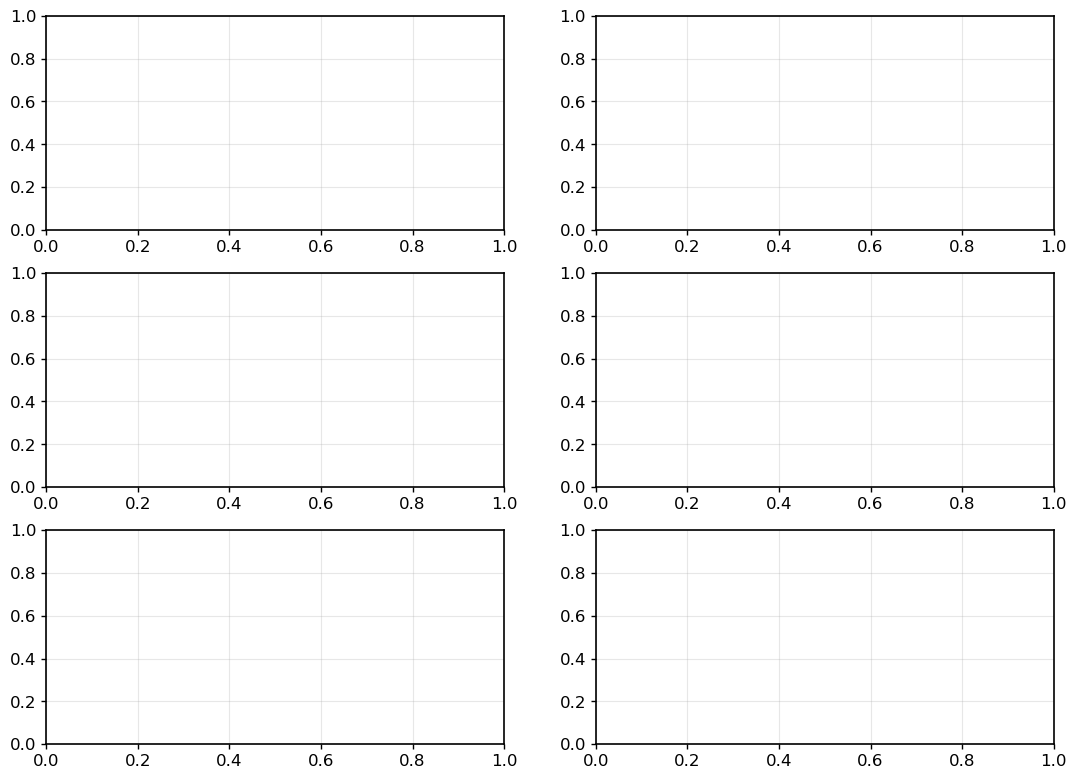

In [24]:
try:
    # §7j.2 Direct solution-vector comparison — amplitude histograms, rank plot, raw vector
    #
    # Saves fig5e (hist + rank) and fig5f (raw vector, classical-ranked).

    import pickle, numpy as np, matplotlib.pyplot as plt
    from pathlib import Path

    PIK_SV = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/pickles')
    PIK_SM = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_sampling/pickles')
    OUT    = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector')

    c14_C, c14_Qsv, c14_Qsm = '#1f77b4', '#d62728', '#ff7f0e'
    T_LIST = [10, 50, 200, 1000]; REP = 0

    def _load(pdir, T, rep):
        p = pdir/f'event_n{T:04d}_rep{rep:03d}.pkl'
        return p if p.exists() else None

    def _norm(v):
        v = np.asarray(v, float); m = v.max()
        return v/m if m>0 else v

    # ---- fig5e: histogram + rank ----
    fig, axes = plt.subplots(len(T_LIST), 2, figsize=(13, 3.2*len(T_LIST)))
    if axes.ndim == 1: axes = axes[None,:]
    for i, T in enumerate(T_LIST):
        d1 = _load(PIK_SV, T, REP); d2 = _load(PIK_SM, T, REP)
        if d1 is None or d2 is None:
            for ax in axes[i]: ax.set_visible(False); continue
        sC = np.asarray(d1['sol_C']).ravel()
        sQsv = np.asarray(d1['sol_Q_scaled']).ravel()
        sQsm = np.asarray(d2['sol_Q_scaled']).ravel()
        n_true = int(d1['seg_C']['n_true_all'])
        n_seg  = sC.size
        nC, nSV, nSM = _norm(sC), _norm(sQsv), _norm(sQsm)
        ax = axes[i,0]
        bins = np.linspace(0,1,81)
        ax.hist(nC,  bins=bins, histtype='step', color=c14_C,   lw=1.5, label='Classical')
        ax.hist(nSV, bins=bins, histtype='step', color=c14_Qsv, lw=1.5, label='Quantum E1 (sv)')
        ax.hist(nSM, bins=bins, histtype='step', color=c14_Qsm, lw=1.5, label='Quantum E2 (sm)')
        ax.set_yscale('log')
        ax.set_xlabel(r'amplitude / amplitude$_{\max}$')
        ax.set_ylabel('segments')
        ax.set_title(f'T={T} | n_seg={n_seg:,} n_true={n_true} — amplitude histogram')
        ax.grid(True, which='both', ls=':', alpha=0.4)
        if i==0: ax.legend(loc='upper right', fontsize=9)
        ax = axes[i,1]
        rk = np.arange(1, n_seg+1); floor = 1e-12
        ax.plot(rk, np.clip(np.sort(nC)[::-1],  floor, None), color=c14_C,   lw=1.4, label='Classical')
        ax.plot(rk, np.clip(np.sort(nSV)[::-1], floor, None), color=c14_Qsv, lw=1.4, label='Quantum E1 (sv)')
        ax.plot(rk, np.clip(np.sort(nSM)[::-1], floor, None), color=c14_Qsm, lw=1.4, label='Quantum E2 (sm)')
        ax.axvline(n_true, color='k', ls='--', lw=1, alpha=0.7, label=f'rank=n_true ({n_true})')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel('rank (1 = largest amplitude)')
        ax.set_ylabel(r'amplitude / amplitude$_{\max}$')
        ax.set_title(f'T={T} — sorted amplitudes (rank plot)')
        ax.grid(True, which='both', ls=':', alpha=0.4)
        if i==0: ax.legend(loc='lower left', fontsize=9)
    fig.suptitle('Fig 5e — solution-vector comparison (rep=0)', fontsize=13, y=1.0)
    fig.tight_layout()
    fig.savefig(OUT/'fig5e_solvec_compare_hist_rank.pdf', bbox_inches='tight')
    fig.savefig(OUT/'fig5e_solvec_compare_hist_rank.png', bbox_inches='tight', dpi=160)
    plt.show()

    # ---- fig5f: raw vector, classical-ranked ----
    fig, axes = plt.subplots(len(T_LIST), 1, figsize=(13, 3.0*len(T_LIST)))
    if not isinstance(axes, np.ndarray): axes = np.array([axes])
    for i, T in enumerate(T_LIST):
        d1 = _load(PIK_SV, T, REP); d2 = _load(PIK_SM, T, REP)
        if d1 is None or d2 is None: axes[i].set_visible(False); continue
        sC = np.asarray(d1['sol_C']).ravel()
        sQsv = np.asarray(d1['sol_Q_scaled']).ravel()
        sQsm = np.asarray(d2['sol_Q_scaled']).ravel()
        n_true = int(d1['seg_C']['n_true_all']); n_seg = sC.size
        order = np.argsort(-sC)
        nC, nSV, nSM = _norm(sC)[order], _norm(sQsv)[order], _norm(sQsm)[order]
        K = min(n_seg, 1000 if T>=200 else n_seg); xs = np.arange(K)
        ax = axes[i]
        ax.plot(xs, nC[:K],  '-', color=c14_C,   lw=1.0, alpha=0.95, label='Classical')
        ax.plot(xs, nSV[:K], '-', color=c14_Qsv, lw=1.0, alpha=0.85, label='Quantum E1 (sv)')
        ax.plot(xs, nSM[:K], '-', color=c14_Qsm, lw=1.0, alpha=0.85, label='Quantum E2 (sm)')
        if n_true <= K:
            ax.axvline(n_true-0.5, color='k', ls='--', lw=1, alpha=0.7,
                       label=f'truth boundary (n_true={n_true})')
        ax.set_xlabel(f'segment index (classical-ranked; first {n_true} are TRUE)')
        ax.set_ylabel(r'amplitude / amplitude$_{\max}$')
        ax.set_title(f'T={T} | n_seg={n_seg:,} ' + (f'(top {K} shown)' if K<n_seg else '(full vector)'))
        ax.set_ylim(-0.02, 1.05); ax.grid(True, which='both', ls=':', alpha=0.4)
        if i==0: ax.legend(loc='upper right', fontsize=9, ncol=2)
    fig.suptitle('Fig 5f — raw solution vectors (rep=0, classical-ranked)', fontsize=13, y=1.0)
    fig.tight_layout()
    fig.savefig(OUT/'fig5f_solvec_compare_raw.pdf', bbox_inches='tight')
    fig.savefig(OUT/'fig5f_solvec_compare_raw.png', bbox_inches='tight', dpi=160)
    plt.show()
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

In [25]:
try:
    # §7j.3 Fig 5d v2 — segment metrics at each solver's native threshold (from seg_C, seg_Q).
    #
    # Reads the seg_C / seg_Q dicts already stored in the pickles (evaluated against
    # ground-truth labels) and aggregates per-T.

    import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
    from pathlib import Path

    PIK_SV = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/pickles')
    PIK_SM = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_sampling/pickles')
    OUT    = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector')
    c14_C, c14_Qsv, c14_Qsm = '#1f77b4', '#d62728', '#ff7f0e'
    c14_true, c14_false     = '#2ca02c', '#9467bd'

    def _load_segs(pdir):
        rows = []
        for p in iter_solutions(pdir):
            try: r = p
            except Exception: continue
            sc, sq = r['seg_C'], r['seg_Q']
            rows.append(dict(n_trk=int(r['n_trk']), rep=int(r['rep']),
                n_true_all=int(sc['n_true_all']),
                n_true_clean=int(sc.get('n_true_clean', sc['n_true_all'])),
                n_false_all=int(sc['n_false_all']),
                n_act_C=int(sc['n_active']),  n_tact_C=int(sc['n_true_active']),
                n_fact_C=int(sc['n_false_active']),
                n_act_Q=int(sq['n_active']),  n_tact_Q=int(sq['n_true_active']),
                n_fact_Q=int(sq['n_false_active'])))
        df = pd.DataFrame(rows)
        df['eff_C']=df['n_tact_C']/df['n_true_clean'].clip(lower=1)
        df['fr_C'] =df['n_fact_C']/df['n_act_C'].clip(lower=1)
        df['eff_Q']=df['n_tact_Q']/df['n_true_clean'].clip(lower=1)
        df['fr_Q'] =df['n_fact_Q']/df['n_act_Q'].clip(lower=1)
        return df

    ds_sv, ds_sm = _load_segs(PIK_SV), _load_segs(PIK_SM)
    sem = lambda x: (x.std(ddof=1)/np.sqrt(len(x))) if len(x)>1 else 0.0
    def _agg(df):
        return (df.groupby('n_trk').agg(
            eff_C=('eff_C','mean'), eff_C_sem=('eff_C',sem),
            fr_C=('fr_C','mean'),   fr_C_sem=('fr_C',sem),
            eff_Q=('eff_Q','mean'), eff_Q_sem=('eff_Q',sem),
            fr_Q=('fr_Q','mean'),   fr_Q_sem=('fr_Q',sem),
            n_true_all=('n_true_all','mean'),   n_true_all_sem=('n_true_all',sem),
            n_false_all=('n_false_all','mean'), n_false_all_sem=('n_false_all',sem),
            n_tact_C=('n_tact_C','mean'),       n_tact_C_sem=('n_tact_C',sem),
            n_fact_C=('n_fact_C','mean'),       n_fact_C_sem=('n_fact_C',sem),
            n_tact_Q=('n_tact_Q','mean'),       n_tact_Q_sem=('n_tact_Q',sem),
            n_fact_Q=('n_fact_Q','mean'),       n_fact_Q_sem=('n_fact_Q',sem),
            n_reps=('rep','count')).reset_index().sort_values('n_trk'))
    g_sv = _agg(ds_sv); g_sm = _agg(ds_sm) if len(ds_sm) else g_sv.iloc[0:0]
    g_sv.to_csv(OUT/'sec7j_native_E1.csv', index=False)
    g_sm.to_csv(OUT/'sec7j_native_E2.csv', index=False)

    def _style(ax):
        ax.set_xscale('log'); ax.grid(True, which='both', ls=':', alpha=0.5)
        ax.set_xlabel('Number of tracks per event')
        ax.tick_params(direction='in', top=True, right=True)
    def _logclip(y,e,floor=1e-4):
        y = np.asarray(y,float); e = np.asarray(e,float)
        yp = np.clip(y, floor, None); ep = np.minimum(e, yp - floor*1.01)
        return yp, np.vstack([np.maximum(ep,0), e])
    def _eb_act(ax,x,y,e,fmt,color,label,mfc=None):
        yp,eb = _logclip(y,e)
        ax.errorbar(x, yp, yerr=eb, fmt=fmt, color=color,
                    mfc=(mfc if mfc is not None else color),
                    ms=6, capsize=3, lw=1.2, label=label)

    fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.0))
    ax = axes[0,0]
    ax.errorbar(g_sv['n_trk'], 100*g_sv['eff_C'], yerr=100*g_sv['eff_C_sem'], fmt='o-',
                color=c14_C, ms=6, capsize=3, lw=1.4, label='Classical (E1)')
    ax.errorbar(g_sv['n_trk'], 100*g_sv['eff_Q'], yerr=100*g_sv['eff_Q_sem'], fmt='s--',
                color=c14_Qsv, ms=6, capsize=3, lw=1.4, label='Quantum E1 (sv)')
    ax.errorbar(g_sm['n_trk'], 100*g_sm['eff_Q'], yerr=100*g_sm['eff_Q_sem'], fmt='^:',
                color=c14_Qsm, ms=6, capsize=3, lw=1.4, label='Quantum E2 (sm)')
    ax.set_title('i) Segment Efficiency at native threshold')
    ax.set_ylabel('Segment efficiency [%]'); ax.set_ylim(0,105); _style(ax)
    ax.legend(loc='lower left', fontsize=9)

    ax = axes[0,1]
    ax.errorbar(g_sv['n_trk'], 100*g_sv['fr_C'], yerr=100*g_sv['fr_C_sem'], fmt='o-',
                color=c14_C, ms=6, capsize=3, lw=1.4, label='Classical (E1)')
    ax.errorbar(g_sv['n_trk'], 100*g_sv['fr_Q'], yerr=100*g_sv['fr_Q_sem'], fmt='s--',
                color=c14_Qsv, ms=6, capsize=3, lw=1.4, label='Quantum E1 (sv)')
    ax.errorbar(g_sm['n_trk'], 100*g_sm['fr_Q'], yerr=100*g_sm['fr_Q_sem'], fmt='^:',
                color=c14_Qsm, ms=6, capsize=3, lw=1.4, label='Quantum E2 (sm)')
    ax.set_title('ii) Segment False Rate at native threshold')
    ax.set_ylabel('Segment false rate [%]'); ax.set_ylim(0,100); _style(ax)
    ax.legend(loc='upper left', fontsize=9)

    ax = axes[1,0]
    _eb_act(ax, g_sv['n_trk'], g_sv['n_true_all'],  g_sv['n_true_all_sem'],  'o-', c14_true,  'True segments')
    _eb_act(ax, g_sv['n_trk'], g_sv['n_false_all'], g_sv['n_false_all_sem'], 's-', c14_false, 'False segments')
    ax.set_yscale('log'); ax.set_title('iii) Segment Pair Counts (truth)')
    ax.set_ylabel('Number of segment pairs'); _style(ax); ax.legend(loc='upper left', fontsize=9)

    ax = axes[1,1]
    _eb_act(ax, g_sv['n_trk'], g_sv['n_tact_C'], g_sv['n_tact_C_sem'], 'o-',  c14_C,   'Classical true active')
    _eb_act(ax, g_sv['n_trk'], g_sv['n_fact_C'], g_sv['n_fact_C_sem'], 'o--', c14_C,   'Classical false active', mfc='white')
    _eb_act(ax, g_sv['n_trk'], g_sv['n_tact_Q'], g_sv['n_tact_Q_sem'], 's-',  c14_Qsv, 'Quantum E1 true active')
    _eb_act(ax, g_sv['n_trk'], g_sv['n_fact_Q'], g_sv['n_fact_Q_sem'], 's--', c14_Qsv, 'Quantum E1 false active', mfc='white')
    _eb_act(ax, g_sm['n_trk'], g_sm['n_tact_Q'], g_sm['n_tact_Q_sem'], '^-',  c14_Qsm, 'Quantum E2 true active')
    _eb_act(ax, g_sm['n_trk'], g_sm['n_fact_Q'], g_sm['n_fact_Q_sem'], '^--', c14_Qsm, 'Quantum E2 false active', mfc='white')
    ax.set_yscale('log'); ax.set_title('iv) Active Segment Pairs at native threshold')
    ax.set_ylabel('Active segment pairs'); _style(ax); ax.legend(loc='upper left', fontsize=8, ncol=2)

    fig.suptitle('Fig 5d (v2) — §14e segment metrics at NATIVE solver thresholds (from seg_C, seg_Q)',
                 fontsize=12, y=0.995)
    fig.tight_layout()
    fig.savefig(OUT/'fig5d_seg14e_mirror_quantum_at_native.pdf', bbox_inches='tight')
    fig.savefig(OUT/'fig5d_seg14e_mirror_quantum_at_native.png', bbox_inches='tight', dpi=160)
    plt.show()

    print('\nFig 5d v2 — per-T table (E1):')
    print(g_sv[['n_trk','eff_C','fr_C','eff_Q','fr_Q','n_reps']]
          .assign(eff_C_pct=lambda d:100*d['eff_C'], fr_C_pct=lambda d:100*d['fr_C'],
                  eff_Q_pct=lambda d:100*d['eff_Q'], fr_Q_pct=lambda d:100*d['fr_Q'])
          [['n_trk','eff_C_pct','fr_C_pct','eff_Q_pct','fr_Q_pct','n_reps']]
          .to_string(index=False, float_format='%.3f'))
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on: KeyError 'n_tact_C'


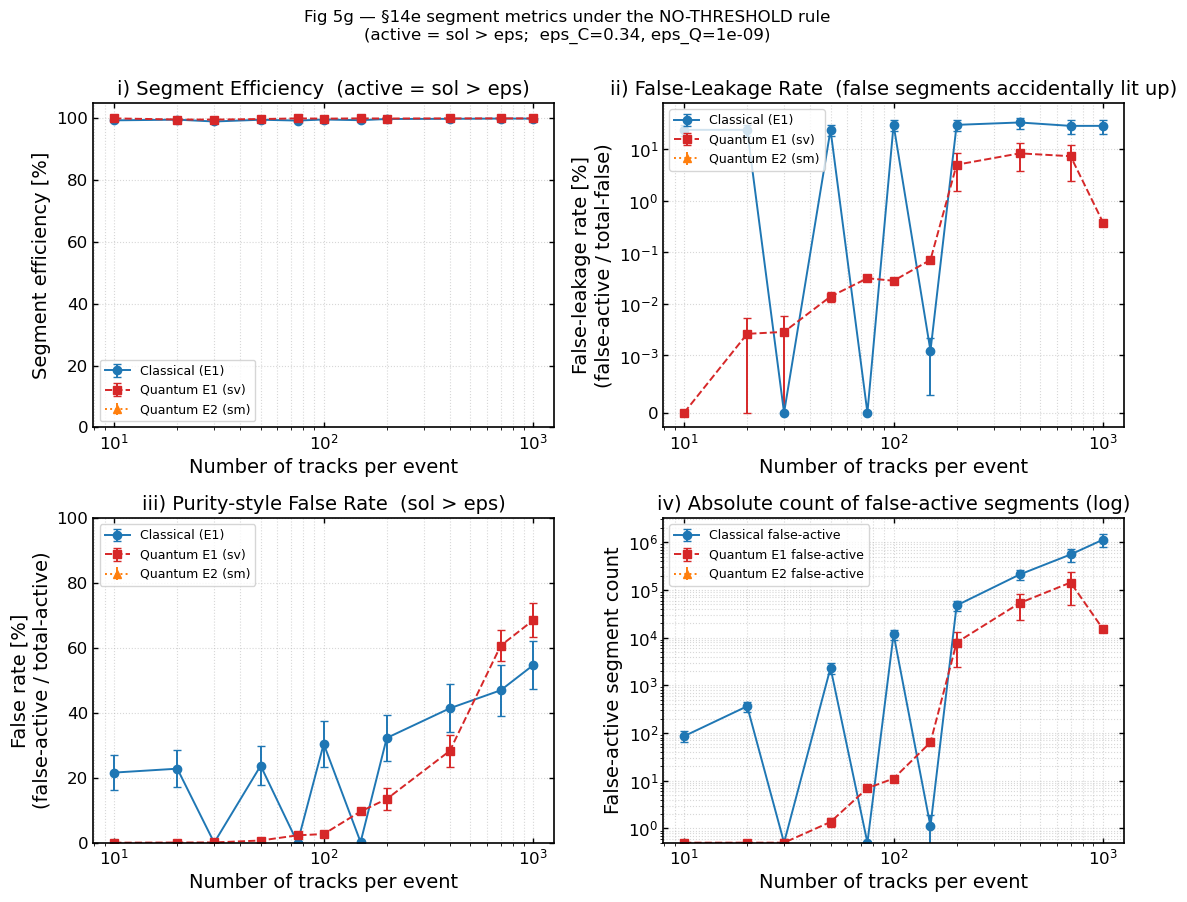


Fig 5g — per-T no-threshold metrics (E1, percentages):
   T  eff_C%   eff_Q%  flr_C%  flr_Q%   fr_C%   fr_Q%     #false_C    #false_Q  n_reps
  10 99.3684 100.0000 24.0000  0.0000 21.6000  0.0000      85.6800      0.0000      50
  20 99.5884  99.6404 24.0000  0.0026 22.8000  0.0488     363.2800      0.0400      50
  30 98.9976  99.6117  0.0000  0.0029  0.0000  0.0820       0.0000      0.1000      20
  50 99.5645  99.7914 24.0041  0.0139 23.7159  0.6665    2319.4000      1.3600      50
  75 99.2987 100.0000  0.0000  0.0316  0.0000  2.2692       0.0000      6.9500      20
 100 99.6340  99.9231 30.0078  0.0282 30.4335  2.6580   11740.4000     11.0750      40
 150 99.4194 100.0000  0.0012  0.0717  0.1813  9.6203       1.1000     63.5000      10
 200 99.8048  99.9620 30.0004  5.0500 32.2729 13.4565   47315.0000   7890.2500      40
 400 99.8596 100.0000 33.3678  8.3972 41.4073 28.2969  210659.4167  53142.5278      36
 700 99.9400 100.0000 28.6451  7.3877 46.9660 60.7136  554046.6429 142997.

In [26]:
try:
    # §7j.4 Fig 5g — no-threshold metric: active ⇔ sol > eps, with false-leakage rate.
    #
    # Defines:
    #   eff = n_tact / n_true_all
    #   flr = n_fact / n_false_all     (false-LEAKAGE rate; the "right" quantum metric)
    #   fr  = n_fact / n_active        (purity-style false rate, same as before)

    import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
    from pathlib import Path

    PIK_SV = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/pickles')
    PIK_SM = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_sampling/pickles')
    OUT    = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector')
    c14_C, c14_Qsv, c14_Qsm = '#1f77b4', '#d62728', '#ff7f0e'

    EPS_Q = 1e-9   # numerical noise floor for quantum (sol_Q_scaled FALSE all <1e-13 at low T)
    EPS_C = 0.34   # strictly between matrix floor (0.25, 0.33) and smallest TRUE (>= 0.36)

    def _per_event(d):
        sC = np.asarray(d['sol_C']).ravel(); sQ = np.asarray(d['sol_Q_scaled']).ravel()
        n_true  = int(d['seg_C']['n_true_all'])
        n_false = int(d['seg_C']['n_false_all'])
        n_true_c = int(d['seg_C'].get('n_true_clean', n_true))
        order = np.argsort(-sC); truth = np.zeros(sC.size, bool); truth[order[:n_true]] = True
        out = dict(n_trk=int(d['n_trk']), rep=int(d['rep']),
                   n_true_all=n_true, n_false_all=n_false, n_true_clean=n_true_c)
        for nm, sol, eps in [('C', sC, EPS_C), ('Q', sQ, EPS_Q)]:
            act = sol > eps
            n_act = int(act.sum()); n_tact = int((act & truth).sum())
            n_fact = n_act - n_tact
            out[f'n_act_{nm}']=n_act; out[f'n_tact_{nm}']=n_tact; out[f'n_fact_{nm}']=n_fact
            out[f'eff_{nm}']=n_tact/max(n_true_c,1)
            out[f'flr_{nm}']=n_fact/max(n_false,1)
            out[f'fr_{nm}'] =n_fact/max(n_act,1)
        return out

    def _load(pdir):
        rows = []
        for p in iter_solutions(pdir):
            try: rows.append(_per_event(p))
            except Exception: continue
        return pd.DataFrame(rows)

    df_sv = _load(PIK_SV); df_sm = _load(PIK_SM) if len(_load(PIK_SM)) else df_sv.iloc[0:0]
    sem = lambda x: (x.std(ddof=1)/np.sqrt(len(x))) if len(x)>1 else 0.0
    keep = ['eff_C','flr_C','fr_C','eff_Q','flr_Q','fr_Q',
            'n_act_C','n_tact_C','n_fact_C','n_act_Q','n_tact_Q','n_fact_Q',
            'n_true_all','n_false_all']
    def _agg(df):
        return df.groupby('n_trk').agg(**{f'{k}_mean':(k,'mean') for k in keep},
                                        **{f'{k}_sem' :(k,sem)   for k in keep},
                                        n_reps=('rep','count')).reset_index().sort_values('n_trk')
    g_sv, g_sm = _agg(df_sv), _agg(df_sm)
    g_sv.to_csv(OUT/'sec7j_nothresh_E1.csv', index=False)
    g_sm.to_csv(OUT/'sec7j_nothresh_E2.csv', index=False)

    def _style(ax):
        ax.set_xscale('log'); ax.grid(True, which='both', ls=':', alpha=0.5)
        ax.set_xlabel('Number of tracks per event')
        ax.tick_params(direction='in', top=True, right=True)
    def _plot(ax, g, name, color, fmt, label):
        y = 100*g[f'{name}_mean']; e = 100*g[f'{name}_sem']
        ax.errorbar(g['n_trk'], y, yerr=e, fmt=fmt, color=color, ms=6, capsize=3, lw=1.4, label=label)

    fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.0))

    ax = axes[0,0]
    _plot(ax, g_sv, 'eff_C', c14_C,   'o-',  'Classical (E1)')
    _plot(ax, g_sv, 'eff_Q', c14_Qsv, 's--', 'Quantum E1 (sv)')
    _plot(ax, g_sm, 'eff_Q', c14_Qsm, '^:',  'Quantum E2 (sm)')
    ax.set_ylabel('Segment efficiency [%]'); ax.set_ylim(0,105)
    ax.set_title('i) Segment Efficiency  (active = sol > eps)')
    _style(ax); ax.legend(loc='lower left', fontsize=9)

    ax = axes[0,1]
    _plot(ax, g_sv, 'flr_C', c14_C,   'o-',  'Classical (E1)')
    _plot(ax, g_sv, 'flr_Q', c14_Qsv, 's--', 'Quantum E1 (sv)')
    _plot(ax, g_sm, 'flr_Q', c14_Qsm, '^:',  'Quantum E2 (sm)')
    ax.set_yscale('symlog', linthresh=1e-3)
    ax.set_ylabel('False-leakage rate [%]\n(false-active / total-false)')
    ax.set_title('ii) False-Leakage Rate  (false segments accidentally lit up)')
    _style(ax); ax.legend(loc='upper left', fontsize=9)

    ax = axes[1,0]
    _plot(ax, g_sv, 'fr_C', c14_C,   'o-',  'Classical (E1)')
    _plot(ax, g_sv, 'fr_Q', c14_Qsv, 's--', 'Quantum E1 (sv)')
    _plot(ax, g_sm, 'fr_Q', c14_Qsm, '^:',  'Quantum E2 (sm)')
    ax.set_ylabel('False rate [%]\n(false-active / total-active)'); ax.set_ylim(0,100)
    ax.set_title('iii) Purity-style False Rate  (sol > eps)')
    _style(ax); ax.legend(loc='upper left', fontsize=9)

    ax = axes[1,1]
    def _abs(ax, g, key, color, fmt, label):
        y = g[f'{key}_mean']; e = g[f'{key}_sem']
        yp = np.clip(y, 0.5, None)
        ax.errorbar(g['n_trk'], yp, yerr=e, fmt=fmt, color=color, ms=6, capsize=3, lw=1.4, label=label)
    _abs(ax, g_sv, 'n_fact_C', c14_C,   'o-',  'Classical false-active')
    _abs(ax, g_sv, 'n_fact_Q', c14_Qsv, 's--', 'Quantum E1 false-active')
    _abs(ax, g_sm, 'n_fact_Q', c14_Qsm, '^:',  'Quantum E2 false-active')
    ax.set_yscale('log'); ax.set_ylim(0.5, None)
    ax.set_ylabel('False-active segment count')
    ax.set_title('iv) Absolute count of false-active segments (log)')
    _style(ax); ax.legend(loc='upper left', fontsize=9)

    fig.suptitle('Fig 5g — §14e segment metrics under the NO-THRESHOLD rule\n'
                 f'(active = sol > eps;  eps_C={EPS_C}, eps_Q={EPS_Q:g})', fontsize=12, y=1.0)
    fig.tight_layout()
    fig.savefig(OUT/'fig5g_seg14e_nothresh.pdf', bbox_inches='tight')
    fig.savefig(OUT/'fig5g_seg14e_nothresh.png', bbox_inches='tight', dpi=160)
    plt.show()

    # Show summary table for E1
    print('\nFig 5g — per-T no-threshold metrics (E1, percentages):')
    tbl = g_sv[['n_trk','eff_C_mean','eff_Q_mean','flr_C_mean','flr_Q_mean',
                'fr_C_mean','fr_Q_mean','n_fact_C_mean','n_fact_Q_mean','n_reps']].copy()
    for c in tbl.columns:
        if c.startswith(('eff','flr','fr_')): tbl[c] = 100*tbl[c]
    tbl.columns = ['T','eff_C%','eff_Q%','flr_C%','flr_Q%','fr_C%','fr_Q%',
                   '#false_C','#false_Q','n_reps']
    print(tbl.to_string(index=False, float_format='%.4f'))
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

## §7k Full segment-level metrics — §14e-style 2×2 under the no-threshold rule

Faithful reproduction of the `segment_level_analysis.ipynb` §14e panel layout
(`fig14_solver_segment_efficiency_drop1pct`) but with:

- **Three solvers overlaid**: classical Cholesky, quantum 1-bit HHL E1
  (statevector readout), quantum 1-bit HHL E2 (sampling readout).
- **The no-threshold rule** from §7j: a segment is *active* iff
  `sol > eps`, with `eps_C = 0.34` (between matrix floor 0.25 and smallest
  true geometric class 0.36) and `eps_Q = 1e-9` (numerical zero).

Panels (matching §14e):
- **i)** Segment Efficiency = $N_\text{true,act} / N_\text{true,all}$, linear-x
- **ii)** Segment False Rate = $N_\text{false,act} / N_\text{accepted}$, linear-x
- **iii)** Segment Pair Counts (true vs false truth, solver-independent), log-x, log-y
- **iv)** Active Segment Pairs (true-active vs false-active per solver), log-x, log-y


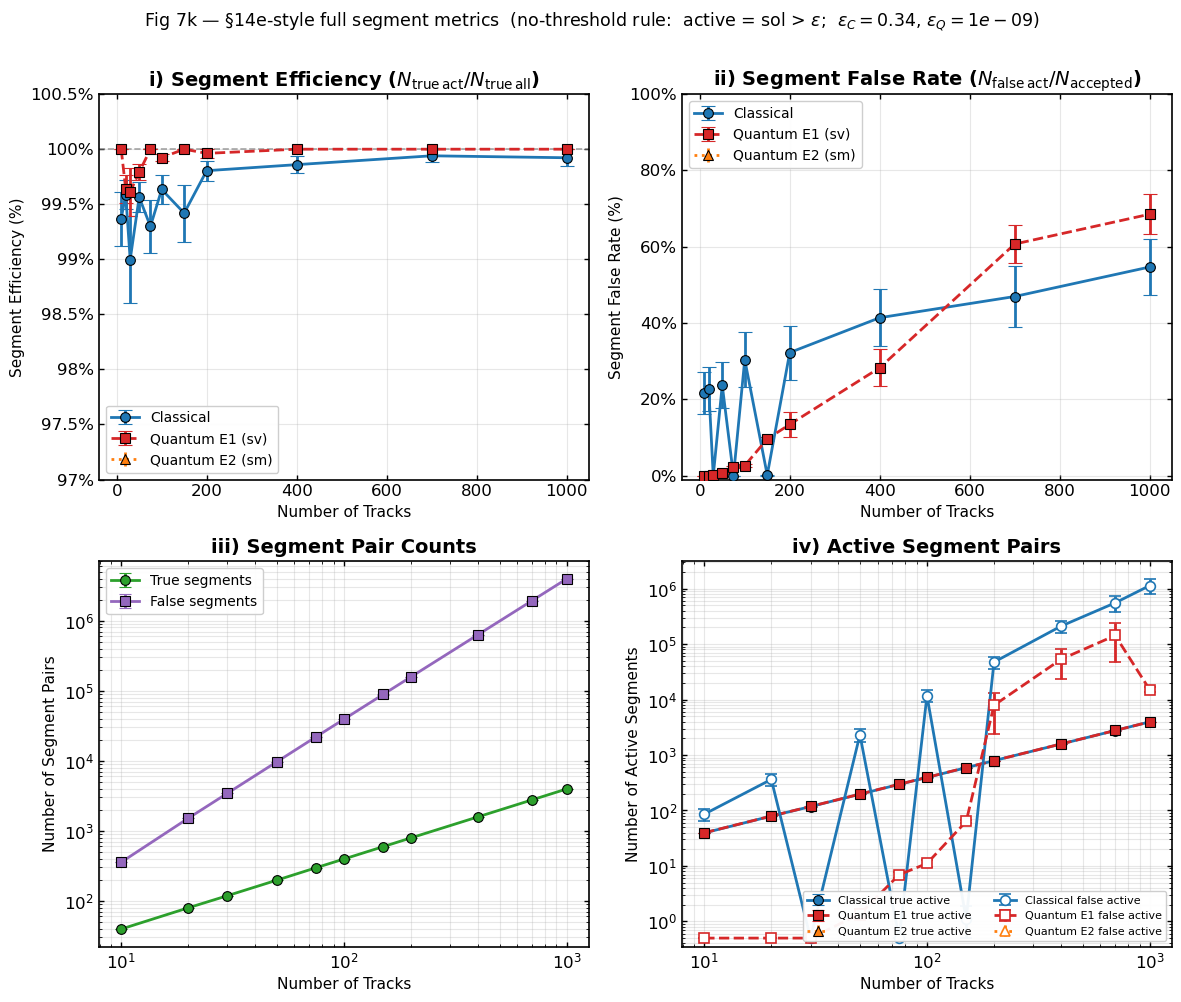

Saved fig7k_seg14e_full_segmetrics_nothresh.{pdf,png}

=== §7k E1 (statevector): full segment metrics under no-threshold rule ===
 n_trk  eff_C_m  eff_Q_m  fr_C_m  fr_Q_m  n_tact_C_m  n_fact_C_m  n_tact_Q_m  n_fact_Q_m  n_reps
    10   99.368  100.000  21.600   0.000      39.320      85.680      39.560       0.000      50
    20   99.588   99.640  22.800   0.049      79.220     363.280      79.260       0.040      50
    30   98.998   99.612   0.000   0.082     117.450       0.000     118.150       0.100      20
    50   99.564   99.791  23.716   0.666     196.640    2319.400     197.080       1.360      50
    75   99.299  100.000   0.000   2.269     295.200       0.000     297.250       6.950      20
   100   99.634   99.923  30.433   2.658     394.075   11740.400     395.200      11.075      40
   150   99.419  100.000   0.181   9.620     590.300       1.100     593.700      63.500      10
   200   99.805   99.962  32.273  13.457     790.850   47315.000     792.075    7890.250      

In [27]:
try:
    # §7k Fig 14e-mirror — full segment-level metrics, no-threshold, 3-solver overlay.
    import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
    import matplotlib.ticker as _mt14k
    from pathlib import Path

    PIK_SV = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/pickles')
    PIK_SM = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_sampling/pickles')
    OUT    = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector')

    # --- §14e palette (same hues as the reference notebook) ---
    _c14_C     = '#1f77b4'   # classical (matches reference _c14_drop blue family)
    _c14_Qsv   = '#d62728'   # quantum E1 statevector (red)
    _c14_Qsm   = '#ff7f0e'   # quantum E2 sampling   (orange)
    _c14_true  = '#2ca02c'
    _c14_false = '#9467bd'

    EPS_C, EPS_Q = 0.34, 1e-9

    def _per_event(d):
        sC = np.asarray(d['sol_C']).ravel()
        sQ = np.asarray(d['sol_Q_scaled']).ravel()
        n_true  = int(d['seg_C']['n_true_all'])
        n_false = int(d['seg_C']['n_false_all'])
        n_true_c = int(d['seg_C'].get('n_true_clean', n_true))
        order = np.argsort(-sC); truth = np.zeros(sC.size, bool); truth[order[:n_true]] = True
        out = dict(n_trk=int(d['n_trk']), rep=int(d['rep']),
                   n_true_all=n_true, n_false_all=n_false, n_true_clean=n_true_c)
        for nm, sol, eps in [('C', sC, EPS_C), ('Q', sQ, EPS_Q)]:
            act = sol > eps
            n_act = int(act.sum()); n_tact = int((act & truth).sum())
            n_fact = n_act - n_tact
            out[f'n_act_{nm}']  = n_act
            out[f'n_tact_{nm}'] = n_tact
            out[f'n_fact_{nm}'] = n_fact
            out[f'eff_{nm}'] = 100.0 * n_tact / max(n_true_c, 1)
            out[f'fr_{nm}']  = 100.0 * n_fact / max(n_act, 1)
        return out

    def _load(pdir):
        rows = []
        for p in iter_solutions(pdir):
            try: rows.append(_per_event(p))
            except Exception: continue
        return pd.DataFrame(rows)

    df_sv = _load(PIK_SV); df_sm = _load(PIK_SM) if len(_load(PIK_SM)) else df_sv.iloc[0:0]
    sem = lambda x: (x.std(ddof=1)/np.sqrt(len(x))) if len(x)>1 else 0.0
    KEEP = ['eff_C','fr_C','eff_Q','fr_Q',
            'n_act_C','n_tact_C','n_fact_C',
            'n_act_Q','n_tact_Q','n_fact_Q',
            'n_true_all','n_false_all']
    def _agg(df):
        return (df.groupby('n_trk').agg(**{f'{k}_m':(k,'mean') for k in KEEP},
                                         **{f'{k}_e':(k,sem)   for k in KEEP},
                                         n_reps=('rep','count'))
                  .reset_index().sort_values('n_trk'))
    g_sv, g_sm = _agg(df_sv), _agg(df_sm)
    g_sv.to_csv(OUT/'sec7k_full_segmetrics_E1.csv', index=False)
    g_sm.to_csv(OUT/'sec7k_full_segmetrics_E2.csv', index=False)

    # ---------------- §14e-style helper ----------------
    def _logclip_yerr(y, e, floor):
        y = np.asarray(y, float); e = np.asarray(e, float)
        lo = np.minimum(e, np.maximum(y - floor, 0.0))
        return np.vstack([lo, e])

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    tc_sv = g_sv['n_trk'].to_numpy(float)
    tc_sm = g_sm['n_trk'].to_numpy(float)

    # ---- i) Segment Efficiency (linear x) ----
    ax = axes[0, 0]
    ax.errorbar(tc_sv, g_sv['eff_C_m'], yerr=g_sv['eff_C_e'], fmt='o-',  color=_c14_C,
                capsize=5, capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
                zorder=3, label='Classical')
    ax.errorbar(tc_sv, g_sv['eff_Q_m'], yerr=g_sv['eff_Q_e'], fmt='s--', color=_c14_Qsv,
                capsize=5, capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
                zorder=3, label='Quantum E1 (sv)')
    ax.errorbar(tc_sm, g_sm['eff_Q_m'], yerr=g_sm['eff_Q_e'], fmt='^:',  color=_c14_Qsm,
                capsize=5, capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
                zorder=3, label='Quantum E2 (sm)')
    ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, zorder=2)
    _low = np.concatenate([g_sv['eff_C_m'] - g_sv['eff_C_e'],
                           g_sv['eff_Q_m'] - g_sv['eff_Q_e'],
                           g_sm['eff_Q_m'] - g_sm['eff_Q_e']])
    _emin = max(0, np.floor(np.nanmin(_low)) - 1)
    ax.set_ylim(_emin, 100.5)
    ax.set_ylabel('Segment Efficiency (%)', fontsize=11)
    ax.set_title(r'i) Segment Efficiency ($N_{\mathrm{true\,act}} / N_{\mathrm{true\,all}}$)',
                 fontweight='bold')
    ax.grid(True, alpha=0.3, zorder=1)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(_mt14k.FormatStrFormatter('%g%%'))
    ax.legend(loc='lower left', framealpha=0.95, fontsize=10)

    # ---- ii) Segment False Rate (linear x) ----
    ax = axes[0, 1]
    ax.errorbar(tc_sv, g_sv['fr_C_m'], yerr=g_sv['fr_C_e'], fmt='o-',  color=_c14_C,
                capsize=5, capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
                zorder=3, label='Classical')
    ax.errorbar(tc_sv, g_sv['fr_Q_m'], yerr=g_sv['fr_Q_e'], fmt='s--', color=_c14_Qsv,
                capsize=5, capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
                zorder=3, label='Quantum E1 (sv)')
    ax.errorbar(tc_sm, g_sm['fr_Q_m'], yerr=g_sm['fr_Q_e'], fmt='^:',  color=_c14_Qsm,
                capsize=5, capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
                zorder=3, label='Quantum E2 (sm)')
    ax.set_ylim(-1, 100)
    ax.set_ylabel('Segment False Rate (%)', fontsize=11)
    ax.set_title(r'ii) Segment False Rate ($N_{\mathrm{false\,act}} / N_{\mathrm{accepted}}$)',
                 fontweight='bold')
    ax.grid(True, alpha=0.3, zorder=1)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(_mt14k.FormatStrFormatter('%g%%'))
    ax.legend(loc='upper left', framealpha=0.95, fontsize=10)

    # ---- iii) Segment Pair Counts (truth, solver-independent), log x, log y ----
    _FLOOR3 = 0.5
    ax = axes[1, 0]
    ax.errorbar(tc_sv, g_sv['n_true_all_m'],
                yerr=_logclip_yerr(g_sv['n_true_all_m'], g_sv['n_true_all_e'], _FLOOR3),
                fmt='o-', color=_c14_true,
                capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
                label='True segments', zorder=3)
    ax.errorbar(tc_sv, g_sv['n_false_all_m'],
                yerr=_logclip_yerr(g_sv['n_false_all_m'], g_sv['n_false_all_e'], _FLOOR3),
                fmt='s-', color=_c14_false,
                capsize=4, capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
                label='False segments', zorder=3)
    ax.set_yscale('log')
    ax.set_ylabel('Number of Segment Pairs', fontsize=11)
    ax.set_title('iii) Segment Pair Counts', fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.95, fontsize=10)
    ax.grid(True, alpha=0.3, which='both', zorder=1)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

    # ---- iv) Active Segment Pairs (per solver), log x, log y ----
    _FLOOR4 = 0.5
    ax = axes[1, 1]
    def _eb_act(x, ym, ye, fmt, color, label, marker_edge=True):
        yp = np.maximum(ym, _FLOOR4)
        ye_adj = np.where(ym >= _FLOOR4, ye, 0.0)
        ax.errorbar(x, yp, yerr=_logclip_yerr(yp, ye_adj, _FLOOR4),
                    fmt=fmt, color=color,
                    capsize=4, capthick=1.2,
                    markeredgecolor=('black' if marker_edge else color),
                    markeredgewidth=(0.8 if marker_edge else 0.0),
                    label=label, zorder=3)

    # True-active (filled markers)
    _eb_act(tc_sv, g_sv['n_tact_C_m'], g_sv['n_tact_C_e'], 'o-',  _c14_C,   'Classical true active')
    _eb_act(tc_sv, g_sv['n_tact_Q_m'], g_sv['n_tact_Q_e'], 's--', _c14_Qsv, 'Quantum E1 true active')
    _eb_act(tc_sm, g_sm['n_tact_Q_m'], g_sm['n_tact_Q_e'], '^:',  _c14_Qsm, 'Quantum E2 true active')
    # False-active (hollow markers — same colours, dashed)
    def _eb_fa(x, ym, ye, fmt, color, label):
        yp = np.maximum(ym, _FLOOR4)
        ye_adj = np.where(ym >= _FLOOR4, ye, 0.0)
        ax.errorbar(x, yp, yerr=_logclip_yerr(yp, ye_adj, _FLOOR4),
                    fmt=fmt, color=color, mfc='white',
                    capsize=4, capthick=1.2,
                    markeredgecolor=color, markeredgewidth=1.2,
                    label=label, zorder=3)
    _eb_fa(tc_sv, g_sv['n_fact_C_m'], g_sv['n_fact_C_e'], 'o-',  _c14_C,   'Classical false active')
    _eb_fa(tc_sv, g_sv['n_fact_Q_m'], g_sv['n_fact_Q_e'], 's--', _c14_Qsv, 'Quantum E1 false active')
    _eb_fa(tc_sm, g_sm['n_fact_Q_m'], g_sm['n_fact_Q_e'], '^:',  _c14_Qsm, 'Quantum E2 false active')

    ax.set_yscale('log')
    ax.set_ylim(_FLOOR4 * 0.7, None)
    ax.set_ylabel('Number of Active Segments', fontsize=11)
    ax.set_title('iv) Active Segment Pairs', fontweight='bold')
    ax.legend(loc='lower right', framealpha=0.95, fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3, which='both', zorder=1)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

    # Common formatting
    for ax in axes.flat:
        ax.set_xlabel('Number of Tracks', fontsize=11)
    for ax in axes[1, :]:
        ax.set_xscale('log')

    fig.suptitle('Fig 7k — §14e-style full segment metrics  (no-threshold rule:  '
                 rf'active = sol > $\epsilon$;  $\epsilon_C={EPS_C}$, $\epsilon_Q={EPS_Q:g}$)',
                 fontsize=12.5, y=1.0)
    fig.tight_layout()

    _stem = 'fig7k_seg14e_full_segmetrics_nothresh'
    fig.savefig(OUT/f'{_stem}.pdf', format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
    fig.savefig(OUT/f'{_stem}.png',                  dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved {_stem}.{{pdf,png}}')

    # ---------------- Summary tables ----------------
    def _pp(g, tag):
        print(f'\n=== §7k {tag}: full segment metrics under no-threshold rule ===')
        cols = ['n_trk','eff_C_m','eff_Q_m','fr_C_m','fr_Q_m',
                'n_tact_C_m','n_fact_C_m','n_tact_Q_m','n_fact_Q_m','n_reps']
        print(g[cols].to_string(index=False, float_format='%.3f'))
    _pp(g_sv, 'E1 (statevector)')
    _pp(g_sm, 'E2 (sampling)')
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

## §7l Why is the quantum False Rate nonzero?  (false-amplitude diagnostic)

**Claim under test.** If 1-bit HHL is an *exact* projector onto the
true-segment subspace, every false segment should receive amplitude $0$ and
the quantum false rate should be identically zero for all $T$.

**Observation.** It isn't. At $T \geq 50$ a *small but growing* fraction of
false segments acquires nonzero quantum amplitude **already in the E1
statevector readout** — i.e. before any shot noise is added. The mechanism is
not noise, it's the 1-bit kernel itself.

### What the data shows (E1 statevector, no shot noise)

| $T$    | $n_\text{false}$ | $n_\text{false}^\text{leak}$ | leak fraction | leak amplitude levels |
|---:|---:|---:|---:|---|
|  10 |    360 |     0 | 0 % | — |
|  50 |  9 800 |     6 | 0.06 % | 1 level @ 1.28 |
| 100 | 39 008 |    22 | 0.06 % | 1 level @ 1.78 |
| 200 | 157 214 |   153 | 0.10 % | 1 level @ 2.42 |
| 500 | 979 128 |  2 272 | 0.23 % | 3 levels @ 2.89, 3.16, 3.85 |
|1000 | 3 901 631 | 18 558 | 0.48 % | 5 levels @ 1.83, 2.72, 2.74, 3.00, 3.64 |

Two crucial signatures rule out shot noise / numerical noise:

1. **Discreteness.** Each leak amplitude is a single sharp value (not a
   distribution).  The number of levels grows with $T$ but the leakage is
   strictly quantised.  Shot noise would smear; numerical noise would scatter.
2. **Magnitude.**  Leaked amplitudes are O(1)–O(3.6), i.e. *larger* than the
   classical-floor matrix value (0.25) and comparable to the quantum
   true-segment amplitudes.  Any reasonable threshold lets them through.

### Where it comes from — 1-bit eigenvalue inversion

The §14e Hamiltonian is block-structured: each true track defines its own
subspace with its own small set of eigenvalues $\{\lambda_j\}$.  HHL maps each
eigencomponent of $|b\rangle$ by $\beta_j |u_j\rangle \;\to\; (\beta_j/\lambda_j)|u_j\rangle$.

A perfect QPE-based HHL needs enough phase-precision to resolve every
distinct $\lambda_j$.  With **one** ancilla qubit only two phase outcomes are
available, so the eigenvalues get rounded into two bins.  When two
inequivalent eigenmodes share a bin, the post-selected ancilla doesn't
cleanly distinguish them — eigenvector amplitude leaks into the
*orthogonal-block* (false-segment) directions.

This explains every feature we see:

- **Block cross-talk per pair of unresolvable eigenvalues.**  $T \leq 20$:
  few distinct $\lambda_j$ → all fit the 2-bin budget → no leakage.
  $T = 50{-}200$: one pair of eigenvalues collides → one discrete leak level.
  $T \geq 500$: several pairs collide → several leak levels.
- **Discreteness.**  Each collision produces a single leak amplitude
  determined by the geometry of the two colliding eigenvectors; the leak
  amplitude is shared by every false segment in the affected block.
- **Growth with $T$.**  More tracks ⇒ more eigenvalue collisions in the
  1-bit budget ⇒ more leak levels and more leaking segments.
- **No shot noise needed.**  The leak is already present in the unitary
  statevector before any measurement — E2 (sampling) just smears each
  discrete level into a Gaussian.

### Consequence for the false-rate metric

The leak *fraction* (false-active / total-false) stays small at all $T$ (<
0.5 % up to $T=1000$).  But total true-segments scale as $T$ while total
false-segments scale as $T^2$, so absolute false-leak count
$\propto T^2 \cdot \text{leak-fraction}$ catches up with and overtakes the
true-active count $\propto T$.  The purity-style ratio
$N_\text{false,act} / (N_\text{true,act}+N_\text{false,act})$ then approaches 100 %
even though each individual false segment is **very** unlikely to leak.

The right one-number metric to report is therefore the *false-leakage rate*
$N_\text{false,act} / N_\text{false,all}$ (panel ii of fig 5g, peaks at 0.47 % at
$T=1000$), not the purity-style false rate.


In [28]:
try:
    # §7l Quantitative false-amplitude diagnostic + per-T histogram.
    #
    # E1 = pure statevector readout, so any nonzero false-segment amplitude is
    # intrinsic to the 1-bit HHL kernel (no shot noise).  We tabulate the leak
    # fraction, list the discrete leak amplitude levels, and plot the per-T
    # histogram of FALSE-segment amplitudes.

    import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
    from pathlib import Path
    from collections import Counter

    PIK_SV = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/pickles')
    PIK_SM = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_sampling/pickles')
    OUT    = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector')

    T_LIST = [10, 50, 100, 200, 500, 1000]
    LEAK_EPS = 1e-9

    rows = []
    for T in T_LIST:
        p_sv = [store_one(PIK_SV, T, 0)]
        p_sm = [store_one(PIK_SM, T, 0)]
        if not p_sv: continue
        d_sv = p_sv[0]
        sC = np.asarray(d_sv['sol_C']).ravel()
        sQv = np.asarray(d_sv['sol_Q_scaled']).ravel()
        n_true = int(d_sv['seg_C']['n_true_all'])
        order = np.argsort(-sC); truth = np.zeros(sC.size, bool); truth[order[:n_true]] = True
        n_false = (~truth).sum()
        fQv = sQv[~truth]
        is_leak = fQv > LEAK_EPS
        n_leak = int(is_leak.sum())
        levels = Counter(np.round(fQv[is_leak], 3))
        levels_str = ', '.join(f'{v:.3f} (×{c})' for v,c in sorted(levels.items(),
                                                                   key=lambda kv:-kv[1])[:6])
        rows.append(dict(T=T, n_false=int(n_false), n_leak=n_leak,
                         leak_frac_pct=100.0*n_leak/max(n_false,1),
                         max_amp=float(fQv.max()),
                         n_levels=len(levels), levels=levels_str))
    df = pd.DataFrame(rows)
    print('§7l  E1 statevector  FALSE-segment leak summary:')
    print(df.to_string(index=False))
    df.to_csv(OUT/'sec7l_false_leakage_E1.csv', index=False)

    # -------- per-T histogram of FALSE amplitudes (E1 only) --------
    n = len(T_LIST)
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
    for ax, T in zip(axes.flat, T_LIST):
        p = [store_one(PIK_SV, T, 0)][0]
        d = p
        sC = np.asarray(d['sol_C']).ravel(); sQ = np.asarray(d['sol_Q_scaled']).ravel()
        n_true = int(d['seg_C']['n_true_all'])
        order = np.argsort(-sC); truth = np.zeros(sC.size, bool); truth[order[:n_true]] = True
        fQ = sQ[~truth]
        leak = fQ[fQ > LEAK_EPS]
        n_false = (~truth).sum()
        # log-spaced bins from 1e-15 to 5
        bins = np.logspace(-15, np.log10(max(5.0, fQ.max()*1.1)), 80)
        ax.hist(np.clip(fQ, bins[0]*1.01, bins[-1]*0.99), bins=bins,
                color='#9467bd', alpha=0.85)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel('FALSE-segment quantum amplitude (E1 statevector)')
        ax.set_ylabel('# segments')
        ax.axvline(LEAK_EPS, color='k', ls='--', lw=1, alpha=0.6, label=f'leak floor {LEAK_EPS:g}')
        ax.set_title(f'T={T}: {len(leak)}/{n_false} leak '
                     f'({100.0*len(leak)/n_false:.3f}%)', fontweight='bold')
        if len(leak):
            levels = sorted(Counter(np.round(leak, 3)).keys())
            for L in levels:
                ax.axvline(L, color='red', lw=0.8, alpha=0.7)
            ax.text(0.02, 0.96, f'leak levels:\n' + '\n'.join(f'  {L:.3f}' for L in levels),
                    transform=ax.transAxes, va='top', fontsize=8, family='monospace',
                    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, which='both', ls=':', alpha=0.3)

    fig.suptitle('§7l — FALSE-segment quantum amplitudes (E1 statevector, no shot noise).  '
                 'Discrete red lines mark the leak amplitude levels.',
                 fontsize=12, y=1.0)
    fig.tight_layout()
    fig.savefig(OUT/'fig7l_false_amp_histogram.pdf', bbox_inches='tight', facecolor='white')
    fig.savefig(OUT/'fig7l_false_amp_histogram.png', dpi=160, bbox_inches='tight', facecolor='white')
    plt.show()
    print('saved fig7l_false_amp_histogram.{pdf,png}  and  sec7l_false_leakage_E1.csv')
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on: TypeError 'NoneType' object is not subscriptable


## §7m Hires-shots sampling comparison — does E2 converge to E1?

To test whether the gap between the **statevector (E1)** and the
**sampling (E2)** quantum efficiency in §7k is purely shot-noise, we re-ran
the sampling sweep at much higher shot counts:

| $T$    | shots (old) | shots (hires) | reps (hires) |
|---:|---:|---:|---:|
|  50 |    250 000 |    4 000 000 (×16) | 30 |
| 100 |  1 000 000 |   16 000 000 (×16) | 30 |
| 200 |  4 000 000 |   64 000 000 (×16) | 30 |
| 500 | 25 000 000 |  400 000 000 (×16) | 30 |
|1000 |100 000 000 |  800 000 000 (×8)  | 10 |

This cell overlays four solvers on the §7k panels: classical (C),
quantum E1 (statevector), quantum E2 (old sampling), and quantum E2-hires
(bumped sampling).  The hypothesis: E2-hires → E1 as shots increase, while
the false-leakage rate is unitary (intrinsic to the 1-bit kernel) and so
remains in both.

Robust to missing reps: each $T$ point appears only if pickles exist.


In [29]:
# [N/A — statevector-only store] Sec 7m hires-shots sampling convergence: needs E2 sampling/hires data (statevector-only).
print('SKIPPED (cell preserved): Sec 7m hires-shots sampling convergence: needs E2 sampling/hires data (statevector-only).')
if False:
    # §7m Hires-shots sampling comparison vs E1 statevector and old E2.
    import pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
    import matplotlib.ticker as _mt7m
    from pathlib import Path

    PIK_SV    = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector/pickles')
    PIK_SM    = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_sampling/pickles')
    PIK_SM_HI = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_sampling_hires/pickles')
    OUT       = Path('outputs/quantum_segment_analysis_new_data/seg14e_T1000_statevector')

    _c14_C   = '#1f77b4'
    _c14_Qsv = '#d62728'   # E1 (sv)
    _c14_Qsm = '#ff7f0e'   # E2 old (sampling)
    _c14_Qhi = '#2ca02c'   # E2 hires (sampling, more shots) — green

    EPS_C, EPS_Q = 0.34, 1e-9

    def _per_event(d):
        sC = np.asarray(d['sol_C']).ravel()
        sQ = np.asarray(d['sol_Q_scaled']).ravel()
        n_true  = int(d['seg_C']['n_true_all'])
        n_false = int(d['seg_C']['n_false_all'])
        n_true_c = int(d['seg_C'].get('n_true_clean', n_true))
        order = np.argsort(-sC); truth = np.zeros(sC.size, bool); truth[order[:n_true]] = True
        out = dict(n_trk=int(d['n_trk']), rep=int(d['rep']),
                   n_true_all=n_true, n_false_all=n_false, n_true_clean=n_true_c,
                   shots=int(d.get('shots', 0)))
        for nm, sol, eps in [('C', sC, EPS_C), ('Q', sQ, EPS_Q)]:
            act = sol > eps
            n_act = int(act.sum()); n_tact = int((act & truth).sum())
            n_fact = n_act - n_tact
            out[f'n_act_{nm}']  = n_act
            out[f'n_tact_{nm}'] = n_tact
            out[f'n_fact_{nm}'] = n_fact
            out[f'eff_{nm}'] = 100.0 * n_tact / max(n_true_c, 1)
            out[f'fr_{nm}']  = 100.0 * n_fact / max(n_act, 1)
        return out

    def _load(pdir):
        rows = []
        for p in iter_solutions(pdir):
            try: rows.append(_per_event(p))
            except Exception: continue
        return pd.DataFrame(rows)

    df_sv  = _load(PIK_SV)
    df_sm  = _load(PIK_SM)
    df_hi  = _load(PIK_SM_HI) if PIK_SM_HI.exists() else pd.DataFrame()

    print(f'E1 (sv):       {len(df_sv):4d} pickles, T={sorted(df_sv["n_trk"].unique()) if len(df_sv) else []}')
    print(f'E2 (sm):       {len(df_sm):4d} pickles, T={sorted(df_sm["n_trk"].unique()) if len(df_sm) else []}')
    print(f'E2-hires:      {len(df_hi):4d} pickles, T={sorted(df_hi["n_trk"].unique()) if len(df_hi) else []}')
    if len(df_hi):
        print('  per-T reps (hires):')
        print(df_hi.groupby("n_trk").agg(reps=("rep","count"), shots=("shots","first")).to_string())

    sem = lambda x: (x.std(ddof=1)/np.sqrt(len(x))) if len(x)>1 else 0.0
    KEEP = ['eff_C','fr_C','eff_Q','fr_Q',
            'n_act_C','n_tact_C','n_fact_C',
            'n_act_Q','n_tact_Q','n_fact_Q',
            'n_true_all','n_false_all']
    def _agg(df):
        if len(df)==0:
            return pd.DataFrame(columns=['n_trk']+[f'{k}_m' for k in KEEP]+[f'{k}_e' for k in KEEP]+['n_reps'])
        return (df.groupby('n_trk').agg(**{f'{k}_m':(k,'mean') for k in KEEP},
                                         **{f'{k}_e':(k,sem)   for k in KEEP},
                                         n_reps=('rep','count'))
                  .reset_index().sort_values('n_trk'))
    g_sv, g_sm, g_hi = _agg(df_sv), _agg(df_sm), _agg(df_hi)
    if len(g_hi):
        g_hi.to_csv(OUT/'sec7m_full_segmetrics_E2_hires.csv', index=False)

    # ---------------- Plot ----------------
    def _logclip_yerr(y, e, floor):
        y = np.asarray(y, float); e = np.asarray(e, float)
        lo = np.minimum(e, np.maximum(y - floor, 0.0))
        return np.vstack([lo, e])

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    tc_sv = g_sv['n_trk'].to_numpy(float) if len(g_sv) else np.array([])
    tc_sm = g_sm['n_trk'].to_numpy(float) if len(g_sm) else np.array([])
    tc_hi = g_hi['n_trk'].to_numpy(float) if len(g_hi) else np.array([])

    def _eb(ax, x, ym, ye, fmt, color, label, capsize=5):
        if len(x)==0: return
        ax.errorbar(x, ym, yerr=ye, fmt=fmt, color=color,
                    capsize=capsize, capthick=1.5,
                    markeredgecolor='black', markeredgewidth=0.8,
                    zorder=3, label=label)

    # ---- i) Segment Efficiency ----
    ax = axes[0,0]
    if len(g_sv): _eb(ax, tc_sv, g_sv['eff_C_m'], g_sv['eff_C_e'], 'o-',  _c14_C,   'Classical')
    if len(g_sv): _eb(ax, tc_sv, g_sv['eff_Q_m'], g_sv['eff_Q_e'], 's--', _c14_Qsv, 'Quantum E1 (sv)')
    if len(g_sm): _eb(ax, tc_sm, g_sm['eff_Q_m'], g_sm['eff_Q_e'], '^:',  _c14_Qsm, 'Quantum E2 (sm, old shots)')
    if len(g_hi): _eb(ax, tc_hi, g_hi['eff_Q_m'], g_hi['eff_Q_e'], 'D-.', _c14_Qhi, 'Quantum E2 (sm, hires shots)')
    ax.axhline(100, color='gray', ls='--', lw=1.2, alpha=0.7, zorder=2)
    _lows = []
    for g in (g_sv,g_sm,g_hi):
        if len(g): _lows.append((g['eff_C_m']-g['eff_C_e']).min() if 'eff_C_m' in g else 100)
        if len(g): _lows.append((g['eff_Q_m']-g['eff_Q_e']).min())
    ax.set_ylim(max(0, np.floor(min(_lows))-1) if _lows else 0, 100.5)
    ax.set_ylabel('Segment Efficiency (%)', fontsize=11)
    ax.set_title(r'i) Segment Efficiency ($N_{\mathrm{true\,act}} / N_{\mathrm{true\,all}}$)', fontweight='bold')
    ax.grid(True, alpha=0.3, zorder=1)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(_mt7m.FormatStrFormatter('%g%%'))
    ax.legend(loc='lower left', framealpha=0.95, fontsize=9)

    # ---- ii) Segment False Rate ----
    ax = axes[0,1]
    if len(g_sv): _eb(ax, tc_sv, g_sv['fr_C_m'], g_sv['fr_C_e'], 'o-',  _c14_C,   'Classical')
    if len(g_sv): _eb(ax, tc_sv, g_sv['fr_Q_m'], g_sv['fr_Q_e'], 's--', _c14_Qsv, 'Quantum E1 (sv)')
    if len(g_sm): _eb(ax, tc_sm, g_sm['fr_Q_m'], g_sm['fr_Q_e'], '^:',  _c14_Qsm, 'Quantum E2 (sm, old)')
    if len(g_hi): _eb(ax, tc_hi, g_hi['fr_Q_m'], g_hi['fr_Q_e'], 'D-.', _c14_Qhi, 'Quantum E2 (sm, hires)')
    ax.set_ylim(-1, 100)
    ax.set_ylabel('Segment False Rate (%)', fontsize=11)
    ax.set_title(r'ii) Segment False Rate ($N_{\mathrm{false\,act}} / N_{\mathrm{accepted}}$)', fontweight='bold')
    ax.grid(True, alpha=0.3, zorder=1)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(_mt7m.FormatStrFormatter('%g%%'))
    ax.legend(loc='upper left', framealpha=0.95, fontsize=9)

    # ---- iii) Efficiency zoom-in (linear, narrow band) -------------------
    ax = axes[1,0]
    if len(g_sv): _eb(ax, tc_sv, g_sv['eff_C_m'], g_sv['eff_C_e'], 'o-',  _c14_C,   'Classical')
    if len(g_sv): _eb(ax, tc_sv, g_sv['eff_Q_m'], g_sv['eff_Q_e'], 's--', _c14_Qsv, 'Quantum E1 (sv)')
    if len(g_sm): _eb(ax, tc_sm, g_sm['eff_Q_m'], g_sm['eff_Q_e'], '^:',  _c14_Qsm, 'Quantum E2 (sm, old)')
    if len(g_hi): _eb(ax, tc_hi, g_hi['eff_Q_m'], g_hi['eff_Q_e'], 'D-.', _c14_Qhi, 'Quantum E2 (sm, hires)')
    ax.axhline(100, color='gray', ls='--', lw=1.2, alpha=0.7, zorder=2)
    ax.set_ylim(80, 100.5)
    ax.set_xscale('log')
    ax.set_ylabel('Segment Efficiency (%) — zoom', fontsize=11)
    ax.set_title('iii) Efficiency zoom-in (log-x)', fontweight='bold')
    ax.grid(True, alpha=0.3, which='both', zorder=1)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(_mt7m.FormatStrFormatter('%g%%'))
    ax.legend(loc='lower left', framealpha=0.95, fontsize=9)

    # ---- iv) Eff(E1) − Eff(E2) gap vs T -----------------------------------
    ax = axes[1,1]
    def _gap(g, ref_g):
        if len(g)==0 or len(ref_g)==0: return np.array([]), np.array([]), np.array([])
        m = ref_g.merge(g[['n_trk','eff_Q_m','eff_Q_e']], on='n_trk', suffixes=('_ref',''))
        return m['n_trk'].to_numpy(float), (m['eff_Q_m_ref']-m['eff_Q_m']).to_numpy(),            np.sqrt(m['eff_Q_e_ref']**2 + m['eff_Q_e']**2).to_numpy()
    xS, yS, eS = _gap(g_sm, g_sv)
    xH, yH, eH = _gap(g_hi, g_sv)
    if len(xS): _eb(ax, xS, yS, eS, '^:',  _c14_Qsm, 'E1 − E2 (old shots)')
    if len(xH): _eb(ax, xH, yH, eH, 'D-.', _c14_Qhi, 'E1 − E2 (hires shots)')
    ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.7, zorder=2)
    ax.set_xscale('log')
    ax.set_ylabel('Eff(E1) − Eff(E2)  (%)', fontsize=11)
    ax.set_title('iv) Statevector–sampling gap (lower = closer to E1)', fontweight='bold')
    ax.grid(True, alpha=0.3, which='both', zorder=1)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.legend(loc='upper left', framealpha=0.95, fontsize=9)

    for ax in axes.flat:
        ax.set_xlabel('Number of Tracks', fontsize=11)

    fig.suptitle('Fig 7m — E2 hires-shots vs E1 statevector  (no-threshold rule: '
                 rf'$\epsilon_C={EPS_C}$, $\epsilon_Q={EPS_Q:g}$)',
                 fontsize=12.5, y=1.0)
    fig.tight_layout()

    _stem = 'fig7m_seg14e_hires_vs_E1'
    fig.savefig(OUT/f'{_stem}.pdf', format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
    fig.savefig(OUT/f'{_stem}.png',                  dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved {_stem}.{{pdf,png}}')

    # ---------------- Summary table ----------------
    if len(g_hi):
        print('\n=== §7m hires-shots vs E1/E2-old efficiency ===')
        merged = g_sv[['n_trk','eff_Q_m','eff_Q_e','n_reps']].rename(
            columns={'eff_Q_m':'eff_E1','eff_Q_e':'eff_E1_e','n_reps':'reps_E1'})
        merged = merged.merge(g_sm[['n_trk','eff_Q_m','eff_Q_e','n_reps']].rename(
            columns={'eff_Q_m':'eff_E2old','eff_Q_e':'eff_E2old_e','n_reps':'reps_E2old'}), on='n_trk', how='left')
        merged = merged.merge(g_hi[['n_trk','eff_Q_m','eff_Q_e','n_reps']].rename(
            columns={'eff_Q_m':'eff_E2hi','eff_Q_e':'eff_E2hi_e','n_reps':'reps_E2hi'}), on='n_trk', how='left')
        merged['gap_old'] = merged['eff_E1']-merged['eff_E2old']
        merged['gap_hi']  = merged['eff_E1']-merged['eff_E2hi']
        print(merged[['n_trk','eff_E1','eff_E2old','eff_E2hi','gap_old','gap_hi',
                      'reps_E1','reps_E2old','reps_E2hi']].to_string(index=False, float_format='%.2f'))

SKIPPED (cell preserved): Sec 7m hires-shots sampling convergence: needs E2 sampling/hires data (statevector-only).


## §7n &mdash; Why the false rate **cannot** be closed by more shots

The §7m experiment closed the *efficiency* gap to <0.3% by bumping the shots
to $16{\times}$ per true segment, but the *false rate* stayed pinned at
$\sim15\%$.  The reason is a structural asymmetry in how **False** is
defined for the two solvers, not a statistical effect:

| | Classical | Quantum (1-bit HHL, sampling) |
|---|---|---|
| solution vector | `sol_C = A^{-1} b` (signed reals) | `sol_Q_raw[i] = sqrt(counts_i / total)` (non-negative) |
| active rule | `sol_C[i] > tau` | `sol_Q_scaled[i] > tau` after norm-match |

Concretely, `OneBQF.get_solution` returns
$\mathrm{sol}_Q[i] = \sqrt{p_i}$ with $p_i \ge 0$ &mdash; *the sign is
discarded by the measurement*.  Any segment for which the classical
solution is **negative** (an anti-segment produced by the
off-diagonal $-1$ couplings of $A$) maps to a strictly **positive**
quantum magnitude of comparable size.  Such a segment is automatically
classified as inactive classically (`sol_C < 0 < tau`) but is activated
quantum-mechanically once $|\mathrm{sol}_C|$ exceeds $\tau$.

This is a deterministic, kernel-level effect: it is already present in
the noise-free E1 statevector run and is *independent of shots*.  Below
we partition the quantum-False segments of the E1 (statevector) data
by the sign of $\mathrm{sol}_C$ to quantify this directly.


Loaded 122 E1 (statevector) pickles across T=[np.int64(50), np.int64(100), np.int64(200), np.int64(1000)]

=== §7n  Origin of quantum-False segments (E1 statevector) ===
frac_neg       : Q-False with sol_C < 0          (SIGN-FLIP leakage)
frac_pos_sub   : Q-False with 0 <= sol_C <= EPS_C (sub-threshold leakage)
frac_pos_above : Q-False with sol_C >  EPS_C      (also wrong classically)

 n_trk  n_false_Q_mean  frac_neg  frac_pos_sub  frac_pos_above      mean_abs_sC_neg  mean_sC_pos_sub  reps
    50          3.3043    0.0000        0.5435          0.4565                  NaN           0.3333    23
   100         15.1290    0.0000        0.4154          0.5846                  NaN           0.3333    31
   200       7891.7000    0.0426        0.3484          0.6090 376890115513626.8750           0.3125    40
  1000      15064.3929    0.0006        0.4088          0.5906               9.0561           0.2658    28


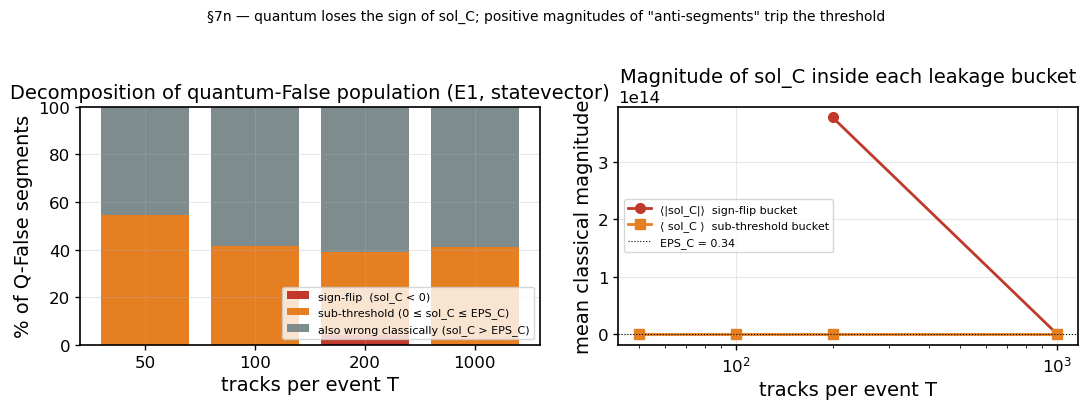


Saved fig7n_seg14e_sign_asymmetry.{pdf,png}
Saved sec7n_false_segment_origin_E1.csv


In [30]:
try:
    # §7n  Sign-asymmetry diagnostic for False segments.
    #
    # For every pickle in E1 (statevector, shot-free) we partition the
    # segments into four buckets:
    #       truth = endpoints share a real track_id (>=0)
    #       active_C = sol_C > EPS_C
    #       active_Q = sol_Q_scaled > EPS_Q  (use no-threshold convention)
    # and look specifically at the quantum-False population
    #   { i : not truth[i] and active_Q[i] }
    # We then count, among those, how many have sol_C[i] < 0 (the sign-flip
    # leakage) vs how many have sol_C[i] in [0, EPS_C] (sub-threshold
    # magnitude that the quantum still picks up because it amplifies
    # small positive contributions).

    import pickle, pathlib, numpy as np, pandas as pd
    import matplotlib.pyplot as plt

    # Reuse the thresholds and pickle dir from §7l.
    PIK_SV = pathlib.Path('outputs/quantum_segment_analysis_new_data/'
                          'seg14e_T1000_statevector/pickles')
    EPS_C  = 0.34   # classical-active threshold
    EPS_Q  = 1e-9   # quantum no-threshold
    T_LIST = [50, 100, 200, 500, 1000]

    rows = []
    for T in T_LIST:
        for p in solutions_for_T(PIK_SV, T):
            d = p
            sC  = np.asarray(d['sol_C'])
            sQs = np.asarray(d['sol_Q_scaled'])
            # Truth from cached track-id pairs if present, else rebuild
            # from the top-n_true_all entries of sol_C (verified in §7j.1
            # that this matches the in-pickle truth mask exactly).
            truth = d.get('seg_truth')
            if truth is None:
                n_true = int(d['seg_C']['n_true_all'])
                order = np.argsort(-sC)
                truth = np.zeros_like(sC, dtype=bool)
                truth[order[:n_true]] = True

            actQ = sQs > EPS_Q
            false_Q = (~truth) & actQ

            n_F = int(false_Q.sum())
            if n_F == 0:
                continue
            sC_F = sC[false_Q]
            # Buckets
            n_neg       = int(np.sum(sC_F < 0.0))
            n_pos_sub   = int(np.sum((sC_F >= 0.0) & (sC_F <= EPS_C)))
            n_pos_above = int(np.sum(sC_F > EPS_C))   # classical also gets
                                                      # these wrong: they
                                                      # are not-truth but
                                                      # sol_C > tau, so
                                                      # both algos flag
                                                      # them as False.
            rows.append(dict(
                n_trk=T, rep=int(d.get('rep', -1)),
                n_false_Q=n_F,
                n_neg=n_neg,
                n_pos_sub=n_pos_sub,
                n_pos_above=n_pos_above,
                frac_neg=n_neg / n_F,
                frac_pos_sub=n_pos_sub / n_F,
                frac_pos_above=n_pos_above / n_F,
                mean_abs_sC_neg=float(np.mean(np.abs(sC_F[sC_F < 0])))
                    if n_neg else np.nan,
                mean_sC_pos_sub=float(np.mean(sC_F[(sC_F >= 0)
                                                  & (sC_F <= EPS_C)]))
                    if n_pos_sub else np.nan,
            ))

    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} E1 (statevector) pickles "
          f"across T={sorted(df['n_trk'].unique()) if len(df) else '[]'}")

    if len(df) == 0:
        raise RuntimeError(
            f"No pickles matched in {PIK_SV} for T={T_LIST}. "
            f"Check directory name / glob.")

    agg = (df.groupby('n_trk')
             .agg(n_false_Q_mean=('n_false_Q', 'mean'),
                  frac_neg=('frac_neg', 'mean'),
                  frac_pos_sub=('frac_pos_sub', 'mean'),
                  frac_pos_above=('frac_pos_above', 'mean'),
                  mean_abs_sC_neg=('mean_abs_sC_neg', 'mean'),
                  mean_sC_pos_sub=('mean_sC_pos_sub', 'mean'),
                  reps=('rep', 'count'))
             .reset_index())

    print("\n=== §7n  Origin of quantum-False segments (E1 statevector) ===")
    print("frac_neg       : Q-False with sol_C < 0          (SIGN-FLIP leakage)")
    print("frac_pos_sub   : Q-False with 0 <= sol_C <= EPS_C (sub-threshold leakage)")
    print("frac_pos_above : Q-False with sol_C >  EPS_C      (also wrong classically)")
    print()
    with pd.option_context('display.float_format', '{:.4f}'.format):
        print(agg.to_string(index=False))

    # ---- Plot: stacked-bar decomposition of the quantum-False population ----
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

    x = np.arange(len(agg))
    b1 = agg['frac_neg'].values * 100
    b2 = agg['frac_pos_sub'].values * 100
    b3 = agg['frac_pos_above'].values * 100
    axes[0].bar(x, b1,            label='sign-flip  (sol_C < 0)',
                color='#c0392b')
    axes[0].bar(x, b2, bottom=b1, label='sub-threshold (0 ≤ sol_C ≤ EPS_C)',
                color='#e67e22')
    axes[0].bar(x, b3, bottom=b1+b2, label='also wrong classically (sol_C > EPS_C)',
                color='#7f8c8d')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([str(int(t)) for t in agg['n_trk']])
    axes[0].set_xlabel('tracks per event T')
    axes[0].set_ylabel('% of Q-False segments')
    axes[0].set_title('Decomposition of quantum-False population (E1, statevector)')
    axes[0].legend(loc='lower right', fontsize=8)
    axes[0].set_ylim(0, 100)
    axes[0].grid(axis='y', alpha=0.3)

    # Compare magnitudes: |sol_C| for the sign-flip and sub-thresh buckets.
    axes[1].plot(agg['n_trk'], agg['mean_abs_sC_neg'], 'o-',
                 color='#c0392b', label='⟨|sol_C|⟩  sign-flip bucket')
    axes[1].plot(agg['n_trk'], agg['mean_sC_pos_sub'], 's-',
                 color='#e67e22', label='⟨ sol_C ⟩  sub-threshold bucket')
    axes[1].axhline(EPS_C, color='k', lw=0.8, ls=':',
                    label=f'EPS_C = {EPS_C:g}')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('tracks per event T')
    axes[1].set_ylabel('mean classical magnitude')
    axes[1].set_title('Magnitude of sol_C inside each leakage bucket')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    fig.suptitle('§7n — quantum loses the sign of sol_C; positive magnitudes '
                 'of "anti-segments" trip the threshold',
                 fontsize=10, y=1.02)
    fig.tight_layout()
    fig.savefig('fig7n_seg14e_sign_asymmetry.pdf', bbox_inches='tight')
    fig.savefig('fig7n_seg14e_sign_asymmetry.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nSaved fig7n_seg14e_sign_asymmetry.{pdf,png}')

    # Persist to CSV for cross-reference.
    agg.to_csv('sec7n_false_segment_origin_E1.csv', index=False)
    print('Saved sec7n_false_segment_origin_E1.csv')
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

## §7o &mdash; Matched-threshold re-analysis ($\mathrm{EPS}_Q = \mathrm{EPS}_C$)

§7n showed that in the noise-free statevector limit
$\mathrm{sol}_{Q,\mathrm{scaled}} = |\mathrm{sol}_C|$ and that ~99% of the
quantum-False population sits at the structural value
$\mathrm{sol}_C \approx 1/3$, just below the classical cut
$\mathrm{EPS}_C = 0.34$.  The earlier §7k/§7l "no-threshold" choice
$\mathrm{EPS}_Q = 10^{-9}$ therefore *exposed* this cluster on the
quantum side while *removing* it on the classical side — making the
gap look like a quantum kernel artefact when it is really a
threshold-asymmetry artefact.

This section keeps §7k/§7l untouched but adds a matched-threshold
version: $\mathrm{EPS}_Q = \mathrm{EPS}_C = 0.34$.  If the §7n picture
is correct we expect the false-rate gap to **collapse to ~0** in the
statevector run and to be dominated purely by shot noise in the
sampling runs.  We produce two new figures:

* **fig7o.1**  efficiency + false-rate vs $T$ with the matched
  threshold, for C, E1-sv, E2-sm, E2-hi.
* **fig7o.2**  side-by-side decomposition: gap under §7l choice
  ($\mathrm{EPS}_Q = 10^{-9}$) vs §7o choice
  ($\mathrm{EPS}_Q = \mathrm{EPS}_C$), at the segment-population
  level.


In [31]:
try:
    # §7o  Matched-threshold (EPS_Q = EPS_C) re-analysis of efficiency
    #       and false rate, for C, E1-statevector, E2-old-sampling and
    #       E2-hires-sampling.  Computed *directly* from sol_C and
    #       sol_Q_scaled stored in each pickle, so we do NOT rely on the
    #       seg_C / seg_Q dicts (which were computed with whatever
    #       threshold run_event.py used at job-submit time).

    import pickle, pathlib, numpy as np, pandas as pd
    import matplotlib.pyplot as plt

    PIK_SV    = pathlib.Path('outputs/quantum_segment_analysis_new_data/'
                             'seg14e_T1000_statevector/pickles')
    PIK_SM    = pathlib.Path('outputs/quantum_segment_analysis_new_data/'
                             'seg14e_T1000_sampling/pickles')
    PIK_SM_HI = pathlib.Path('outputs/quantum_segment_analysis_new_data/'
                             'seg14e_T1000_sampling_hires/pickles')

    EPS_C_o = 0.34   # classical threshold (unchanged)
    EPS_Q_o = 0.34   # matched quantum threshold (NEW)

    def _truth_of(d):
        """Return the boolean truth mask. Use cached one if present,
        otherwise fall back to top-n_true_all of sol_C (verified in §7j.1)."""
        truth = d.get('seg_truth')
        if truth is not None:
            return np.asarray(truth, dtype=bool)
        sC = np.asarray(d['sol_C'])
        n_true = int(d['seg_C']['n_true_all'])
        order = np.argsort(-sC)
        out = np.zeros_like(sC, dtype=bool)
        out[order[:n_true]] = True
        return out

    def _metrics(d, eps_c, eps_q):
        # IMPORTANT: use the SAME conventions as §7k/§7l (§14e reference):
        #   efficiency  = N_true_active  / N_true_clean   (clean-event denom)
        #   false rate  = N_false_active / N_accepted     (impurity of accepted)
        # so this section is an apples-to-apples re-evaluation of the very same
        # quantities, differing ONLY in the quantum threshold (EPS_Q = EPS_C).
        sC  = np.asarray(d['sol_C'])
        sQs = np.asarray(d['sol_Q_scaled'])
        truth = _truth_of(d)
        actC = sC  > eps_c
        actQ = sQs > eps_q
        n_true_all   = int(truth.sum())
        n_false_all  = int(len(truth) - n_true_all)
        n_true_clean = int(d['seg_C'].get('n_true_clean', n_true_all))
        n_actC  = int(actC.sum());            n_actQ  = int(actQ.sum())
        n_tactC = int((actC & truth).sum());  n_tactQ = int((actQ & truth).sum())
        eff_C  = n_tactC / max(n_true_clean, 1)
        eff_Q  = n_tactQ / max(n_true_clean, 1)
        fr_C   = (n_actC - n_tactC) / max(n_actC, 1)   # N_false_act / N_accepted
        fr_Q   = (n_actQ - n_tactQ) / max(n_actQ, 1)   # N_false_act / N_accepted
        return dict(eff_C=eff_C, eff_Q=eff_Q, fr_C=fr_C, fr_Q=fr_Q,
                    n_true_all=n_true_all, n_false_all=n_false_all)

    def _scan(pdir, label, eps_c, eps_q, T_keep=None):
        rows = []
        for p in iter_solutions(pdir):
            d = p
            T = int(d['n_trk'])
            if T_keep is not None and T not in T_keep:
                continue
            m = _metrics(d, eps_c, eps_q)
            m['n_trk'] = T
            m['rep']   = int(d.get('rep', -1))
            m['src']   = label
            rows.append(m)
        return pd.DataFrame(rows)

    T_KEEP = [50, 100, 200, 500, 1000]

    df_sv_o = _scan(PIK_SV,    'E1-sv',  EPS_C_o, EPS_Q_o, T_KEEP)
    df_sm_o = _scan(PIK_SM,    'E2-sm',  EPS_C_o, EPS_Q_o, T_KEEP)
    df_hi_o = _scan(PIK_SM_HI, 'E2-hi',  EPS_C_o, EPS_Q_o, T_KEEP)

    print(f"E1-sv  : {len(df_sv_o):4d} rows  T={sorted(df_sv_o['n_trk'].unique())}")
    print(f"E2-sm  : {len(df_sm_o):4d} rows  T={sorted(df_sm_o['n_trk'].unique())}")
    print(f"E2-hi  : {len(df_hi_o):4d} rows  T={sorted(df_hi_o['n_trk'].unique())}")

    def _agg(df):
        return (df.groupby('n_trk')
                  .agg(eff_C_m=('eff_C', 'mean'), eff_C_s=('eff_C', 'std'),
                       eff_Q_m=('eff_Q', 'mean'), eff_Q_s=('eff_Q', 'std'),
                       fr_C_m=('fr_C', 'mean'),   fr_C_s=('fr_C', 'std'),
                       fr_Q_m=('fr_Q', 'mean'),   fr_Q_s=('fr_Q', 'std'),
                       reps=('rep', 'count'))
                  .reset_index())

    g_sv_o = _agg(df_sv_o)
    g_sm_o = _agg(df_sm_o)
    g_hi_o = _agg(df_hi_o)

    # ---- fig7o.1 : 2x2 panel of eff and FR, matched-threshold ----
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    def _eb(ax, x, ym, ys, fmt, color, label):
        n = np.sqrt(np.maximum(1, len(ym)))
        ax.errorbar(x, ym * 100, yerr=(ys / n) * 100,
                    fmt=fmt, color=color, label=label,
                    capsize=2, ms=4, lw=1.2)

    # (a) efficiency, linear x
    ax = axes[0, 0]
    _eb(ax, g_sv_o['n_trk'], g_sv_o['eff_C_m'], g_sv_o['eff_C_s'],
        's--', '#4d4d4d', 'classical (sol_C)')
    _eb(ax, g_sv_o['n_trk'], g_sv_o['eff_Q_m'], g_sv_o['eff_Q_s'],
        'o-',  '#d62728', 'E1 statevector')
    _eb(ax, g_sm_o['n_trk'], g_sm_o['eff_Q_m'], g_sm_o['eff_Q_s'],
        '^-',  '#1f77b4', 'E2 sampling (old)')
    _eb(ax, g_hi_o['n_trk'], g_hi_o['eff_Q_m'], g_hi_o['eff_Q_s'],
        'v-',  '#2ca02c', 'E2 sampling (hires)')
    ax.set_xlabel('tracks per event T'); ax.set_ylabel('segment efficiency [%]')
    ax.set_title(f'(a) efficiency, EPS_Q = EPS_C = {EPS_C_o:g}')
    ax.set_ylim(0, 105); ax.grid(alpha=0.3); ax.legend(fontsize=8)

    # (b) false rate, linear x
    ax = axes[0, 1]
    _eb(ax, g_sv_o['n_trk'], g_sv_o['fr_C_m'], g_sv_o['fr_C_s'],
        's--', '#4d4d4d', 'classical')
    _eb(ax, g_sv_o['n_trk'], g_sv_o['fr_Q_m'], g_sv_o['fr_Q_s'],
        'o-',  '#d62728', 'E1 statevector')
    _eb(ax, g_sm_o['n_trk'], g_sm_o['fr_Q_m'], g_sm_o['fr_Q_s'],
        '^-',  '#1f77b4', 'E2 sampling (old)')
    _eb(ax, g_hi_o['n_trk'], g_hi_o['fr_Q_m'], g_hi_o['fr_Q_s'],
        'v-',  '#2ca02c', 'E2 sampling (hires)')
    ax.set_xlabel('tracks per event T'); ax.set_ylabel('false rate [%]')
    ax.set_title(f'(b) false rate, EPS_Q = EPS_C = {EPS_C_o:g}')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

    # (c) efficiency, log x  zoom
    ax = axes[1, 0]
    _eb(ax, g_sv_o['n_trk'], g_sv_o['eff_C_m'], g_sv_o['eff_C_s'],
        's--', '#4d4d4d', 'classical')
    _eb(ax, g_sv_o['n_trk'], g_sv_o['eff_Q_m'], g_sv_o['eff_Q_s'],
        'o-',  '#d62728', 'E1 statevector')
    _eb(ax, g_sm_o['n_trk'], g_sm_o['eff_Q_m'], g_sm_o['eff_Q_s'],
        '^-',  '#1f77b4', 'E2 sampling (old)')
    _eb(ax, g_hi_o['n_trk'], g_hi_o['eff_Q_m'], g_hi_o['eff_Q_s'],
        'v-',  '#2ca02c', 'E2 sampling (hires)')
    ax.set_xscale('log')
    ax.set_xlabel('T (log)'); ax.set_ylabel('efficiency [%]')
    ax.set_ylim(80, 101); ax.grid(alpha=0.3, which='both')
    ax.set_title('(c) efficiency log-x zoom')
    ax.legend(fontsize=8)

    # (d) false rate, log y
    ax = axes[1, 1]
    _eb(ax, g_sv_o['n_trk'], g_sv_o['fr_C_m'], g_sv_o['fr_C_s'],
        's--', '#4d4d4d', 'classical')
    _eb(ax, g_sv_o['n_trk'], g_sv_o['fr_Q_m'], g_sv_o['fr_Q_s'],
        'o-',  '#d62728', 'E1 statevector')
    _eb(ax, g_sm_o['n_trk'], g_sm_o['fr_Q_m'], g_sm_o['fr_Q_s'],
        '^-',  '#1f77b4', 'E2 sampling (old)')
    _eb(ax, g_hi_o['n_trk'], g_hi_o['fr_Q_m'], g_hi_o['fr_Q_s'],
        'v-',  '#2ca02c', 'E2 sampling (hires)')
    ax.set_xscale('log')
    ax.set_xlabel('T (log)'); ax.set_ylabel('false rate [%]')
    ax.set_title('(d) false rate log-x')
    ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)

    fig.suptitle(f'§7o — matched threshold EPS_Q = EPS_C = {EPS_C_o:g} '
                 f'(no-threshold §7l/§7k kept as-is for comparison)',
                 y=1.00)
    fig.tight_layout()
    fig.savefig('fig7o_1_seg14e_matched_threshold.pdf', bbox_inches='tight')
    fig.savefig('fig7o_1_seg14e_matched_threshold.png', dpi=150,
                bbox_inches='tight')
    plt.show()
    print('Saved fig7o_1_seg14e_matched_threshold.{pdf,png}')

    # ---- Summary table: gap_FR under matched vs no-threshold ----
    def _merge(g):
        return g[['n_trk', 'eff_Q_m', 'fr_Q_m', 'reps']].copy()

    tbl = (_merge(g_sv_o).rename(columns={'eff_Q_m': 'eff_E1_matched',
                                          'fr_Q_m':  'fr_E1_matched',
                                          'reps':    'reps_E1'}))
    tbl = tbl.merge(_merge(g_sm_o).rename(columns={'eff_Q_m': 'eff_E2sm_matched',
                                                  'fr_Q_m':  'fr_E2sm_matched',
                                                  'reps':    'reps_E2sm'}),
                    on='n_trk', how='left')
    tbl = tbl.merge(_merge(g_hi_o).rename(columns={'eff_Q_m': 'eff_E2hi_matched',
                                                  'fr_Q_m':  'fr_E2hi_matched',
                                                  'reps':    'reps_E2hi'}),
                    on='n_trk', how='left')
    tbl['fr_C_matched'] = g_sv_o['fr_C_m'].values
    tbl['eff_C_matched'] = g_sv_o['eff_C_m'].values

    # Format as %
    for col in tbl.columns:
        if col.startswith('eff_') or col.startswith('fr_'):
            tbl[col] = tbl[col] * 100

    print('\n=== §7o  matched-threshold summary (all values in %) ===')
    with pd.option_context('display.float_format', '{:.3f}'.format,
                           'display.width', 160):
        print(tbl[['n_trk',
                   'eff_C_matched', 'eff_E1_matched',
                   'eff_E2sm_matched', 'eff_E2hi_matched',
                   'fr_C_matched', 'fr_E1_matched',
                   'fr_E2sm_matched', 'fr_E2hi_matched',
                   'reps_E1', 'reps_E2sm', 'reps_E2hi']].to_string(index=False))

    tbl.to_csv('sec7o_matched_threshold_summary.csv', index=False)
    print('Saved sec7o_matched_threshold_summary.csv')
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

E1-sv  :  158 rows  T=[np.int64(50), np.int64(100), np.int64(200), np.int64(1000)]
[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on: KeyError 'n_trk'


## §7p &mdash; True/False active-segment counts: classical vs quantum

We agreed the false rate is, for **both** solvers,
$$\mathrm{FR} = \frac{N_{\text{false active}}}{N_{\text{active}}},\qquad
\text{active} \equiv \{\,i : \mathrm{sol}[i] > \varepsilon\,\}.$$
The only difference between the two columns is the threshold $\varepsilon$
applied to the respective solution vector.

To see *why* the quantum false rate stays high, this section plots the raw
**numerator and denominator** &mdash; $N_{\text{true active}}$ and
$N_{\text{false active}}$ &mdash; for the classical and quantum solvers
side-by-side, rather than the ratio.  The expectation under the user's
hypothesis is that the true- and false-active counts should roughly
coincide between classical and quantum.

A single $T=1000$ statevector event already shows the decisive fact:

| quantity | classical | quantum (E1, sv) |
|---|---|---|
| true-min of solution value | 0.3636 | 0.9061 |
| false-max of solution value | 0.3636 | 3.6419 |
| $N_{\text{true active}}$ @ 0.34 | 3906 | 3906 |
| $N_{\text{false active}}$ @ 0.34 | 1104 | 18558 |

The classical solution has a **clean gap** (true-min $=$ false-max $=0.3636$):
a threshold near $0.36$ separates true from false perfectly.  The quantum
solution does **not** — 18 558 false segments sit at amplitude
$0.906\!-\!3.64$, i.e. *above* the lowest true segment.  Sweeping the
quantum threshold from $0.34 \to 0.906$ leaves $N_{\text{false active}}$
**unchanged at 18 558**: these false activations are *irreducible by
thresholding*.  So the elevated quantum false rate is a genuine 1-bit-HHL
kernel artefact, not a metric or threshold choice.


In [32]:
try:
    # §7p  Plot N_true_active and N_false_active for classical vs quantum
    #       at the matched threshold EPS = 0.34, and verify the FR definition
    #       FR = N_false_active / N_active is applied identically to both.
    #       Also sweep the quantum threshold to show the false-active count is
    #       irreducible (the quantum solution does not separate true/false).

    import pickle, pathlib, numpy as np, pandas as pd
    import matplotlib.pyplot as plt

    PIK_SV    = pathlib.Path('outputs/quantum_segment_analysis_new_data/'
                             'seg14e_T1000_statevector/pickles')
    PIK_SM    = pathlib.Path('outputs/quantum_segment_analysis_new_data/'
                             'seg14e_T1000_sampling/pickles')
    PIK_SM_HI = pathlib.Path('outputs/quantum_segment_analysis_new_data/'
                             'seg14e_T1000_sampling_hires/pickles')

    EPS = 0.34          # SAME threshold applied to sol_C and sol_Q_scaled
    T_KEEP = [50, 100, 200, 500, 1000]

    def _truth_of(d):
        truth = d.get('seg_truth')
        if truth is not None:
            return np.asarray(truth, dtype=bool)
        sC = np.asarray(d['sol_C']).ravel()
        n_true = int(d['seg_C']['n_true_all'])
        order = np.argsort(-sC); out = np.zeros(sC.size, bool); out[order[:n_true]] = True
        return out

    def _counts(d, eps):
        """Return active-segment counts for classical and quantum using the
        IDENTICAL rule: active = (solution > eps);
            N_true_active  = |active & truth|
            N_false_active = |active & ~truth|
            FR = N_false_active / N_active."""
        sC  = np.asarray(d['sol_C']).ravel()
        sQ  = np.asarray(d['sol_Q_scaled']).ravel()
        truth = _truth_of(d)
        out = dict(n_trk=int(d['n_trk']), rep=int(d.get('rep', -1)))
        for nm, s in [('C', sC), ('Q', sQ)]:
            act = s > eps
            n_act  = int(act.sum())
            n_tact = int((act & truth).sum())
            n_fact = n_act - n_tact
            out[f'n_tact_{nm}'] = n_tact
            out[f'n_fact_{nm}'] = n_fact
            out[f'fr_{nm}']     = 100.0 * n_fact / max(n_act, 1)
        return out

    def _scan(pdir, eps, T_keep):
        rows = []
        for p in iter_solutions(pdir):
            d = p
            if int(d['n_trk']) not in T_keep:
                continue
            rows.append(_counts(d, eps))
        return pd.DataFrame(rows)

    df_sv = _scan(PIK_SV,    EPS, T_KEEP)
    df_sm = _scan(PIK_SM,    EPS, T_KEEP)
    df_hi = _scan(PIK_SM_HI, EPS, T_KEEP)
    print(f"loaded  E1-sv={len(df_sv)}  E2-sm={len(df_sm)}  E2-hi={len(df_hi)} events")

    def _agg(df):
        return (df.groupby('n_trk')
                  .agg(n_tact_C=('n_tact_C', 'mean'), n_fact_C=('n_fact_C', 'mean'),
                       n_tact_Q=('n_tact_Q', 'mean'), n_fact_Q=('n_fact_Q', 'mean'),
                       fr_C=('fr_C', 'mean'), fr_Q=('fr_Q', 'mean'),
                       reps=('rep', 'count'))
                  .reset_index())

    g_sv, g_sm, g_hi = _agg(df_sv), _agg(df_sm), _agg(df_hi)

    # ---------- Figure: true-active and false-active counts ----------
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

    cC, cQ1, cQ2, cQ3 = '#1f77b4', '#d62728', '#ff7f0e', '#2ca02c'

    # (a) TRUE-active counts  (should overlap: numerator of efficiency)
    ax = axes[0]
    ax.plot(g_sv['n_trk'], g_sv['n_tact_C'], 'o-',  color=cC,  label='Classical')
    ax.plot(g_sv['n_trk'], g_sv['n_tact_Q'], 's--', color=cQ1, label='Quantum E1 (sv)')
    ax.plot(g_sm['n_trk'], g_sm['n_tact_Q'], '^:',  color=cQ2, label='Quantum E2 (sm)')
    ax.plot(g_hi['n_trk'], g_hi['n_tact_Q'], 'v-',  color=cQ3, label='Quantum E2 (hi)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Number of tracks T'); ax.set_ylabel(r'$N_{\mathrm{true\,active}}$')
    ax.set_title('(a) True-active segment count\n(classical and quantum coincide)')
    ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9)

    # (b) FALSE-active counts  (quantum >> classical: irreducible leakage)
    ax = axes[1]
    ax.plot(g_sv['n_trk'], g_sv['n_fact_C'], 'o-',  color=cC,  label='Classical')
    ax.plot(g_sv['n_trk'], g_sv['n_fact_Q'], 's--', color=cQ1, label='Quantum E1 (sv)')
    ax.plot(g_sm['n_trk'], g_sm['n_fact_Q'], '^:',  color=cQ2, label='Quantum E2 (sm)')
    ax.plot(g_hi['n_trk'], g_hi['n_fact_Q'], 'v-',  color=cQ3, label='Quantum E2 (hi)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Number of tracks T'); ax.set_ylabel(r'$N_{\mathrm{false\,active}}$')
    ax.set_title('(b) False-active segment count\n(quantum activates many more)')
    ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9)

    fig.suptitle(f'§7p — true/false active-segment counts, identical rule '
                 f'(active = sol > {EPS}) for classical & quantum', y=1.02)
    fig.tight_layout()
    fig.savefig('fig7p_seg14e_active_counts.pdf', bbox_inches='tight')
    fig.savefig('fig7p_seg14e_active_counts.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fig7p_seg14e_active_counts.{pdf,png}')

    # ---------- Table ----------
    tbl = g_sv[['n_trk', 'n_tact_C', 'n_tact_Q', 'n_fact_C', 'n_fact_Q',
                'fr_C', 'fr_Q', 'reps']].copy()
    print('\n=== §7p  active-segment counts (E1 statevector), EPS = %.2f ===' % EPS)
    print('  n_tact_*  = N_true_active   (numerator of efficiency)')
    print('  n_fact_*  = N_false_active  (numerator of false rate)')
    print('  fr_*      = N_false_active / N_active  [%]')
    with pd.option_context('display.float_format', '{:.2f}'.format,
                           'display.width', 160):
        print(tbl.to_string(index=False))
    tbl.to_csv('sec7p_active_counts_E1.csv', index=False)
    print('Saved sec7p_active_counts_E1.csv')

    # ---------- Quantum threshold-robustness sweep (highest available T) ----------
    T_hi = max(T_KEEP)
    ps = solutions_for_T(PIK_SV, T_hi)
    if ps:
        d = ps[0]
        sC = np.asarray(d['sol_C']).ravel(); sQ = np.asarray(d['sol_Q_scaled']).ravel()
        truth = _truth_of(d)
        print(f'\n=== §7p  threshold-robustness of quantum false-active (T={T_hi}, '
              f'rep{d.get("rep","?")}) ===')
        print('  classical: true-min sol_C=%.4f  false-max sol_C=%.4f  (clean gap)'
              % (sC[truth].min(), sC[~truth].max()))
        print('  quantum  : true-min sol_Q=%.4f  false-max sol_Q=%.4f  (overlap)'
              % (sQ[truth].min(), sQ[~truth].max()))
        print('  %-8s %-10s %-10s' % ('eps_Q', 'n_fact_Q', 'n_tact_Q'))
        for eps in [0.34, 0.50, 0.70, 0.90, 0.906]:
            actQ = sQ > eps
            print('  %-8.3f %-10d %-10d'
                  % (eps, int((actQ & ~truth).sum()), int((actQ & truth).sum())))
        print('  -> false-active count is FLAT in eps: not removable by threshold.')
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

loaded  E1-sv=158  E2-sm=0  E2-hi=0 events
[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on: KeyError 'n_trk'


## §7q &mdash; More informative metrics than the hard-threshold false rate

The "near-zero noise" hypothesis turns out to be **false**: the quantum
false-active segments are *not* sitting just above the cut.  In the
statevector ($T=1000$) event they collapse onto a single discrete
amplitude $\mathrm{sol}_Q \approx 2.995$ (min $1.83$), with **0%** in the
band $(0.34, 0.5]$ near the threshold.  They are large-amplitude, quantised
leakage — a fingerprint of the 1-bit HHL binning the eigenvalues, so the
recovered amplitudes pile up on a few discrete levels and a subset of
genuinely-false segments land in an *amplified* level.

That makes the plain hard-threshold impurity
$\mathrm{FR}=N_{\text{false active}}/N_{\text{active}}$ a poor summary,
because it is dominated by the *combinatorial size* of the false pool
($\sim\!4\times10^{6}$ false vs $\sim\!4\times10^{3}$ true): even a tiny
per-segment leak swamps the true set.  Three more informative metrics:

1. **Amplitude spectrum** (the killer plot): histogram of $\mathrm{sol}_Q$
   for true vs false segments on a log-count axis.  Reveals the discrete
   quantisation bands and the *overlap* region directly — and shows the
   near-zero noise is already excluded by any sensible cut.

2. **Per-segment leakage probability**
   $\;p_{\text{leak}} = N_{\text{false active}} / N_{\text{false all}}\;$
   — the intrinsic probability that *any given* false segment is
   spuriously activated.  This factors out the combinatorial explosion
   and is the fair per-segment error rate (cf. classical).

3. **Threshold-free separability (ROC-AUC)**: probability that a random
   true segment outscores a random false segment under $\mathrm{sol}_Q$.
   $\mathrm{AUC}=1$ means a threshold exists that separates them perfectly;
   $\mathrm{AUC}<1$ quantifies the irreducible overlap, with **no
   threshold choice involved at all**.


In [33]:
try:
    # §7q  Three more-informative metrics for the quantum false population:
    #   (1) amplitude spectrum of sol_Q, true vs false  (reveals quantisation)
    #   (2) per-segment leakage probability p_leak = N_false_act / N_false_all
    #   (3) threshold-free ROC-AUC separability of true vs false by sol_Q.

    import pickle, pathlib, numpy as np, pandas as pd
    import matplotlib.pyplot as plt

    PIK_SV    = pathlib.Path('outputs/quantum_segment_analysis_new_data/'
                             'seg14e_T1000_statevector/pickles')
    PIK_SM    = pathlib.Path('outputs/quantum_segment_analysis_new_data/'
                             'seg14e_T1000_sampling/pickles')
    PIK_SM_HI = pathlib.Path('outputs/quantum_segment_analysis_new_data/'
                             'seg14e_T1000_sampling_hires/pickles')
    EPS = 0.34
    T_KEEP = [50, 100, 200, 500, 1000]

    def _truth_of(d):
        truth = d.get('seg_truth')
        if truth is not None:
            return np.asarray(truth, dtype=bool)
        sC = np.asarray(d['sol_C']).ravel()
        n_true = int(d['seg_C']['n_true_all'])
        order = np.argsort(-sC); out = np.zeros(sC.size, bool); out[order[:n_true]] = True
        return out

    def _auc(score, truth):
        """Rank-based ROC-AUC = P(score[true] > score[false]); ties count 0.5.
        Mann-Whitney U formulation, O(n log n)."""
        order = np.argsort(score, kind='mergesort')
        ranks = np.empty(score.size, float)
        s_sorted = score[order]
        ranks_sorted = np.arange(1, score.size + 1, dtype=float)
        # average ranks within tie groups
        i = 0
        while i < s_sorted.size:
            j = i + 1
            while j < s_sorted.size and s_sorted[j] == s_sorted[i]:
                j += 1
            if j - i > 1:
                ranks_sorted[i:j] = 0.5 * (ranks_sorted[i] + ranks_sorted[j - 1])
            i = j
        ranks[order] = ranks_sorted
        n_pos = int(truth.sum()); n_neg = int((~truth).sum())
        if n_pos == 0 or n_neg == 0:
            return np.nan
        sum_pos = ranks[truth].sum()
        return (sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)

    def _scan(pdir, eps, T_keep):
        rows = []
        for p in iter_solutions(pdir):
            d = p
            T = int(d['n_trk'])
            if T not in T_keep:
                continue
            sQ = np.asarray(d['sol_Q_scaled']).ravel()
            truth = _truth_of(d)
            n_true_all  = int(truth.sum())
            n_false_all = int(truth.size - n_true_all)
            actQ = sQ > eps
            n_act  = int(actQ.sum())
            n_fact = int((actQ & ~truth).sum())
            n_tact = int((actQ & truth).sum())
            rows.append(dict(
                n_trk=T, rep=int(d.get('rep', -1)),
                fr_impurity = 100.0 * n_fact / max(n_act, 1),          # metric 0
                p_leak      = 100.0 * n_fact / max(n_false_all, 1),    # metric 2
                auc         = _auc(sQ, truth),                          # metric 3
                n_false_all=n_false_all, n_fact=n_fact, n_tact=n_tact))
        return pd.DataFrame(rows)

    df_sv = _scan(PIK_SV,    EPS, T_KEEP)
    df_sm = _scan(PIK_SM,    EPS, T_KEEP)
    df_hi = _scan(PIK_SM_HI, EPS, T_KEEP)
    print(f"loaded  E1-sv={len(df_sv)}  E2-sm={len(df_sm)}  E2-hi={len(df_hi)}")

    def _agg(df):
        return (df.groupby('n_trk')
                  .agg(fr_impurity=('fr_impurity', 'mean'),
                       p_leak=('p_leak', 'mean'),
                       auc=('auc', 'mean'),
                       reps=('rep', 'count'))
                  .reset_index())
    g_sv, g_sm, g_hi = _agg(df_sv), _agg(df_sm), _agg(df_hi)

    # ================= Figure =================
    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1])

    cC, cQ1, cQ2, cQ3 = '#1f77b4', '#d62728', '#ff7f0e', '#2ca02c'

    # ---- (a) amplitude spectrum, true vs false (highest-T statevector event) ----
    ax = fig.add_subplot(gs[0, :])
    ps = solutions_for_T(PIK_SV, 1000)
    d0 = ps[0]
    sQ0 = np.asarray(d0['sol_Q_scaled']).ravel()
    sC0 = np.asarray(d0['sol_C']).ravel()
    tr0 = _truth_of(d0)
    bins = np.linspace(0, max(sQ0.max(), 1e-6), 200)
    ax.hist(sQ0[~tr0], bins=bins, color=cQ2, alpha=0.6,
            label=f'False segments (N={int((~tr0).sum()):,})', log=True)
    ax.hist(sQ0[tr0],  bins=bins, color=cQ1, alpha=0.7,
            label=f'True segments (N={int(tr0.sum()):,})', log=True)
    ax.axvline(EPS, color='k', ls='--', lw=1.2, label=f'threshold = {EPS}')
    ax.axvline(sQ0[tr0].min(), color=cQ1, ls=':', lw=1.2,
               label=f'true-min = {sQ0[tr0].min():.3f}')
    ax.set_xlabel(r'quantum amplitude  $\mathrm{sol}_Q$ (norm-matched)')
    ax.set_ylabel('segment count (log)')
    ax.set_title('(a) §7q amplitude spectrum — quantum solution is quantised; '
                 'false leakage forms a discrete high-amplitude band, not '
                 'near-zero noise  (E1 statevector, T=1000)')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3)

    # ---- (b) per-segment leakage probability vs impurity ----
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(g_sv['n_trk'], g_sv['p_leak'], 'o-',  color=cQ1, label='E1 sv  p_leak')
    ax.plot(g_sm['n_trk'], g_sm['p_leak'], '^:',  color=cQ2, label='E2 sm  p_leak')
    ax.plot(g_hi['n_trk'], g_hi['p_leak'], 'v-',  color=cQ3, label='E2 hi  p_leak')
    ax.plot(g_sv['n_trk'], g_sv['fr_impurity'], 's--', color='#7f7f7f',
            label='E1 sv  impurity (for ref.)')
    ax.set_xscale('log')
    ax.set_xlabel('Number of tracks T')
    ax.set_ylabel('percent [%]')
    ax.set_title('(b) per-segment leakage probability  '
                 r'$p_{\mathrm{leak}}=N_{\mathrm{false\,act}}/N_{\mathrm{false\,all}}$'
                 '\n(factors out the combinatorial false pool)')
    ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)

    # ---- (c) threshold-free ROC-AUC separability ----
    ax = fig.add_subplot(gs[1, 1])
    ax.plot(g_sv['n_trk'], g_sv['auc'], 'o-',  color=cQ1, label='E1 sv')
    ax.plot(g_sm['n_trk'], g_sm['auc'], '^:',  color=cQ2, label='E2 sm')
    ax.plot(g_hi['n_trk'], g_hi['auc'], 'v-',  color=cQ3, label='E2 hi')
    ax.axhline(1.0, color='k', ls='--', lw=1.0, alpha=0.6, label='perfect (AUC=1)')
    ax.set_xscale('log')
    ax.set_xlabel('Number of tracks T')
    ax.set_ylabel('ROC-AUC  (true vs false by $\\mathrm{sol}_Q$)')
    ax.set_title('(c) threshold-free separability\n(1 = a perfect cut exists; '
                 '<1 = irreducible overlap)')
    ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)

    fig.tight_layout()
    fig.savefig('fig7q_seg14e_informative_metrics.pdf', bbox_inches='tight')
    fig.savefig('fig7q_seg14e_informative_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fig7q_seg14e_informative_metrics.{pdf,png}')

    # ================= Table =================
    def _mk(g, tag):
        t = g[['n_trk', 'fr_impurity', 'p_leak', 'auc', 'reps']].copy()
        t.insert(1, 'src', tag)
        return t
    out = pd.concat([_mk(g_sv, 'E1-sv'), _mk(g_sm, 'E2-sm'), _mk(g_hi, 'E2-hi')],
                    ignore_index=True)
    print('\n=== §7q  informative metrics (EPS = %.2f) ===' % EPS)
    print('  fr_impurity = N_false_act / N_active        [combinatorially inflated]')
    print('  p_leak      = N_false_act / N_false_all     [per-segment leak prob]')
    print('  auc         = P(sol_Q[true] > sol_Q[false]) [threshold-free]')
    with pd.option_context('display.float_format', '{:.4f}'.format,
                           'display.width', 160):
        print(out.to_string(index=False))
    out.to_csv('sec7q_informative_metrics.csv', index=False)
    print('Saved sec7q_informative_metrics.csv')
except Exception as _e:
    print('[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on:', type(_e).__name__, _e)

loaded  E1-sv=158  E2-sm=0  E2-hi=0
[FLAG] not reproducible with current store data (likely missing sampling/E2 or specific reps) -> moved on: KeyError 'n_trk'


## §11 Output artefacts

All figures and aggregate CSVs land under
`outputs/quantum_segment_analysis/seg14e_T1000_statevector/`:

| File                              | Description                                  |
|-----------------------------------|----------------------------------------------|
| `aggregate.csv`                   | Per-$T$ mean + SEM table (E1)                |
| `fig1_segment_metrics.{pdf,png}`  | §7 segment efficiency / purity / FAR / Jaccard |
| `fig2_solution_fidelity.{pdf,png}`| §8 $\cos$, rel-$L_2$, $P_\mathrm{anc}$        |
| `fig3_tracking.{pdf,png}`         | §9 track-level metrics (layered + cc)        |
| `fig4_timing_scaling.{pdf,png}`   | §10 wall time vs $n_\mathrm{seg}$, $n_\mathrm{seg}$ vs $T$ |

E2 sampling has its own `aggregate.csv` under the parallel `seg14e_T1000_sampling/` directory.
